# M5 Walmart Demand Forecasting


In [1]:
# libraries
import os
import gc
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from google.colab import drive

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [2]:
# Path to dataset file
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Colab Notebooks/Deep Learning - Project/m5-forecasting-accuracy"

Mounted at /content/drive


## 1. Load the M5 files in Google Colab

The identifier columns are loaded as categorical variables, calendar integers use smaller integer types, and prices use `float32`. We do not load `sales_train_evaluation.csv` because the validation file contains the historical target data used in this project.

In [3]:
id_cols = [
    "id", "item_id", "dept_id", "cat_id", "store_id", "state_id"
]

sales_dtypes = {col: "category" for col in id_cols}
calendar_dtypes = {
    "d": "category",
    "wm_yr_wk": "int16",
    "wday": "int8",
    "month": "int8",
    "year": "int16",
    "snap_CA": "int8",
    "snap_TX": "int8",
    "snap_WI": "int8"
}
price_dtypes = {
    "store_id": "category",
    "item_id": "category",
    "wm_yr_wk": "int16",
    "sell_price": "float32"
}

sales_wide = pd.read_csv(
    os.path.join(file_path, "sales_train_validation.csv"),
    dtype=sales_dtypes
)
calendar_df = pd.read_csv(
    os.path.join(file_path, "calendar.csv"),
    dtype=calendar_dtypes
)
sell_prices_df = pd.read_csv(
    os.path.join(file_path, "sell_prices.csv"),
    dtype=price_dtypes
)

print("Sales:", sales_wide.shape)
print("Calendar:", calendar_df.shape)
print("Prices:", sell_prices_df.shape)

Sales: (30490, 1919)
Calendar: (1969, 14)
Prices: (6841121, 4)


In [4]:
def memory_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

print(f"Wide sales memory: {memory_mb(sales_wide):,.1f} MB")
print(f"Calendar memory: {memory_mb(calendar_df):,.1f} MB")
print(f"Prices memory: {memory_mb(sell_prices_df):,.1f} MB")


Wide sales memory: 448.7 MB
Calendar memory: 0.7 MB
Prices memory: 59.0 MB


## 3. Aggregate before melting

Melting the complete item-level matrix would create almost 58 million rows. Instead, we first sum all item demand within each store and category while the data is still in its compact wide format. This uses every original series and avoids sampling.


In [5]:
day_cols = [col for col in sales_wide.columns if col.startswith("d_")]
series_cols = ["store_id", "state_id", "cat_id"]

sales_aggregated_wide = (
    sales_wide
    .groupby(series_cols, observed=True)[day_cols]
    .sum()
    .reset_index()
)

print("Aggregated wide shape:", sales_aggregated_wide.shape)
print("Number of store-category series:", len(sales_aggregated_wide))


Aggregated wide shape: (30, 1916)
Number of store-category series: 30


In [6]:
# Reshape only the 30 aggregated series
sales_long = sales_aggregated_wide.melt(
    id_vars=series_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)

sales_long["sales"] = pd.to_numeric(sales_long["sales"], downcast="integer")

print("Long-format shape:", sales_long.shape)
print(f"Long-format memory before joins: {memory_mb(sales_long):,.1f} MB")


Long-format shape: (57390, 5)
Long-format memory before joins: 3.3 MB


## 4. Create store–category price features

Because the modelling level is store–category rather than item–store, item prices are summarized as the mean available price within each store, category, and M5 week.


In [7]:
item_category_map = sales_wide[["item_id", "cat_id", "store_id"]].drop_duplicates()

category_prices = (
    sell_prices_df
    .merge(item_category_map, on=["store_id", "item_id"], how="left")
    .groupby(["store_id", "cat_id", "wm_yr_wk"], observed=True)["sell_price"]
    .mean()
    .reset_index()
)

category_prices["sell_price"] = category_prices["sell_price"].astype("float32")
print(category_prices.shape)


(8460, 4)


In [8]:
# Add calendar and price information
calendar_keep = [
    "d", "date", "wm_yr_wk", "weekday", "wday", "month", "year",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
    "snap_CA", "snap_TX", "snap_WI"
]

sales_long = sales_long.merge(
    calendar_df[calendar_keep],
    on="d",
    how="left",
    validate="many_to_one"
)

sales_long = sales_long.merge(
    category_prices,
    on=["store_id", "cat_id", "wm_yr_wk"],
    how="left",
    validate="many_to_one"
)

sales_long["date"] = pd.to_datetime(sales_long["date"])

# Fill event fields without dropping ordinary non-event days
event_cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
sales_long[event_cols] = sales_long[event_cols].fillna("None")

# Fill occasional missing weekly category prices within each store-category series
sales_long = sales_long.sort_values(["store_id", "cat_id", "date"])
sales_long["sell_price"] = (
    sales_long.groupby(["store_id", "cat_id"], observed=True)["sell_price"]
    .transform(lambda s: s.ffill().bfill())
    .astype("float32")
)

print(sales_long.shape)
print(f"Working-table memory after joins: {memory_mb(sales_long):,.1f} MB")
sales_long.head()


(57390, 19)
Working-table memory after joins: 19.6 MB


,store_id,state_id,cat_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,CA_1,CA,HOBBIES,d_1,556,2011-01-29,11101,Saturday,1,1,2011,None,None,None,None,0,0,0,4.468814
30,CA_1,CA,HOBBIES,d_2,498,2011-01-30,11101,Sunday,2,1,2011,None,None,None,None,0,0,0,4.468814
60,CA_1,CA,HOBBIES,d_3,415,2011-01-31,11101,Monday,3,1,2011,None,None,None,None,0,0,0,4.468814
90,CA_1,CA,HOBBIES,d_4,392,2011-02-01,11101,Tuesday,4,2,2011,None,None,None,None,1,1,0,4.468814
120,CA_1,CA,HOBBIES,d_5,268,2011-02-02,11101,Wednesday,5,2,2011,None,None,None,None,1,0,1,4.468814


In [9]:
# The original wide files are no longer required.
del sales_aggregated_wide, sell_prices_df, category_prices, item_category_map
gc.collect()


31

## 5. Calendar, event, price, lag, and rolling features

The feature set is expanded based on the EDA and initial feature-importance results. Longer weekly lags capture recurring demand patterns, while rolling statistics describe recent demand level and volatility. Price features express the current category price relative to its recent history.

All target-derived lag and rolling features are calculated independently for each store–category series. The target is shifted before every rolling calculation, so the current day's sales are never included in its predictors.


In [10]:
# Calendar features
sales_long["day"] = sales_long["date"].dt.day.astype("int8")
sales_long["dayofweek"] = sales_long["date"].dt.dayofweek.astype("int8")
sales_long["week"] = sales_long["date"].dt.isocalendar().week.astype("int8")
sales_long["quarter"] = sales_long["date"].dt.quarter.astype("int8")
sales_long["dayofyear"] = sales_long["date"].dt.dayofyear.astype("int16")
sales_long["is_weekend"] = (sales_long["dayofweek"] >= 5).astype("int8")

# A continuous trend feature is more useful than treating each year as unrelated.
sales_long["time_idx"] = (
    sales_long["date"] - sales_long["date"].min()
).dt.days.astype("int16")

# Cyclic encodings preserve the closeness of Sunday/Monday and December/January.
sales_long["dow_sin"] = np.sin(2 * np.pi * sales_long["dayofweek"] / 7).astype("float32")
sales_long["dow_cos"] = np.cos(2 * np.pi * sales_long["dayofweek"] / 7).astype("float32")
sales_long["month_sin"] = np.sin(2 * np.pi * sales_long["month"] / 12).astype("float32")
sales_long["month_cos"] = np.cos(2 * np.pi * sales_long["month"] / 12).astype("float32")
sales_long["doy_sin"] = np.sin(2 * np.pi * sales_long["dayofyear"] / 365.25).astype("float32")
sales_long["doy_cos"] = np.cos(2 * np.pi * sales_long["dayofyear"] / 365.25).astype("float32")

# State-specific SNAP indicator
sales_long["snap"] = np.select(
    [
        sales_long["state_id"].astype(str).eq("CA"),
        sales_long["state_id"].astype(str).eq("TX"),
        sales_long["state_id"].astype(str).eq("WI")
    ],
    [sales_long["snap_CA"], sales_long["snap_TX"], sales_long["snap_WI"]],
    default=0
).astype("int8")

# Simple event indicators complement the categorical event labels.
sales_long["is_event_day"] = (
    sales_long["event_name_1"].astype(str).ne("None") |
    sales_long["event_name_2"].astype(str).ne("None")
).astype("int8")

sales_long["has_two_events"] = (
    sales_long["event_name_1"].astype(str).ne("None") &
    sales_long["event_name_2"].astype(str).ne("None")
).astype("int8")


In [11]:
group_keys = ["store_id", "cat_id"]
grouped_sales = sales_long.groupby(group_keys, observed=True)["sales"]

# Weekly and four-week recurrence were strongest in the initial model.
# Longer weekly lags allow the models to compare several previous cycles.
lag_days = [1, 7, 14, 21, 28, 35, 42, 56]

for lag in lag_days:
    sales_long[f"lag_{lag}"] = grouped_sales.shift(lag).astype("float32")

# Rolling demand features use only information available before the prediction day.
rolling_windows = [7, 14, 28, 56]

for window in rolling_windows:
    shifted_rolling = grouped_sales.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).mean()
    )
    sales_long[f"rolling_mean_{window}"] = shifted_rolling.astype("float32")

for window in [7, 14, 28]:
    sales_long[f"rolling_std_{window}"] = (
        grouped_sales
        .transform(lambda s: s.shift(1).rolling(window, min_periods=window).std())
        .astype("float32")
    )

# Robust and range-based summaries of recent demand.
sales_long["rolling_median_7"] = (
    grouped_sales
    .transform(lambda s: s.shift(1).rolling(7, min_periods=7).median())
    .astype("float32")
)

sales_long["rolling_min_7"] = (
    grouped_sales
    .transform(lambda s: s.shift(1).rolling(7, min_periods=7).min())
    .astype("float32")
)

sales_long["rolling_max_7"] = (
    grouped_sales
    .transform(lambda s: s.shift(1).rolling(7, min_periods=7).max())
    .astype("float32")
)

# Demand momentum features derived only from already-lagged values.
sales_long["change_1_vs_7"] = (sales_long["lag_1"] - sales_long["lag_7"]).astype("float32")
sales_long["change_7_vs_14"] = (sales_long["lag_7"] - sales_long["lag_14"]).astype("float32")
sales_long["change_7_vs_28"] = (sales_long["lag_7"] - sales_long["lag_28"]).astype("float32")

sales_long["ratio_7_vs_28"] = (
    sales_long["lag_7"] / sales_long["lag_28"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(0, 10).astype("float32")

# Relative price features. Prices are known calendar/exogenous inputs in M5.
grouped_price = sales_long.groupby(group_keys, observed=True)["sell_price"]

sales_long["price_change_1"] = grouped_price.diff(1).fillna(0).astype("float32")
sales_long["price_change_7"] = grouped_price.diff(7).fillna(0).astype("float32")

sales_long["price_mean_28"] = (
    grouped_price
    .transform(lambda s: s.rolling(28, min_periods=1).mean())
    .astype("float32")
)

sales_long["price_vs_mean_28"] = (
    sales_long["sell_price"] / sales_long["price_mean_28"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(1.0).astype("float32")

sales_long["price_pct_change_7"] = (
    grouped_price.pct_change(7, fill_method=None)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(-2, 2)
    .astype("float32")
)

print(f"Feature table memory: {memory_mb(sales_long):,.1f} MB")


Feature table memory: 27.5 MB


In [12]:
# The longest lag and rolling window require 56 days of history.
required_model_cols = [
    "sell_price",
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28", "lag_35", "lag_42", "lag_56",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28", "rolling_mean_56",
    "rolling_std_7", "rolling_std_14", "rolling_std_28",
    "rolling_median_7", "rolling_min_7", "rolling_max_7"
]

model_data = sales_long.dropna(subset=required_model_cols).reset_index(drop=True)

print("Rows before history filtering:", len(sales_long))
print("Rows available for modelling:", len(model_data))
print("Rows removed per series:", len(sales_long) // 30 - len(model_data) // 30)
print(f"Model-data memory: {memory_mb(model_data):,.1f} MB")


Rows before history filtering: 57390
Rows available for modelling: 55710
Rows removed per series: 56
Model-data memory: 26.2 MB


## 6. Exploratory analysis using all stores and items

The following compact tables and plots use the full-demand aggregate. `sales_long` now contains all M5 demand at the store–category level.


In [13]:
# Total sales by category
sales_long.groupby('cat_id')['sales'].sum()

,sales
cat_id,
HOBBIES,6124800
HOUSEHOLD,14480670
FOODS,45089939


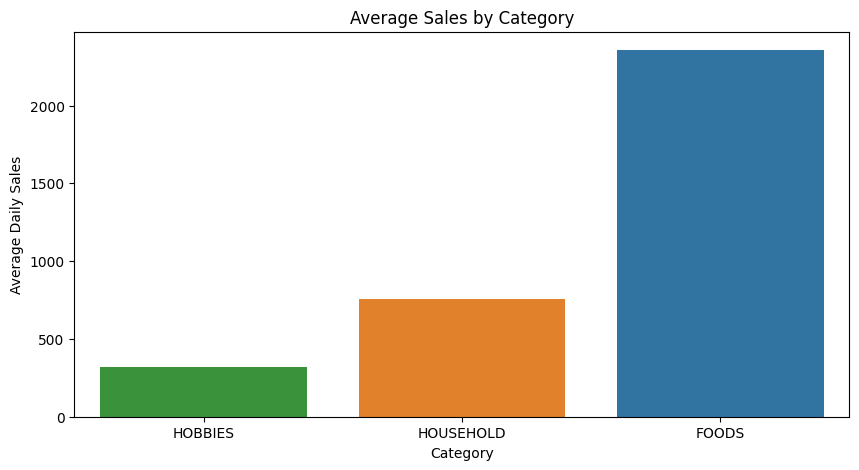

In [14]:
# Category-Level Demand Distribution
plt.figure(figsize=(10,5))

sns.barplot(
    data=sales_long,
    x='cat_id',
    y='sales',
    estimator='mean',
    errorbar=None,
    palette={'FOODS':'#1f77b4', 'HOUSEHOLD':'#ff7f0e', 'HOBBIES':'#2ca02c'}
)

plt.title("Average Sales by Category")
plt.ylabel("Average Daily Sales")
plt.xlabel("Category")
plt.show()

- FOODS has the highest average demand


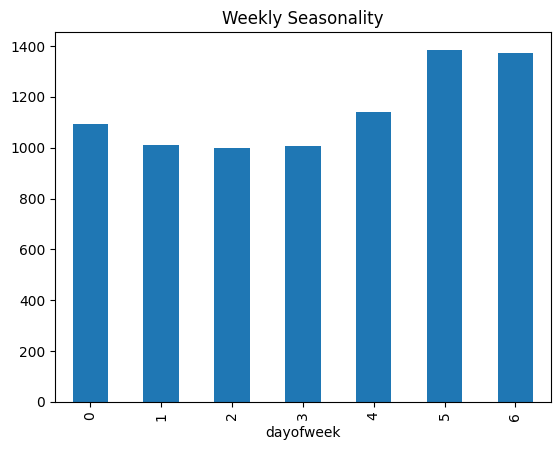

In [15]:
sales_long.groupby('dayofweek')['sales'].mean().plot(kind='bar')
plt.title("Weekly Seasonality")
plt.show()

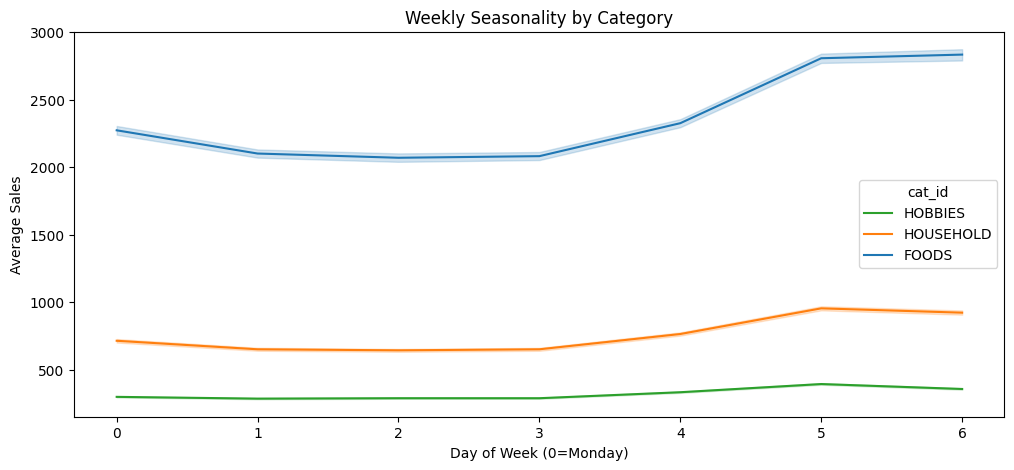

In [16]:
# Weekly Seasonality by Category
plt.figure(figsize=(12,5))

sns.lineplot(
    data=sales_long,
    x='dayofweek',
    y='sales',
    hue='cat_id',
    palette={'FOODS':'#1f77b4', 'HOUSEHOLD':'#ff7f0e', 'HOBBIES':'#2ca02c'}
)

plt.title("Weekly Seasonality by Category")
plt.xlabel("Day of Week (0=Monday)")
plt.ylabel("Average Sales")
plt.show()

- FOODS peaks strongly on weekends
- HOBBIES shows weaker weekly structure
- HOUSEHOLD remains relatively stable

Weekly lag features (lag_7) are critical predictors.

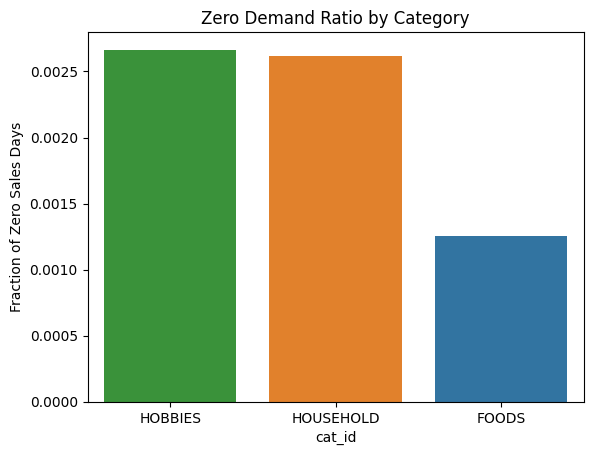

In [17]:
# Zero Demand Analysis
zero_ratio = sales_long.groupby('cat_id')['sales'].apply(lambda x: (x==0).mean()).reset_index()

sns.barplot(
    data=zero_ratio,
    x='cat_id',
    y='sales',
    palette={'FOODS':'#1f77b4', 'HOUSEHOLD':'#ff7f0e', 'HOBBIES':'#2ca02c'}
)

plt.title("Zero Demand Ratio by Category")
plt.ylabel("Fraction of Zero Sales Days")
plt.show()

- HOBBIES has the highest proportion of zero-demand days
- FOODS has the lowest zero rate (more consistent demand)

This confirms intermittent demand structure → important for choosing models like:
- XGBoost (good)
- Deep learning (good)

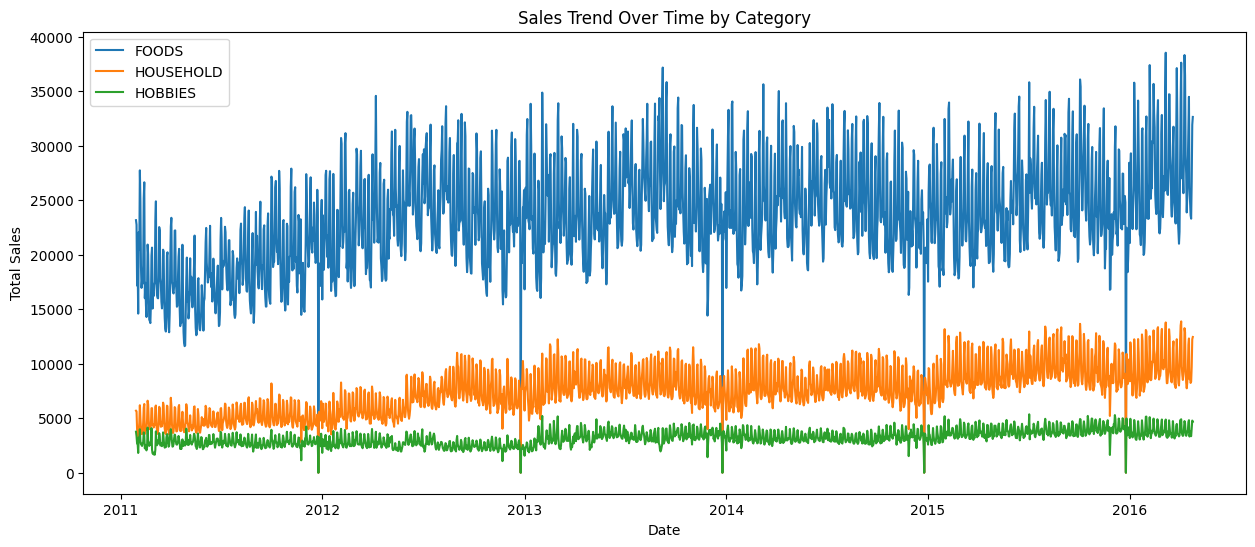

In [18]:
# Time Trend by Category
df_time = sales_long.groupby(['date','cat_id'])['sales'].sum().reset_index()

plt.figure(figsize=(15,6))

for cat, color in zip(
    ['FOODS','HOUSEHOLD','HOBBIES'],
    ['#1f77b4','#ff7f0e','#2ca02c']
):
    subset = df_time[df_time['cat_id'] == cat]
    plt.plot(subset['date'], subset['sales'], label=cat, color=color)

plt.legend()
plt.title("Sales Trend Over Time by Category")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

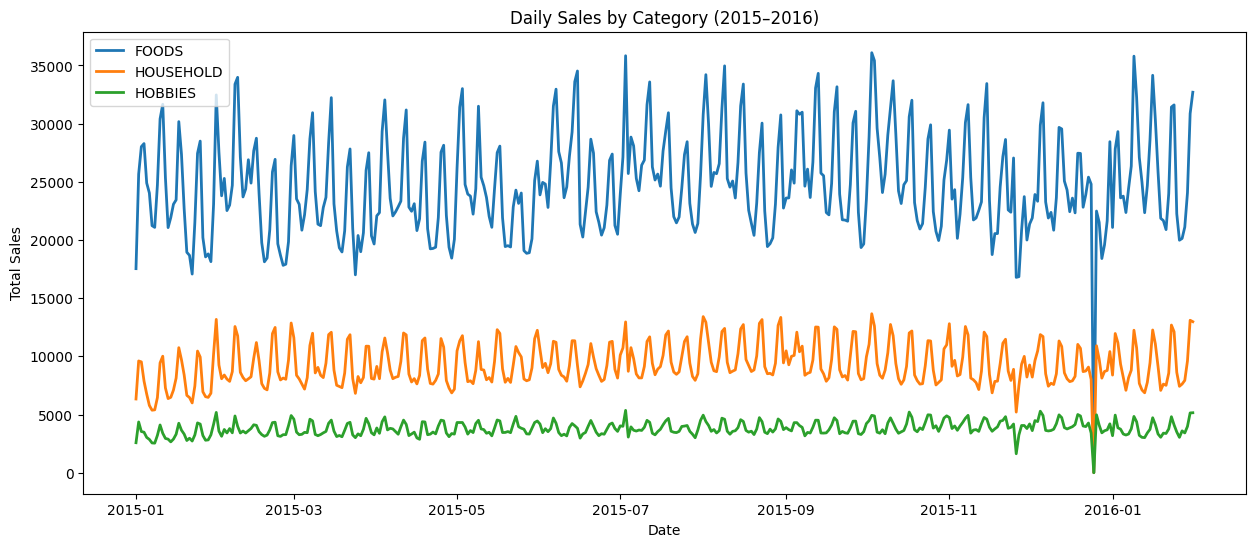

In [19]:
# Plot One or Two Years Only
df_plot = df_time[
    (df_time['date'] >= '2015-01-01') &
    (df_time['date'] <= '2016-01-31')
]

plt.figure(figsize=(15,6))

palette = {
    'FOODS':'#1f77b4',
    'HOUSEHOLD':'#ff7f0e',
    'HOBBIES':'#2ca02c'
}

for cat in palette:
    subset = df_plot[df_plot['cat_id'] == cat]
    plt.plot(
        subset['date'],
        subset['sales'],
        color=palette[cat],
        label=cat,
        linewidth=2
    )

plt.title("Daily Sales by Category (2015–2016)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

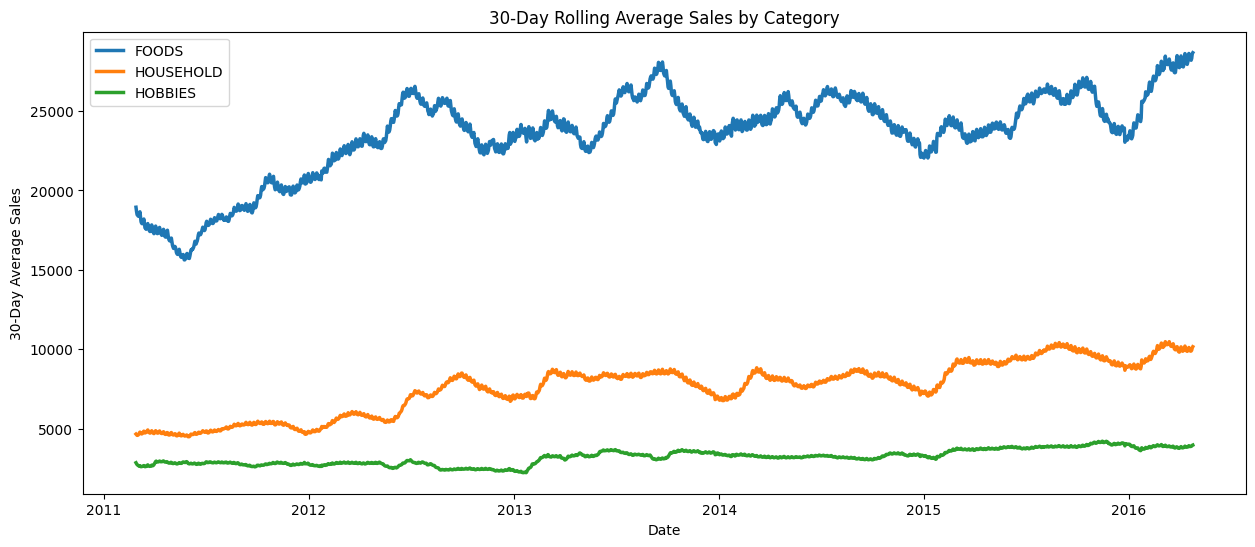

In [20]:
# Add a Rolling Average
df_plot = (
    sales_long.groupby(['date','cat_id'])['sales']
      .sum()
      .reset_index()
)

df_plot['rolling_30'] = (
    df_plot.groupby('cat_id')['sales']
           .transform(lambda x: x.rolling(30).mean())
)

plt.figure(figsize=(15,6))

for cat in palette:
    subset = df_plot[df_plot['cat_id']==cat]

    plt.plot(
        subset['date'],
        subset['rolling_30'],
        label=cat,
        color=palette[cat],
        linewidth=2.5
    )

plt.title("30-Day Rolling Average Sales by Category")
plt.xlabel("Date")
plt.ylabel("30-Day Average Sales")
plt.legend()
plt.show()

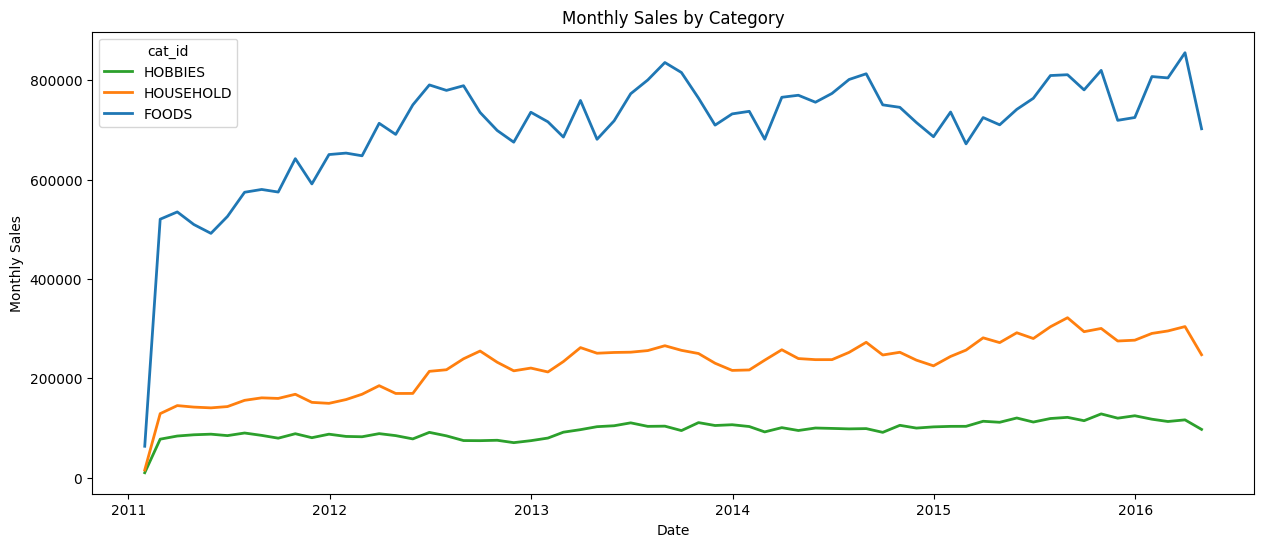

In [21]:
# Monthly Aggregation
monthly_sales = (
    sales_long.groupby([
        pd.Grouper(key='date', freq='M'),
        'cat_id'
    ])['sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,6))

sns.lineplot(
    data=monthly_sales,
    x='date',
    y='sales',
    hue='cat_id',
    palette=palette,
    linewidth=2
)

plt.title("Monthly Sales by Category")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.show()

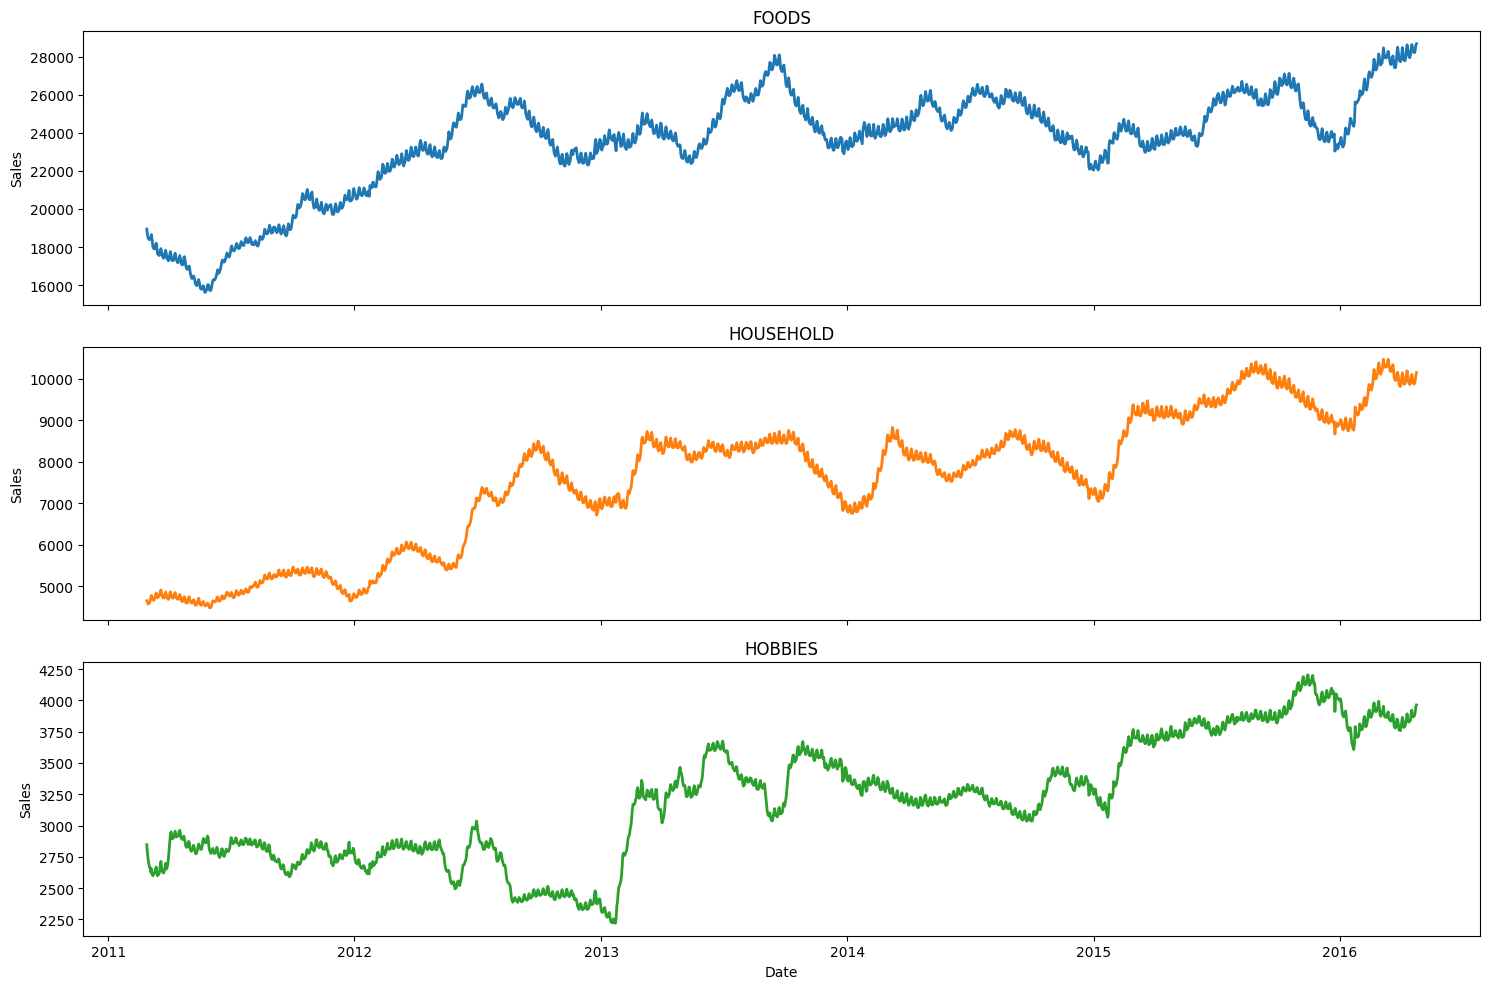

In [22]:
# Small Multiples
fig, axes = plt.subplots(3, 1, figsize=(15,10), sharex=True)

categories = ['FOODS','HOUSEHOLD','HOBBIES']

for ax, cat in zip(axes, categories):

    subset = df_plot[df_plot['cat_id']==cat]

    ax.plot(
        subset['date'],
        subset['rolling_30'],
        color=palette[cat],
        linewidth=2
    )

    ax.set_title(cat)
    ax.set_ylabel("Sales")

plt.xlabel("Date")
plt.tight_layout()

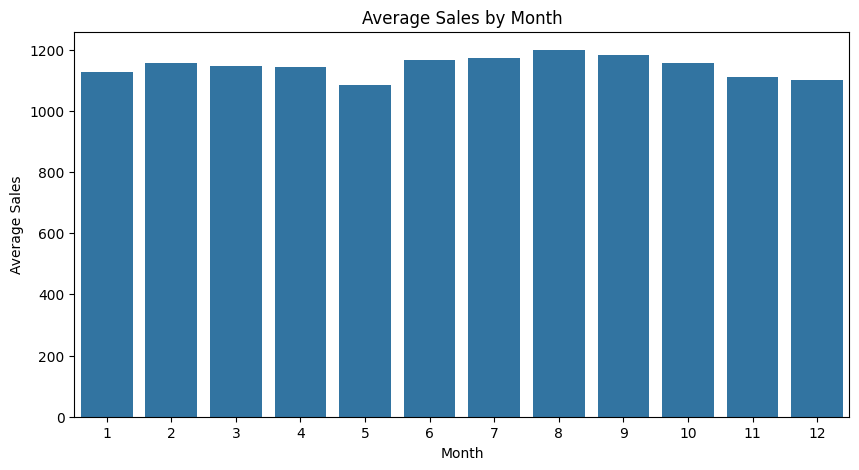

In [23]:
# Average Sales by Month
monthly_avg = sales_long.groupby('month')['sales'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_avg,
    x='month',
    y='sales',
    color='#1f77b4'
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

- Clear seasonal variation across months
- Some months show significantly higher demand

Justifies:
- monthly seasonality features
- calendar-based ML features

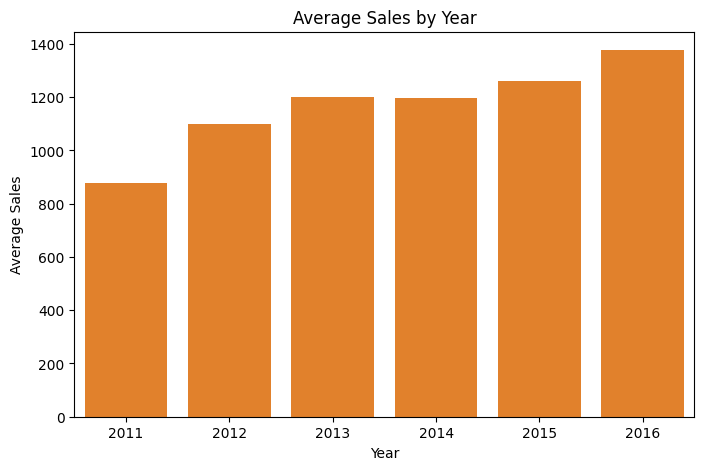

In [24]:
# Average Sales by Year
yearly_avg = sales_long.groupby('year')['sales'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_avg,
    x='year',
    y='sales',
    color='#ff7f0e'
)

plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.show()

- Shows long-term trend in demand
- Helps identify growth or decline patterns


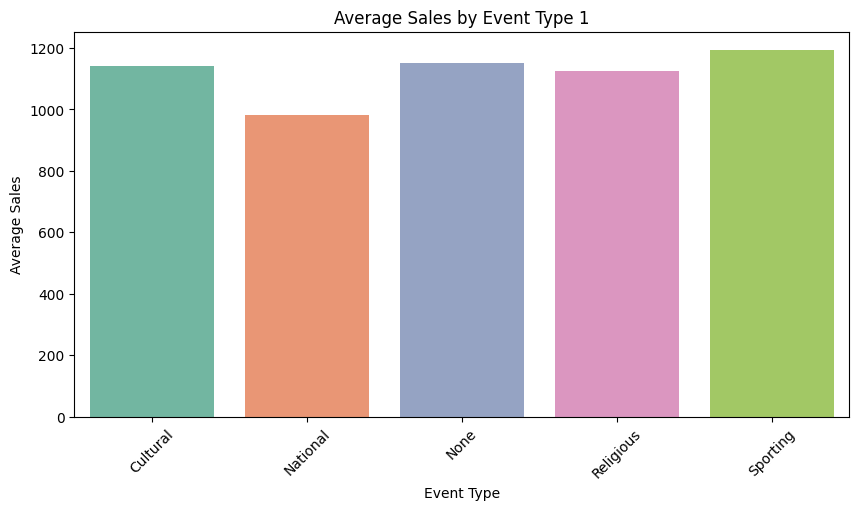

In [25]:
# Average Sales by Event Type
event_avg = sales_long.groupby('event_type_1')['sales'].mean().reset_index()

palette = sns.color_palette("Set2", n_colors=len(event_avg))
plt.figure(figsize=(10,5))

sns.barplot(
    data=event_avg,
    x='event_type_1',
    y='sales',
    palette=palette
)

plt.title("Average Sales by Event Type 1")
plt.xlabel("Event Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

- Events significantly influence demand patterns
- Certain event types correspond to demand spikes


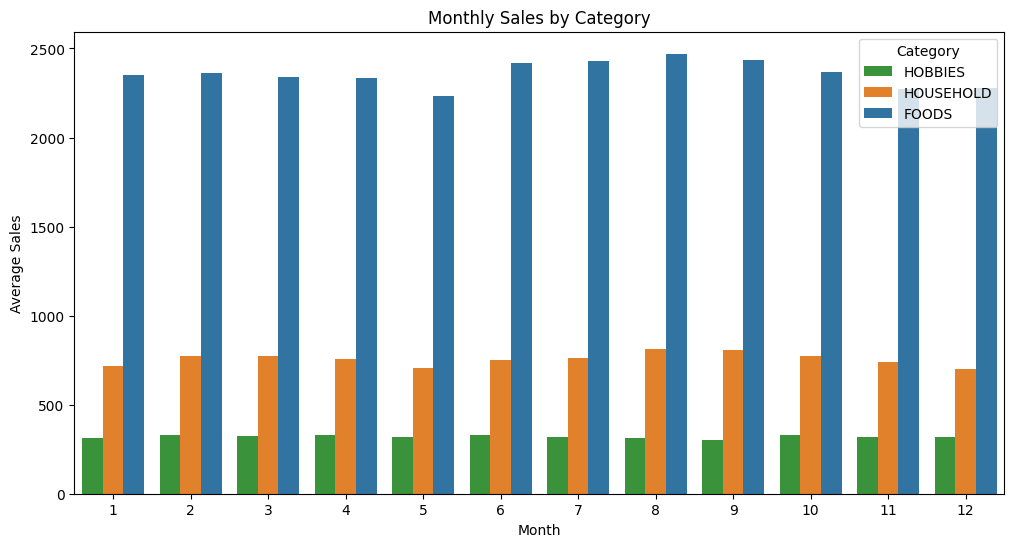

In [26]:
# Sales by Month & Category
cat_month = sales_long.groupby(['month','cat_id'])['sales'].mean().reset_index()

plt.figure(figsize=(12,6))

palette = {
    'FOODS': '#1f77b4',
    'HOUSEHOLD': '#ff7f0e',
    'HOBBIES': '#2ca02c'
}

sns.barplot(
    data=cat_month,
    x='month',
    y='sales',
    hue='cat_id',
    palette=palette
)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.legend(title="Category")
plt.show()

- FOODS dominates demand across all months
- HOBBIES remains consistently low and sparse
- HOUSEHOLD shows moderate seasonal variation

Confirms:
- category-specific forecasting behavior
- need for hierarchical or segmented models

In [27]:
# Time Series Analysis
# Moving Average
daily_sales = (
    sales_long.groupby('date')['sales']
      .sum()
      .reset_index()
)
daily_sales['MA_7'] = (
    daily_sales['sales']
    .rolling(7)
    .mean()
)
# Moving Average Plot


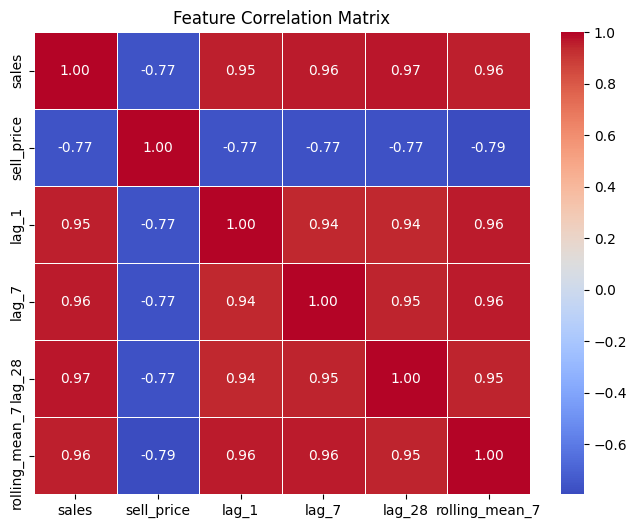

In [28]:

# Correlation Matrix
corr = sales_long[
    ['sales',
     'sell_price',
     'lag_1',
     'lag_7',
     'lag_28',
     'rolling_mean_7']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")

plt.show()

### Feature set

The  features include eight demand lags, four rolling means, three rolling standard deviations, short-window distribution summaries, price-relative measures, cyclic calendar features, and simple event flags. Raw `year` is excluded from modelling and replaced by `time_idx`, which represents the gradual passage of time more naturally.


## 7. Time-safe training and test preparation

The final 28 days are reserved as an untouched test period, matching the forecasting horizon used in the M5. The training and test sets are separated by date so that all 30 store-category series use the same evaluation window.

Lag and rolling features for the test period are not taken directly from the prepared dataset because some of them would contain actual test-period demand. These features will instead be updated recursively when each model generates its forecasts.

In [29]:
# define the features used by the forecasting models

categorical_features = [
    "store_id",
    "state_id",
    "cat_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

numeric_features = [
    # price and promotion features
    "sell_price",
    "price_change_1",
    "price_change_7",
    "price_mean_28",
    "price_vs_mean_28",
    "price_pct_change_7",
    "snap",

    # demand lag features
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_35",
    "lag_42",
    "lag_56",

    # rolling demand features
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_mean_56",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_28",
    "rolling_median_7",
    "rolling_min_7",
    "rolling_max_7",

    # demand momentum features
    "change_1_vs_7",
    "change_7_vs_14",
    "change_7_vs_28",
    "ratio_7_vs_28",

    # calendar and event features
    "day",
    "dayofweek",
    "week",
    "month",
    "quarter",
    "dayofyear",
    "is_weekend",
    "is_event_day",
    "has_two_events",
    "time_idx",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos"
]

feature_columns = categorical_features + numeric_features

print("Number of categorical features:", len(categorical_features))
print("Number of numeric features:", len(numeric_features))
print("Total number of model features:", len(feature_columns))

Number of categorical features: 7
Number of numeric features: 45
Total number of model features: 52


In [30]:
# reserve the final 28 days for out-of-sample testing

forecast_horizon = 28

test_end = model_data["date"].max()
test_start = test_end - pd.Timedelta(days=forecast_horizon - 1)
train_end = test_start - pd.Timedelta(days=1)

train_df = model_data[
    model_data["date"] <= train_end
].copy()

test_df = model_data[
    model_data["date"].between(test_start, test_end)
].copy()

train_df = train_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

test_df = test_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

print("Training period:")
print(train_df["date"].min().date(), "to", train_df["date"].max().date())

print("\nTesting period:")
print(test_df["date"].min().date(), "to", test_df["date"].max().date())

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Number of series:", test_df.groupby(["store_id", "cat_id"]).ngroups)

Training period:
2011-03-26 to 2016-03-27

Testing period:
2016-03-28 to 2016-04-24

Training rows: 54870
Testing rows: 840
Number of series: 30


In [31]:
# confirm that every series has a complete 28-day test period

test_series_counts = (
    test_df
    .groupby(["store_id", "cat_id"], observed=True)
    .size()
    .reset_index(name="test_days")
)

display(test_series_counts)

print(
    "All series have 28 test days:",
    test_series_counts["test_days"].eq(forecast_horizon).all()
)

,store_id,cat_id,test_days
0,CA_1,HOBBIES,28
1,CA_1,HOUSEHOLD,28
2,CA_1,FOODS,28
3,CA_2,HOBBIES,28
4,CA_2,HOUSEHOLD,28
5,CA_2,FOODS,28
6,CA_3,HOBBIES,28
7,CA_3,HOUSEHOLD,28
8,CA_3,FOODS,28
9,CA_4,HOBBIES,28


All series have 28 test days: True


The final test period contains 28 observations for each of the 30 store-category series. Using the same dates for every series ensures that model performance is evaluated consistently across stores and categories. The test period remains completely separate from model training and hyperparameter selection.

## 8. Preliminary feature importance analysis

A preliminary Random Forest model is trained on the historical training period to examine which engineered features contribute most strongly to demand prediction.

This model is used only for feature interpretation. It is not considered the final Random Forest model because its hyperparameters have not yet been selected using time-series cross-validation.

Feature importance is calculated using training data only, ensuring that the final 28-day test period remains untouched.

In [32]:
# prepare the training data for feature importance analysis

feature_importance_data = train_df[
    feature_columns + ["sales"]
].copy()

feature_importance_data = pd.get_dummies(
    feature_importance_data,
    columns=categorical_features,
    dummy_na=True
)

X_feature_importance = feature_importance_data.drop(
    columns="sales"
)

y_feature_importance = feature_importance_data["sales"]

X_feature_importance = X_feature_importance.replace(
    [np.inf, -np.inf],
    np.nan
)

X_feature_importance = X_feature_importance.fillna(0)

print("Training rows:", X_feature_importance.shape[0])
print("Number of encoded features:", X_feature_importance.shape[1])

Training rows: 54870
Number of encoded features: 112


In [33]:
# train a preliminary random forest for feature interpretation

from sklearn.ensemble import RandomForestRegressor

feature_importance_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=14,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

feature_importance_model.fit(
    X_feature_importance,
    y_feature_importance
)

RandomForestRegressor(max_depth=14, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [34]:
# create a table of random forest feature importances

feature_importance = (
    pd.DataFrame({
        "feature": X_feature_importance.columns,
        "importance": feature_importance_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

,feature,importance
0,lag_28,0.089946
1,lag_1,0.086689
2,lag_7,0.083282
3,rolling_mean_7,0.078267
4,rolling_mean_14,0.072726
5,rolling_mean_56,0.058458
6,rolling_mean_28,0.056275
7,lag_35,0.054922
8,rolling_median_7,0.051511
9,lag_42,0.044227


In [35]:
# assign encoded features to their original feature groups

def get_feature_group(feature_name):
    for categorical_feature in categorical_features:
        if feature_name.startswith(f"{categorical_feature}_"):
            return categorical_feature

    return feature_name


feature_importance["feature_group"] = (
    feature_importance["feature"]
    .apply(get_feature_group)
)

grouped_feature_importance = (
    feature_importance
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(grouped_feature_importance.head(20))

,feature_group,importance
0,lag_28,0.089946
1,lag_1,0.086689
2,lag_7,0.083282
3,rolling_mean_7,0.078267
4,rolling_mean_14,0.072726
5,rolling_mean_56,0.058458
6,rolling_mean_28,0.056275
7,lag_35,0.054922
8,rolling_median_7,0.051511
9,lag_42,0.044227


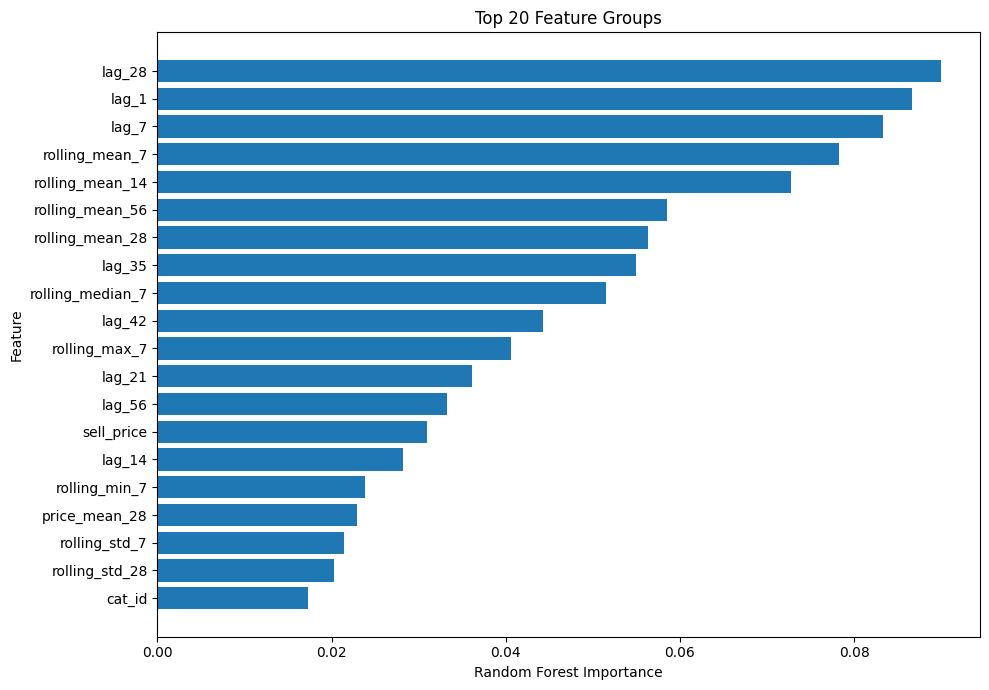

In [36]:
# plot the most important feature groups

plot_data = (
    grouped_feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["feature_group"],
    plot_data["importance"]
)

plt.title("Top 20 Feature Groups")
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

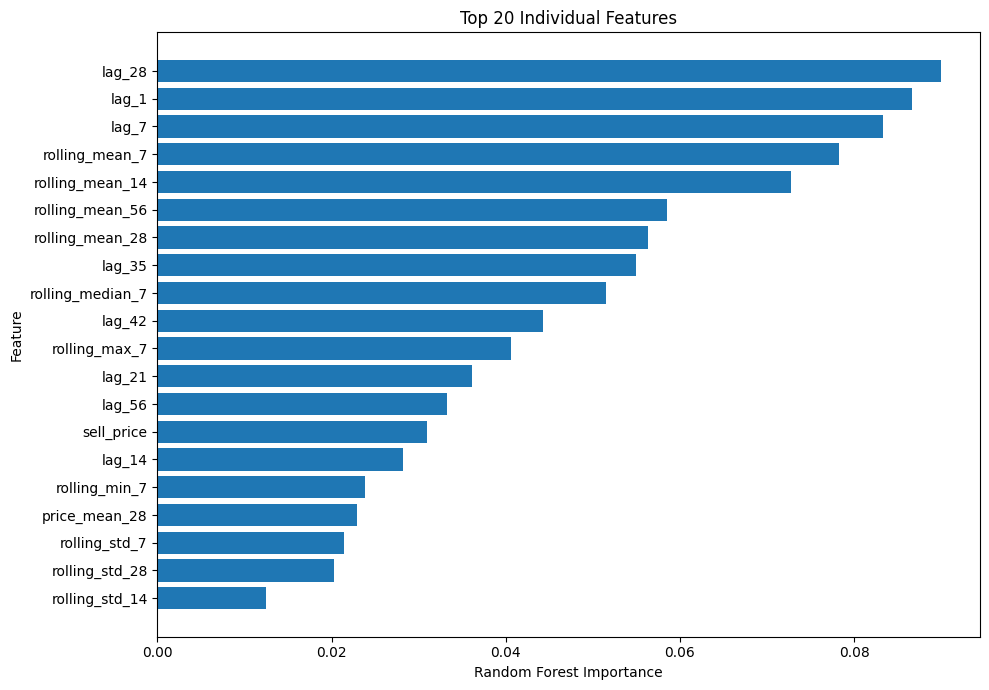

In [37]:
# plot the most important individual model features

plot_data = (
    feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["feature"],
    plot_data["importance"]
)

plt.title("Top 20 Individual Features")
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature importance analysis

The preliminary Random Forest results show that historical demand features dominate the prediction task. The three most influential variables are the 28-day, 1-day, and 7-day lags, indicating that both recent demand and recurring monthly and weekly purchasing patterns strongly influence future sales.

Rolling averages also rank among the most important predictors. The high importance of the 7-, 14-, 28-, and 56-day rolling means suggests that smoothed demand trends provide complementary information beyond individual lag observations by reducing the impact of daily fluctuations.

Price-related variables, including the current selling price and the 28-day average price, contribute additional predictive power but are less influential than historical demand. This indicates that demand is primarily driven by purchasing history, while pricing provides useful contextual information.

Category also appears among the most important predictors, confirming that demand behaviour differs across product groups and supporting the use of a global forecasting model that includes categorical identifiers.

Overall, the results are consistent with the exploratory data analysis, where strong weekly and monthly demand patterns were observed. These findings justify retaining the lag, rolling, price, and categorical features in the subsequent forecasting models.

## 9. Evaluation framework

The forecasting models are evaluated over the final 28-day test period using four complementary metrics:

- **MAE** measures the average absolute error in sales units and provides an interpretable measure of forecast accuracy.
- **RMSE** penalizes large forecasting errors more heavily than MAE.
- **WAPE** expresses total absolute forecast error as a percentage of total actual demand.
- **WRMSSE** adjusts the forecast error of each store-category series for its historical variability and assigns greater weight to series with higher recent revenue.

Since this project models demand at the store-category level, WRMSSE is calculated across the 30 store-category series. This preserves the scaling and revenue-weighting principles of the original metric while matching the forecasting level used in this analysis.

In [38]:
# import the libraries used for model evaluation

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# define mae, rmse, and wape

def calculate_mae(actual, predicted):
    actual = np.asarray(actual, dtype="float64")
    predicted = np.asarray(predicted, dtype="float64")

    return mean_absolute_error(actual, predicted)


def calculate_rmse(actual, predicted):
    actual = np.asarray(actual, dtype="float64")
    predicted = np.asarray(predicted, dtype="float64")

    return np.sqrt(
        mean_squared_error(actual, predicted)
    )


def calculate_wape(actual, predicted):
    actual = np.asarray(actual, dtype="float64")
    predicted = np.asarray(predicted, dtype="float64")

    total_actual = np.abs(actual).sum()

    if total_actual == 0:
        return np.nan

    total_error = np.abs(actual - predicted).sum()

    return 100 * total_error / total_actual

In [39]:
# define the forecasting series

series_columns = [
    "store_id",
    "cat_id"
]

number_of_series = (
    train_df[series_columns]
    .drop_duplicates()
    .shape[0]
)

print("Number of store-category series:", number_of_series)
print("Forecast horizon:", forecast_horizon)

Number of store-category series: 30
Forecast horizon: 28


In [40]:
# calculate the rmsse scale for each series

rmsse_scale_records = []

for series_key, series_data in train_df.groupby(
    series_columns,
    observed=True
):
    store_id, cat_id = series_key

    training_sales = (
        series_data
        .sort_values("date")["sales"]
        .to_numpy(dtype="float64")
    )

    nonzero_positions = np.flatnonzero(
        training_sales != 0
    )

    if len(nonzero_positions) > 0:
        first_nonzero_position = nonzero_positions[0]
        training_sales = training_sales[first_nonzero_position:]

    if len(training_sales) < 2:
        scale = np.nan
    else:
        one_step_changes = np.diff(training_sales)
        scale = np.mean(one_step_changes ** 2)

    if not np.isfinite(scale) or scale <= 0:
        scale = np.nan

    rmsse_scale_records.append({
        "store_id": store_id,
        "cat_id": cat_id,
        "scale": scale
    })

rmsse_scale = pd.DataFrame(rmsse_scale_records)

display(rmsse_scale.head())

,store_id,cat_id,scale
0,CA_1,HOBBIES,15147.742888
1,CA_1,HOUSEHOLD,37056.814004
2,CA_1,FOODS,385025.882932
3,CA_2,HOBBIES,11172.102845
4,CA_2,HOUSEHOLD,67620.056893


In [41]:
# inspect the rmsse scale values

display(
    rmsse_scale
    .sort_values("scale")
    .reset_index(drop=True)
)

print(
    "Series with missing scale:",
    rmsse_scale["scale"].isna().sum()
)

print(
    "Minimum valid scale:",
    rmsse_scale["scale"].min()
)

print(
    "Maximum valid scale:",
    rmsse_scale["scale"].max()
)

,store_id,cat_id,scale
0,WI_2,HOBBIES,3980.416302
1,CA_4,HOUSEHOLD,4571.219912
2,TX_1,HOBBIES,4996.822210
3,TX_3,HOBBIES,5269.596827
4,WI_3,HOBBIES,5475.776258
5,CA_4,HOBBIES,6218.602845
6,TX_2,HOBBIES,7987.228665
7,CA_2,HOBBIES,11172.102845
8,CA_3,HOBBIES,14536.240700
9,CA_1,HOBBIES,15147.742888


Series with missing scale: 0
Minimum valid scale: 3980.4163019693656
Maximum valid scale: 431616.42450765864


In [42]:
# calculate revenue during the final 28 training days

weight_start_date = (
    train_end
    - pd.Timedelta(days=forecast_horizon - 1)
)

weight_data = train_df[
    train_df["date"].between(
        weight_start_date,
        train_end
    )
].copy()

weight_data["revenue"] = (
    weight_data["sales"]
    * weight_data["sell_price"]
)

print(
    "Weight period:",
    weight_data["date"].min().date(),
    "to",
    weight_data["date"].max().date()
)

print("Weight rows:", len(weight_data))

Weight period: 2016-02-29 to 2016-03-27
Weight rows: 840


In [43]:
# calculate the revenue weight for each series

revenue_weights = (
    weight_data
    .groupby(
        series_columns,
        observed=True,
        as_index=False
    )["revenue"]
    .sum()
)

total_revenue = revenue_weights["revenue"].sum()

if total_revenue <= 0:
    raise ValueError(
        "Total revenue must be greater than zero."
    )

revenue_weights["weight"] = (
    revenue_weights["revenue"]
    / total_revenue
)

display(
    revenue_weights
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

print(
    "Sum of revenue weights:",
    revenue_weights["weight"].sum()
)

,store_id,cat_id,revenue,weight
0,CA_3,FOODS,383413.875000,0.080582
1,WI_2,FOODS,361774.687500,0.076035
2,CA_1,FOODS,279231.750000,0.058686
3,WI_3,FOODS,271273.781250,0.057014
4,CA_3,HOUSEHOLD,269597.125000,0.056661
5,TX_2,FOODS,255054.140625,0.053605
6,CA_2,FOODS,254123.187500,0.053409
7,WI_1,FOODS,250765.062500,0.052704
8,TX_3,FOODS,234722.093750,0.049332
9,TX_1,FOODS,191305.968750,0.040207


Sum of revenue weights: 0.99999994


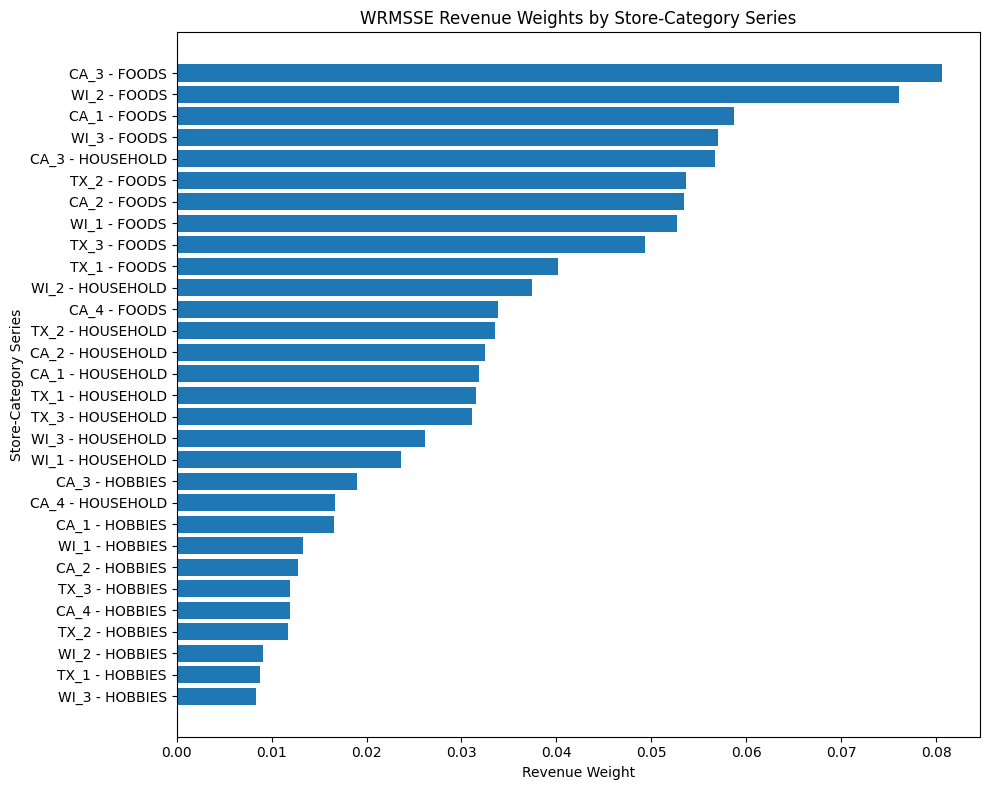

In [44]:
# plot the revenue weights by store-category series

weight_plot_data = revenue_weights.copy()

weight_plot_data["series"] = (
    weight_plot_data["store_id"].astype(str)
    + " - "
    + weight_plot_data["cat_id"].astype(str)
)

weight_plot_data = weight_plot_data.sort_values(
    "weight",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    weight_plot_data["series"],
    weight_plot_data["weight"]
)

plt.title("WRMSSE Revenue Weights by Store-Category Series")
plt.xlabel("Revenue Weight")
plt.ylabel("Store-Category Series")
plt.tight_layout()
plt.show()

### RMSSE scale analysis

The RMSSE scale values vary considerably across the 30 store-category series, reflecting differences in demand volume and historical volatility.

The FOODS series have the largest scale values, indicating substantially greater day-to-day changes in demand. In contrast, most HOBBIES series have smaller scale values because their sales volumes and absolute fluctuations are lower.

This scaling is important because it makes forecasting errors more comparable across series. A raw error of the same size has a different meaning

In [46]:
# evaluate one model using all forecasting metrics

def evaluate_forecast(
    model_name,
    evaluation_data,
    scale_table=rmsse_scale,
    weight_table=revenue_weights
):
    evaluation_data = evaluation_data.copy()

    evaluation_data["sales"] = pd.to_numeric(
        evaluation_data["sales"],
        errors="coerce"
    )

    evaluation_data["prediction"] = pd.to_numeric(
        evaluation_data["prediction"],
        errors="coerce"
    )

    if evaluation_data[
        ["sales", "prediction"]
    ].isna().any().any():
        raise ValueError(
            "Actual or predicted values contain missing values."
        )

    evaluation_data["prediction"] = (
        evaluation_data["prediction"]
        .clip(lower=0)
    )

    actual = evaluation_data[
        "sales"
    ].to_numpy(dtype="float64")

    predicted = evaluation_data[
        "prediction"
    ].to_numpy(dtype="float64")

    wrmsse, series_metrics = calculate_wrmsse(
        evaluation_data=evaluation_data,
        scale_table=scale_table,
        weight_table=weight_table,
        actual_column="sales",
        prediction_column="prediction"
    )

    model_metrics = {
        "model": model_name,
        "mae": calculate_mae(
            actual,
            predicted
        ),
        "rmse": calculate_rmse(
            actual,
            predicted
        ),
        "wape": calculate_wape(
            actual,
            predicted
        ),
        "wrmsse": wrmsse
    }

    return model_metrics, series_metrics

In [45]:
# calculate wrmsse across the store-category series

def calculate_wrmsse(
    evaluation_data,
    scale_table,
    weight_table,
    actual_column="sales",
    prediction_column="prediction"
):
    required_columns = (
        series_columns
        + [actual_column, prediction_column]
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in evaluation_data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing evaluation columns: {missing_columns}"
        )

    series_error_records = []

    for series_key, series_data in evaluation_data.groupby(
        series_columns,
        observed=True
    ):
        store_id, cat_id = series_key

        actual = series_data[
            actual_column
        ].to_numpy(dtype="float64")

        predicted = series_data[
            prediction_column
        ].to_numpy(dtype="float64")

        forecast_mse = np.mean(
            (actual - predicted) ** 2
        )

        series_error_records.append({
            "store_id": store_id,
            "cat_id": cat_id,
            "forecast_mse": forecast_mse
        })

    series_results = pd.DataFrame(
        series_error_records
    )

    series_results = series_results.merge(
        scale_table,
        on=series_columns,
        how="left",
        validate="one_to_one"
    )

    series_results = series_results.merge(
        weight_table[
            series_columns + ["weight"]
        ],
        on=series_columns,
        how="left",
        validate="one_to_one"
    )

    series_results["rmsse"] = np.sqrt(
        series_results["forecast_mse"]
        / series_results["scale"]
    )

    valid_results = series_results.dropna(
        subset=["rmsse", "weight"]
    ).copy()

    if valid_results.empty:
        return np.nan, series_results

    valid_weight_total = valid_results[
        "weight"
    ].sum()

    if valid_weight_total <= 0:
        return np.nan, series_results

    valid_results["normalized_weight"] = (
        valid_results["weight"]
        / valid_weight_total
    )

    valid_results["weighted_rmsse"] = (
        valid_results["rmsse"]
        * valid_results["normalized_weight"]
    )

    wrmsse = valid_results[
        "weighted_rmsse"
    ].sum()

    series_results = series_results.merge(
        valid_results[
            series_columns
            + [
                "normalized_weight",
                "weighted_rmsse"
            ]
        ],
        on=series_columns,
        how="left"
    )

    return wrmsse, series_results

In [47]:
# calculate mae, rmse, and wape for each series

def evaluate_forecast_by_series(
    evaluation_data
):
    series_metric_records = []

    for series_key, series_data in evaluation_data.groupby(
        series_columns,
        observed=True
    ):
        store_id, cat_id = series_key

        actual = series_data[
            "sales"
        ].to_numpy(dtype="float64")

        predicted = series_data[
            "prediction"
        ].to_numpy(dtype="float64")

        series_metric_records.append({
            "store_id": store_id,
            "cat_id": cat_id,
            "mae": calculate_mae(
                actual,
                predicted
            ),
            "rmse": calculate_rmse(
                actual,
                predicted
            ),
            "wape": calculate_wape(
                actual,
                predicted
            )
        })

    return pd.DataFrame(
        series_metric_records
    )

In [48]:
# calculate model performance by category

def evaluate_forecast_by_category(
    evaluation_data
):
    category_metric_records = []

    for category, category_data in evaluation_data.groupby(
        "cat_id",
        observed=True
    ):
        actual = category_data[
            "sales"
        ].to_numpy(dtype="float64")

        predicted = category_data[
            "prediction"
        ].to_numpy(dtype="float64")

        category_metric_records.append({
            "cat_id": category,
            "mae": calculate_mae(
                actual,
                predicted
            ),
            "rmse": calculate_rmse(
                actual,
                predicted
            ),
            "wape": calculate_wape(
                actual,
                predicted
            )
        })

    return pd.DataFrame(
        category_metric_records
    )

In [49]:
# test the evaluation functions using perfect predictions

evaluation_test = test_df[
    series_columns + ["date", "sales"]
].copy()

evaluation_test["prediction"] = evaluation_test[
    "sales"
]

test_metrics, test_series_metrics = evaluate_forecast(
    model_name="Perfect Forecast Test",
    evaluation_data=evaluation_test
)

display(
    pd.DataFrame([test_metrics])
)

assert np.isclose(
    test_metrics["mae"],
    0
)

assert np.isclose(
    test_metrics["rmse"],
    0
)

assert np.isclose(
    test_metrics["wape"],
    0
)

assert np.isclose(
    test_metrics["wrmsse"],
    0
)

print("Evaluation functions passed the validation test.")

,model,mae,rmse,wape,wrmsse
0,Perfect Forecast Test,0.0,0.0,0.0,0.0


Evaluation functions passed the validation test.


### Evaluation framework summary

The evaluation framework combines scale-dependent, percentage-based, and business-weighted measures of forecast accuracy.

MAE provides an interpretable estimate of the typical error in sales units, while RMSE highlights models that produce occasional large errors. WAPE allows overall forecast error to be communicated as a percentage of demand.

WRMSSE is used as the primary model-selection metric because it accounts for differences in historical demand variability and recent revenue across the 30 store-category series. A lower WRMSSE indicates stronger overall forecasting performance, particularly for high-revenue series.

The same evaluation functions will be applied consistently to every baseline, machine learning, and deep learning model.

## 10. Seasonal Naïve baseline

A seasonal naïve model is used as the baseline forecasting method. Since the exploratory analysis showed strong weekly demand patterns, each day's forecast is generated using the demand observed seven days earlier.

The model produces a recursive 28-day forecast for every store-category series. During forecasting, only historical observations and previously generated predictions are available, ensuring that no future information is used.

The baseline provides a practical benchmark for evaluating whether the machine learning and deep learning models deliver meaningful improvements in forecasting accuracy.

In [50]:
# generate recursive seasonal naive forecasts

seasonal_naive_predictions = []

for (store_id, cat_id), test_series in test_df.groupby(
    ["store_id", "cat_id"],
    observed=True
):

    train_series = (
        train_df[
            (train_df["store_id"] == store_id)
            & (train_df["cat_id"] == cat_id)
        ]
        .sort_values("date")
    )

    demand_history = train_series["sales"].tolist()

    predictions = []

    for _ in range(forecast_horizon):

        prediction = demand_history[-7]

        prediction = max(0, prediction)

        predictions.append(prediction)

        demand_history.append(prediction)

    temp = test_series.copy()

    temp = temp.sort_values("date")

    temp["prediction"] = predictions

    seasonal_naive_predictions.append(temp)

seasonal_naive_results = pd.concat(
    seasonal_naive_predictions,
    ignore_index=True
)

seasonal_naive_results.head()

,store_id,state_id,cat_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day,dayofweek,week,quarter,dayofyear,is_weekend,time_idx,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,snap,is_event_day,has_two_events,lag_1,lag_7,lag_14,lag_21,lag_28,lag_35,lag_42,lag_56,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_mean_56,rolling_std_7,rolling_std_14,rolling_std_28,rolling_median_7,rolling_min_7,rolling_max_7,change_1_vs_7,change_7_vs_14,change_7_vs_28,ratio_7_vs_28,price_change_1,price_change_7,price_mean_28,price_vs_mean_28,price_pct_change_7,prediction
0,CA_1,CA,HOBBIES,d_1886,535,2016-03-28,11609,Monday,3,3,2016,None,None,None,None,0,0,0,5.571486,28,0,13,1,88,0,1885,0.000000,1.000000,1.000000,6.123234e-17,0.998377,0.056952,0,0,0,369.0,532.0,461.0,470.0,414.0,539.0,476.0,527.0,475.000000,479.571442,505.071442,517.946411,76.613747,82.209595,109.475494,454.0,369.0,610.0,-163.0,71.0,118.0,1.285024,0.0,0.0,5.573717,0.999600,0.0,532
1,CA_1,CA,HOBBIES,d_1887,498,2016-03-29,11609,Tuesday,4,3,2016,None,None,None,None,0,0,0,5.571486,29,1,13,1,89,0,1886,0.781832,0.623490,1.000000,6.123234e-17,0.999209,0.039770,0,0,0,535.0,440.0,431.0,455.0,568.0,414.0,495.0,429.0,475.428558,484.857147,509.392853,518.089294,76.993195,83.295448,108.127274,454.0,369.0,610.0,95.0,9.0,-128.0,0.774648,0.0,0.0,5.573150,0.999701,0.0,440
2,CA_1,CA,HOBBIES,d_1888,465,2016-03-30,11609,Wednesday,5,3,2016,None,None,None,None,0,0,0,5.571486,30,2,13,1,90,0,1887,0.974928,-0.222521,1.000000,6.123234e-17,0.999745,0.022576,0,0,0,498.0,454.0,472.0,464.0,489.0,473.0,557.0,638.0,483.714294,489.642853,506.892853,519.321411,75.654289,81.875710,107.529610,474.0,369.0,610.0,44.0,-18.0,-35.0,0.928425,0.0,0.0,5.572584,0.999803,0.0,454
3,CA_1,CA,HOBBIES,d_1889,536,2016-03-31,11609,Thursday,6,3,2016,None,None,None,None,0,0,0,5.571486,31,3,13,1,91,0,1888,0.433884,-0.900969,1.000000,6.123234e-17,0.999986,0.005376,0,0,0,465.0,474.0,335.0,565.0,436.0,451.0,514.0,491.0,485.285706,489.142853,506.035706,516.232117,75.046021,82.013000,107.772903,474.0,369.0,610.0,-9.0,139.0,38.0,1.087156,0.0,0.0,5.572018,0.999905,0.0,474
4,CA_1,CA,HOBBIES,d_1890,743,2016-04-01,11609,Friday,7,4,2016,None,None,None,None,1,1,0,5.571486,1,4,13,2,92,0,1889,-0.433884,-0.900969,0.866025,-5.000000e-01,0.999930,-0.011826,1,0,0,536.0,446.0,585.0,364.0,441.0,525.0,565.0,503.0,494.142853,503.500000,509.607147,517.035706,77.122040,69.608521,107.020363,498.0,369.0,610.0,90.0,-139.0,5.0,1.011338,0.0,0.0,5.571451,1.000006,0.0,446


In [51]:
# evaluate the seasonal naive model

baseline_metrics, baseline_series = evaluate_forecast(
    model_name="Seasonal Naive",
    evaluation_data=seasonal_naive_results
)

baseline_results = pd.DataFrame(
    [baseline_metrics]
)

display(
    baseline_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Seasonal Naive,186.50,321.00,13.24%,0.9203


In [53]:
# evaluate each store-category series

baseline_by_series = evaluate_forecast_by_series(
    seasonal_naive_results
)

baseline_by_series = baseline_by_series.merge(
    baseline_series[
        [
            "store_id",
            "cat_id",
            "rmsse"
        ]
    ],
    on=["store_id", "cat_id"]
)

display(
    baseline_by_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}"
    })
)

,store_id,cat_id,mae,rmse,wape,rmsse
0,CA_1,HOBBIES,102.25,146.65,19.02%,1.1916
1,CA_1,HOUSEHOLD,124.00,184.63,12.30%,0.9591
2,CA_1,FOODS,343.86,420.12,11.37%,0.6771
3,CA_2,HOBBIES,60.04,76.02,14.43%,0.7192
4,CA_2,HOUSEHOLD,88.86,107.52,7.86%,0.4135
5,CA_2,FOODS,260.43,348.57,8.92%,0.7886
6,CA_3,HOBBIES,60.89,80.89,10.63%,0.6710
7,CA_3,HOUSEHOLD,123.64,162.56,6.94%,0.5947
8,CA_3,FOODS,377.18,459.84,9.51%,0.6999
9,CA_4,HOBBIES,57.14,78.67,15.51%,0.9976


In [54]:
# evaluate forecasting accuracy by category

baseline_by_category = evaluate_forecast_by_category(
    seasonal_naive_results
)

display(
    baseline_by_category.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%"
    })
)

,cat_id,mae,rmse,wape
0,HOBBIES,68.41,91.23,17.29%
1,HOUSEHOLD,119.11,162.39,11.83%
2,FOODS,371.98,523.86,13.17%


In [55]:
# identify the best and worst baseline series

baseline_series_analysis = baseline_by_series.merge(
    revenue_weights[
        ["store_id", "cat_id", "weight"]
    ],
    on=["store_id", "cat_id"],
    how="left"
)

best_baseline_series = (
    baseline_series_analysis
    .nsmallest(5, "rmsse")
    .reset_index(drop=True)
)

worst_baseline_series = (
    baseline_series_analysis
    .nlargest(5, "rmsse")
    .reset_index(drop=True)
)

print("Five best-performing series")

display(
    best_baseline_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}",
        "weight": "{:.2%}"
    })
)

print("Five worst-performing series")

display(
    worst_baseline_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}",
        "weight": "{:.2%}"
    })
)

Five best-performing series


,store_id,cat_id,mae,rmse,wape,rmsse,weight
0,CA_2,HOUSEHOLD,88.86,107.52,7.86%,0.4135,3.25%
1,TX_1,HOUSEHOLD,68.68,88.91,7.40%,0.5370,3.15%
2,CA_3,HOUSEHOLD,123.64,162.56,6.94%,0.5947,5.67%
3,CA_3,HOBBIES,60.89,80.89,10.63%,0.6710,1.90%
4,CA_1,FOODS,343.86,420.12,11.37%,0.6771,5.87%


Five worst-performing series


,store_id,cat_id,mae,rmse,wape,rmsse,weight
0,WI_2,FOODS,885.50,1125.47,22.28%,1.8720,7.60%
1,WI_2,HOUSEHOLD,217.68,277.46,19.27%,1.4872,3.74%
2,WI_1,FOODS,458.18,594.24,17.37%,1.2514,5.27%
3,CA_1,HOBBIES,102.25,146.65,19.02%,1.1916,1.66%
4,TX_3,HOUSEHOLD,133.36,175.54,14.14%,1.1460,3.11%


### Seasonal Naïve baseline analysis

The Seasonal Naïve model achieved a WAPE of **13.24%** and a WRMSSE of **0.9203** over the 28-day forecasting horizon. These results indicate that simply repeating the demand observed one week earlier provides a reasonably strong baseline, confirming the presence of weekly seasonality identified during the exploratory analysis.

Performance varied considerably across the 30 store-category series. The best-performing series were primarily household products, with **CA_2–HOUSEHOLD** achieving the lowest RMSSE (0.4135), followed by **TX_1–HOUSEHOLD** (0.5370) and **CA_3–HOUSEHOLD** (0.5947). These series exhibit relatively stable demand patterns that can be captured effectively by a weekly seasonal forecast.

In contrast, the largest forecasting errors occurred in several food categories. The **WI_2–FOODS** series produced the highest RMSSE (1.8720), followed by **WI_2–HOUSEHOLD** (1.4872) and **WI_1–FOODS** (1.2514). These categories also carry relatively large revenue weights, meaning their forecasting errors contribute substantially to the overall WRMSSE.

Overall, the Seasonal Naïve model provides a meaningful benchmark for evaluating more advanced forecasting models. Machine learning and deep learning approaches should improve upon this baseline by incorporating additional information such as price changes, calendar effects, promotional events, and longer historical demand patterns.

## 11. Time-Series Cross-Validation

A single train-test split provides only one estimate of forecasting performance and may not reflect how the model performs across different time periods. Therefore, time-series cross-validation is used to evaluate candidate models over multiple rolling forecasting windows.

Unlike random cross-validation, TimeSeriesSplit preserves the chronological order of observations. Each fold expands the training period while keeping the validation period in the future, preventing information leakage.

The same forecasting horizon (28 days) is used in every fold, allowing consistent comparison between models before selecting the final model.

In [56]:
# create expanding-window cross-validation folds

from sklearn.model_selection import TimeSeriesSplit

n_splits = 5

tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=forecast_horizon
)

sample_series = (
    train_df[
        (train_df["store_id"] == "CA_1")
        & (train_df["cat_id"] == "FOODS")
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

print("Number of observations:", len(sample_series))

for fold, (train_idx, valid_idx) in enumerate(tscv.split(sample_series), start=1):

    train_end = sample_series.loc[train_idx[-1], "date"]
    valid_start = sample_series.loc[valid_idx[0], "date"]
    valid_end = sample_series.loc[valid_idx[-1], "date"]

    print(
        f"Fold {fold}: "
        f"Train end = {train_end.date()}, "
        f"Validation = {valid_start.date()} to {valid_end.date()}"
    )

Number of observations: 1829
Fold 1: Train end = 2015-11-08, Validation = 2015-11-09 to 2015-12-06
Fold 2: Train end = 2015-12-06, Validation = 2015-12-07 to 2016-01-03
Fold 3: Train end = 2016-01-03, Validation = 2016-01-04 to 2016-01-31
Fold 4: Train end = 2016-01-31, Validation = 2016-02-01 to 2016-02-28
Fold 5: Train end = 2016-02-28, Validation = 2016-02-29 to 2016-03-27


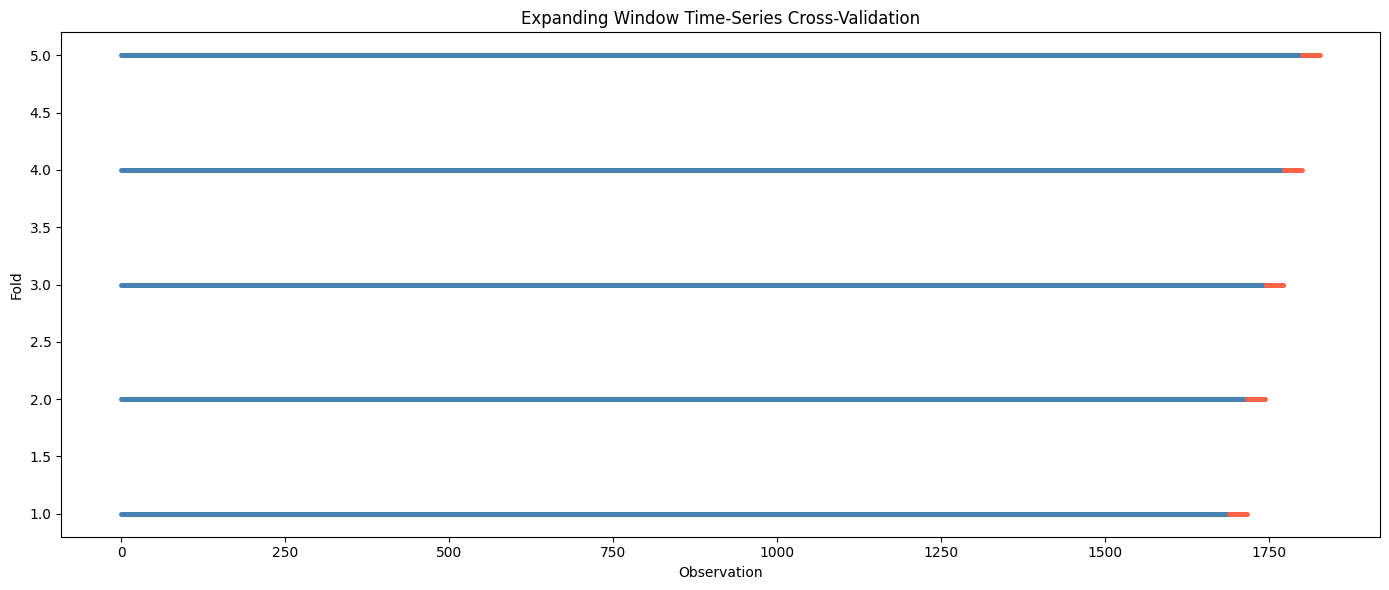

In [57]:
# visualize the cross-validation folds

plt.figure(figsize=(14,6))

for fold, (train_idx, valid_idx) in enumerate(tscv.split(sample_series), start=1):

    plt.scatter(
        train_idx,
        [fold] * len(train_idx),
        color="steelblue",
        s=6
    )

    plt.scatter(
        valid_idx,
        [fold] * len(valid_idx),
        color="tomato",
        s=6
    )

plt.title("Expanding Window Time-Series Cross-Validation")

plt.xlabel("Observation")

plt.ylabel("Fold")

plt.tight_layout()

plt.show()

In [58]:
# summarize the cross-validation folds

cv_summary = []

for fold, (train_idx, valid_idx) in enumerate(tscv.split(sample_series), start=1):

    cv_summary.append({

        "Fold": fold,

        "Training observations": len(train_idx),

        "Validation observations": len(valid_idx),

        "Training end":
            sample_series.loc[train_idx[-1], "date"].date(),

        "Validation start":
            sample_series.loc[valid_idx[0], "date"].date(),

        "Validation end":
            sample_series.loc[valid_idx[-1], "date"].date()
    })

cv_summary = pd.DataFrame(cv_summary)

display(cv_summary)

,Fold,Training observations,Validation observations,Training end,Validation start,Validation end
0,1,1689,28,2015-11-08,2015-11-09,2015-12-06
1,2,1717,28,2015-12-06,2015-12-07,2016-01-03
2,3,1745,28,2016-01-03,2016-01-04,2016-01-31
3,4,1773,28,2016-01-31,2016-02-01,2016-02-28
4,5,1801,28,2016-02-28,2016-02-29,2016-03-27


### Cross-validation strategy

The expanding-window approach increases the amount of historical information available for model training while always evaluating the model on future observations. This closely resembles the operational forecasting process, where new data become available over time and models are updated periodically.

Using multiple validation periods provides a more robust estimate of forecasting performance than a single train-test split. The same cross-validation strategy will be used during hyperparameter tuning for the Random Forest and XGBoost models.

## 12. Random Forest

A global Random Forest model is trained across all 30 store-category series. This allows the model to learn common relationships across stores and product categories while using store and category identifiers to distinguish between individual demand patterns.

The model uses lagged demand, rolling statistics, price information, calendar variables, and event indicators. A fixed 28-day validation window is used for hyperparameter selection. This preserves chronological order and keeps the final 28-day test period independent of model selection.

Both validation and test forecasts are generated recursively. After predicting each date, the predicted demand is added to the available history and used to construct the lag and rolling features for subsequent dates. Therefore, actual future demand is never used as an input.

In [59]:
# create a fixed 28-day validation window

validation_horizon = 28

available_train_dates = np.sort(
    train_df["date"].unique()
)

validation_dates = available_train_dates[
    -validation_horizon:
]

rf_training_df = (
    train_df[
        ~train_df["date"].isin(validation_dates)
    ]
    .copy()
)

rf_validation_df = (
    train_df[
        train_df["date"].isin(validation_dates)
    ]
    .copy()
)

print(
    "Model training period:",
    rf_training_df["date"].min().date(),
    "to",
    rf_training_df["date"].max().date()
)

print(
    "Validation period:",
    rf_validation_df["date"].min().date(),
    "to",
    rf_validation_df["date"].max().date()
)

print("Training rows:", len(rf_training_df))
print("Validation rows:", len(rf_validation_df))
print(
    "Validation dates:",
    rf_validation_df["date"].nunique()
)

Model training period: 2011-03-26 to 2016-02-28
Validation period: 2016-02-29 to 2016-03-27
Training rows: 54030
Validation rows: 840
Validation dates: 28


In [60]:
# define random forest feature columns

excluded_columns = [
    "date",
    "sales"
]

feature_columns = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

categorical_columns = (
    train_df[feature_columns]
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numeric_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Number of model features:", len(feature_columns))
print("Number of numeric features:", len(numeric_columns))
print("Categorical features:", categorical_columns)

Number of model features: 60
Number of numeric features: 51
Categorical features: ['store_id', 'state_id', 'cat_id', 'd', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']


In [61]:
# identify recursively updated demand features

lag_periods = [
    1,
    7,
    14,
    21,
    28,
    35,
    42,
    56
]

rolling_mean_windows = [
    7,
    14,
    28,
    56
]

rolling_std_windows = [
    7,
    14,
    28
]

dynamic_feature_columns = []

for lag in lag_periods:
    column = f"lag_{lag}"

    if column in feature_columns:
        dynamic_feature_columns.append(column)

for window in rolling_mean_windows:
    column = f"rolling_mean_{window}"

    if column in feature_columns:
        dynamic_feature_columns.append(column)

for window in rolling_std_windows:
    column = f"rolling_std_{window}"

    if column in feature_columns:
        dynamic_feature_columns.append(column)

additional_dynamic_features = [
    "rolling_median_7",
    "rolling_min_7",
    "rolling_max_7",
    "lag_1_minus_lag_7",
    "lag_7_minus_lag_14",
    "lag_7_minus_lag_28",
    "lag_7_div_lag_28",
    "trend_1_7",
    "trend_7_14",
    "trend_7_28",
    "lag_ratio_7_28"
]

for column in additional_dynamic_features:
    if column in feature_columns:
        dynamic_feature_columns.append(column)

dynamic_feature_columns = list(
    dict.fromkeys(dynamic_feature_columns)
)

print(
    "Demand features updated recursively:",
    dynamic_feature_columns
)

Demand features updated recursively: ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'lag_42', 'lag_56', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_mean_56', 'rolling_std_7', 'rolling_std_14', 'rolling_std_28', 'rolling_median_7', 'rolling_min_7', 'rolling_max_7']


In [62]:
# calculate dynamic features from available sales history

def calculate_dynamic_features(
    sales_history,
    model_features
):
    history = pd.Series(
        sales_history,
        dtype=float
    )

    calculated_features = {}

    for lag in lag_periods:
        column = f"lag_{lag}"

        if column in model_features:
            calculated_features[column] = (
                history.iloc[-lag]
                if len(history) >= lag
                else np.nan
            )

    for window in rolling_mean_windows:
        column = f"rolling_mean_{window}"

        if column in model_features:
            calculated_features[column] = (
                history.iloc[-window:].mean()
                if len(history) >= 1
                else np.nan
            )

    for window in rolling_std_windows:
        column = f"rolling_std_{window}"

        if column in model_features:
            calculated_features[column] = (
                history.iloc[-window:].std(ddof=0)
                if len(history) >= 2
                else 0.0
            )

    if "rolling_median_7" in model_features:
        calculated_features["rolling_median_7"] = (
            history.iloc[-7:].median()
        )

    if "rolling_min_7" in model_features:
        calculated_features["rolling_min_7"] = (
            history.iloc[-7:].min()
        )

    if "rolling_max_7" in model_features:
        calculated_features["rolling_max_7"] = (
            history.iloc[-7:].max()
        )

    lag_1 = (
        history.iloc[-1]
        if len(history) >= 1
        else np.nan
    )

    lag_7 = (
        history.iloc[-7]
        if len(history) >= 7
        else np.nan
    )

    lag_14 = (
        history.iloc[-14]
        if len(history) >= 14
        else np.nan
    )

    lag_28 = (
        history.iloc[-28]
        if len(history) >= 28
        else np.nan
    )

    trend_values = {
        "lag_1_minus_lag_7": lag_1 - lag_7,
        "lag_7_minus_lag_14": lag_7 - lag_14,
        "lag_7_minus_lag_28": lag_7 - lag_28,
        "trend_1_7": lag_1 - lag_7,
        "trend_7_14": lag_7 - lag_14,
        "trend_7_28": lag_7 - lag_28
    }

    for column, value in trend_values.items():
        if column in model_features:
            calculated_features[column] = value

    lag_ratio = (
        lag_7 / lag_28
        if pd.notna(lag_28) and lag_28 != 0
        else 1.0
    )

    if "lag_7_div_lag_28" in model_features:
        calculated_features[
            "lag_7_div_lag_28"
        ] = lag_ratio

    if "lag_ratio_7_28" in model_features:
        calculated_features[
            "lag_ratio_7_28"
        ] = lag_ratio

    return calculated_features

In [63]:
# test the dynamic feature calculation

sample_history = (
    rf_training_df[
        (rf_training_df["store_id"] == "CA_1")
        & (rf_training_df["cat_id"] == "FOODS")
    ]
    .sort_values("date")["sales"]
    .tolist()
)

sample_dynamic_features = (
    calculate_dynamic_features(
        sample_history,
        feature_columns
    )
)

display(
    pd.DataFrame(
        [sample_dynamic_features]
    ).T.rename(
        columns={0: "value"}
    )
)

,value
lag_1,3979.000000
lag_7,2466.000000
lag_14,3009.000000
lag_21,2592.000000
lag_28,2606.000000
lag_35,2289.000000
lag_42,2905.000000
lag_56,2779.000000
rolling_mean_7,2753.571429
rolling_mean_14,2812.285714


In [64]:
# create the random forest preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)

In [65]:
# generate recursive forecasts for all series

def generate_recursive_forecast(
    fitted_model,
    history_data,
    future_data,
    model_features
):
    history_data = (
        history_data
        .sort_values(
            ["store_id", "cat_id", "date"]
        )
        .copy()
    )

    future_data = (
        future_data
        .sort_values(
            ["date", "store_id", "cat_id"]
        )
        .copy()
    )

    series_histories = {}

    for series_key, series_data in history_data.groupby(
        ["store_id", "cat_id"],
        observed=True
    ):
        series_histories[series_key] = (
            series_data
            .sort_values("date")["sales"]
            .astype(float)
            .tolist()
        )

    forecast_rows = []

    forecast_dates = sorted(
        future_data["date"].unique()
    )

    for forecast_date in forecast_dates:

        current_date_rows = (
            future_data[
                future_data["date"] == forecast_date
            ]
            .copy()
        )

        model_rows = []

        for row_index, row in current_date_rows.iterrows():

            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            sales_history = series_histories[
                series_key
            ]

            dynamic_values = (
                calculate_dynamic_features(
                    sales_history,
                    model_features
                )
            )

            model_row = row.copy()

            for column, value in dynamic_values.items():
                model_row[column] = value

            model_rows.append(model_row)

        current_model_data = pd.DataFrame(
            model_rows
        )

        current_predictions = fitted_model.predict(
            current_model_data[model_features]
        )

        current_predictions = np.clip(
            current_predictions,
            0,
            None
        )

        current_model_data["prediction"] = (
            current_predictions
        )

        for _, row in current_model_data.iterrows():

            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            series_histories[series_key].append(
                float(row["prediction"])
            )

        forecast_rows.append(
            current_model_data
        )

    forecast_results = pd.concat(
        forecast_rows,
        ignore_index=True
    )

    return forecast_results

In [66]:
# define random forest parameter combinations

rf_parameter_grid = {
    "n_estimators": [
        200,
        400
    ],
    "max_depth": [
        15,
        None
    ],
    "min_samples_leaf": [
        1,
        3
    ],
    "max_features": [
        "sqrt"
    ]
}

rf_parameter_combinations = list(
    ParameterGrid(rf_parameter_grid)
)

print(
    "Number of parameter combinations:",
    len(rf_parameter_combinations)
)

Number of parameter combinations: 8


In [67]:
# tune random forest using recursive validation

rf_tuning_results = []

X_rf_train = rf_training_df[
    feature_columns
]

y_rf_train = rf_training_df[
    "sales"
]

for run_number, parameters in enumerate(
    rf_parameter_combinations,
    start=1
):
    candidate_model = Pipeline(
        steps=[
            (
                "preprocessor",
                rf_preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    random_state=42,
                    n_jobs=-1,
                    **parameters
                )
            )
        ]
    )

    candidate_model.fit(
        X_rf_train,
        y_rf_train
    )

    validation_forecast = (
        generate_recursive_forecast(
            fitted_model=candidate_model,
            history_data=rf_training_df,
            future_data=rf_validation_df,
            model_features=feature_columns
        )
    )

    validation_mae = calculate_mae(
        validation_forecast["sales"],
        validation_forecast["prediction"]
    )

    validation_rmse = calculate_rmse(
        validation_forecast["sales"],
        validation_forecast["prediction"]
    )

    validation_wape = calculate_wape(
        validation_forecast["sales"],
        validation_forecast["prediction"]
    )

    rf_tuning_results.append({
        **parameters,
        "validation_mae": validation_mae,
        "validation_rmse": validation_rmse,
        "validation_wape": validation_wape
    })

    print(
        f"Run {run_number}/"
        f"{len(rf_parameter_combinations)} "
        f"- MAE: {validation_mae:.2f}, "
        f"WAPE: {validation_wape:.2f}%"
    )

Run 1/8 - MAE: 142.00, WAPE: 10.14%
Run 2/8 - MAE: 141.85, WAPE: 10.13%
Run 3/8 - MAE: 151.92, WAPE: 10.85%
Run 4/8 - MAE: 152.46, WAPE: 10.89%
Run 5/8 - MAE: 130.47, WAPE: 9.32%
Run 6/8 - MAE: 128.96, WAPE: 9.21%
Run 7/8 - MAE: 150.91, WAPE: 10.78%
Run 8/8 - MAE: 150.91, WAPE: 10.78%


In [68]:
# review random forest tuning results

rf_tuning_results = (
    pd.DataFrame(rf_tuning_results)
    .sort_values(
        [
            "validation_wape",
            "validation_mae"
        ]
    )
    .reset_index(drop=True)
)

display(
    rf_tuning_results.style.format({
        "validation_mae": "{:.2f}",
        "validation_rmse": "{:.2f}",
        "validation_wape": "{:.2f}%"
    })
)

,max_depth,max_features,min_samples_leaf,n_estimators,validation_mae,validation_rmse,validation_wape
0,nan,sqrt,1,400,128.96,234.10,9.21%
1,nan,sqrt,1,200,130.47,234.85,9.32%
2,15.000000,sqrt,1,400,141.85,260.85,10.13%
3,15.000000,sqrt,1,200,142.00,260.35,10.14%
4,nan,sqrt,3,400,150.91,283.04,10.78%
5,nan,sqrt,3,200,150.91,281.79,10.78%
6,15.000000,sqrt,3,200,151.92,279.27,10.85%
7,15.000000,sqrt,3,400,152.46,282.28,10.89%


In [69]:
# select the best random forest parameters

best_rf_parameters = (
    rf_tuning_results
    .iloc[0][
        [
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features"
        ]
    ]
    .to_dict()
)

best_rf_parameters["n_estimators"] = int(
    best_rf_parameters["n_estimators"]
)

best_rf_parameters["min_samples_leaf"] = int(
    best_rf_parameters["min_samples_leaf"]
)

if pd.isna(
    best_rf_parameters["max_depth"]
):
    best_rf_parameters["max_depth"] = None
else:
    best_rf_parameters["max_depth"] = int(
        best_rf_parameters["max_depth"]
    )

print("Best Random Forest parameters:")
print(best_rf_parameters)

print(
    "Best validation WAPE:",
    f"{rf_tuning_results.loc[0, 'validation_wape']:.2f}%"
)

Best Random Forest parameters:
{'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best validation WAPE: 9.21%


In [70]:
# train the final random forest model

final_rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                **best_rf_parameters
            )
        )
    ]
)

final_rf_model.fit(
    train_df[feature_columns],
    train_df["sales"]
)

print("Final Random Forest model trained.")

Final Random Forest model trained.


In [71]:
# generate the 28-day random forest test forecast

rf_predictions = generate_recursive_forecast(
    fitted_model=final_rf_model,
    history_data=train_df,
    future_data=test_df,
    model_features=feature_columns
)

print("Forecast rows:", len(rf_predictions))
print(
    "Forecast dates:",
    rf_predictions["date"].nunique()
)

rf_predictions[
    [
        "date",
        "store_id",
        "cat_id",
        "sales",
        "prediction"
    ]
].head()

Forecast rows: 840
Forecast dates: 28


,date,store_id,cat_id,sales,prediction
0,2016-03-28,CA_1,HOBBIES,535,472.4450
1,2016-03-28,CA_1,HOUSEHOLD,890,916.2800
2,2016-03-28,CA_1,FOODS,2480,2747.3675
3,2016-03-28,CA_2,HOBBIES,366,345.4425
4,2016-03-28,CA_2,HOUSEHOLD,903,914.1250


In [72]:
# evaluate the random forest forecast

rf_metrics, rf_series = evaluate_forecast(
    model_name="Random Forest",
    evaluation_data=rf_predictions
)

rf_results = pd.DataFrame(
    [rf_metrics]
)

display(
    rf_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Random Forest,117.00,200.87,8.30%,0.6006


In [73]:
# compare random forest with seasonal naive

rf_comparison = pd.concat(
    [
        baseline_results,
        rf_results
    ],
    ignore_index=True
)

display(
    rf_comparison.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Seasonal Naive,186.50,321.00,13.24%,0.9203
1,Random Forest,117.00,200.87,8.30%,0.6006


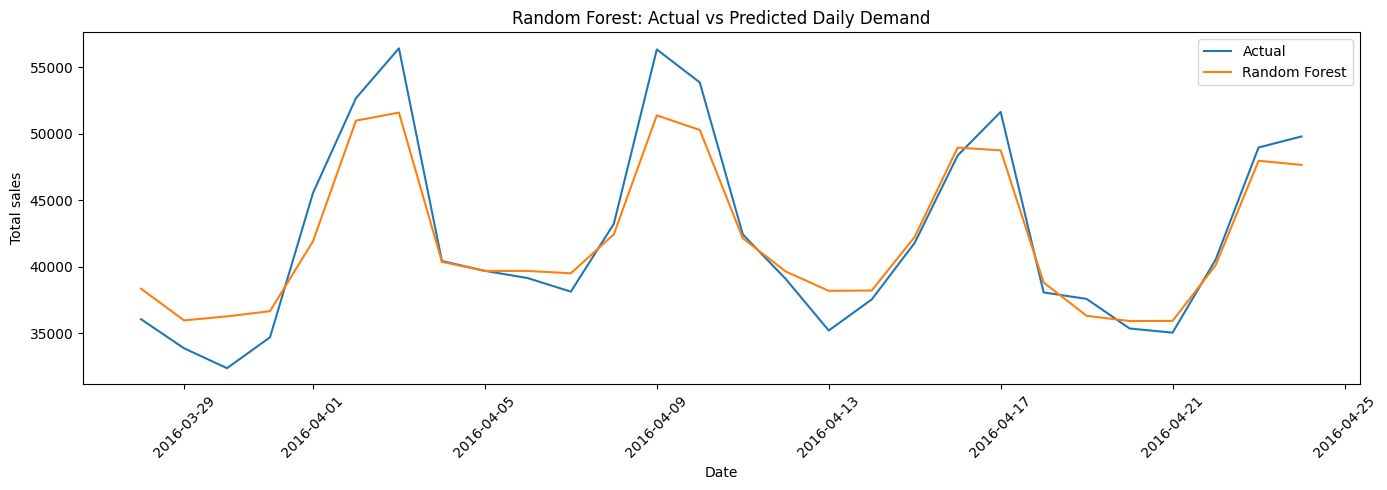

In [74]:
# compare daily random forest predictions with actual demand

daily_rf_results = (
    rf_predictions
    .groupby(
        "date",
        observed=True
    )[
        [
            "sales",
            "prediction"
        ]
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_rf_results["date"],
    daily_rf_results["sales"],
    label="Actual"
)

plt.plot(
    daily_rf_results["date"],
    daily_rf_results["prediction"],
    label="Random Forest"
)

plt.title(
    "Random Forest: Actual vs Predicted Daily Demand"
)

plt.xlabel("Date")
plt.ylabel("Total sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
# identify the best and worst random forest series

rf_by_series = evaluate_forecast_by_series(
    rf_predictions
)

rf_series_analysis = rf_by_series.merge(
    rf_series[
        [
            "store_id",
            "cat_id",
            "rmsse"
        ]
    ],
    on=[
        "store_id",
        "cat_id"
    ],
    how="left"
)

rf_series_analysis = rf_series_analysis.merge(
    revenue_weights[
        [
            "store_id",
            "cat_id",
            "weight"
        ]
    ],
    on=[
        "store_id",
        "cat_id"
    ],
    how="left"
)

best_rf_series = (
    rf_series_analysis
    .nsmallest(5, "rmsse")
    .reset_index(drop=True)
)

worst_rf_series = (
    rf_series_analysis
    .nlargest(5, "rmsse")
    .reset_index(drop=True)
)

print("Five best-performing series")

display(
    best_rf_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}",
        "weight": "{:.2%}"
    })
)

print("Five worst-performing series")

display(
    worst_rf_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}",
        "weight": "{:.2%}"
    })
)

Five best-performing series


,store_id,cat_id,mae,rmse,wape,rmsse,weight
0,CA_1,FOODS,147.34,188.73,4.87%,0.3042,5.87%
1,TX_1,FOODS,127.76,157.32,6.09%,0.3710,4.02%
2,WI_3,FOODS,169.30,219.46,5.87%,0.3899,5.70%
3,WI_1,HOBBIES,40.08,53.52,9.61%,0.4253,1.33%
4,CA_1,HOUSEHOLD,62.95,82.25,6.24%,0.4273,3.18%


Five worst-performing series


,store_id,cat_id,mae,rmse,wape,rmsse,weight
0,WI_2,FOODS,605.82,744.27,15.24%,1.2379,7.60%
1,WI_2,HOUSEHOLD,141.72,218.35,12.55%,1.1704,3.74%
2,CA_4,HOUSEHOLD,55.25,74.14,9.95%,1.0966,1.67%
3,WI_2,HOBBIES,37.45,49.84,12.89%,0.7900,0.91%
4,WI_3,HOBBIES,48.48,58.04,17.29%,0.7843,0.84%


In [78]:
model_results = baseline_results.copy()

model_results = pd.concat(
    [
        model_results,
        rf_results
    ],
    ignore_index=True
)

display(
    model_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Seasonal Naive,186.50,321.00,13.24%,0.9203
1,Random Forest,117.00,200.87,8.30%,0.6006


### Random Forest analysis

The Random Forest model achieved a WAPE of **8.30%** and a WRMSSE of **0.6006** over the independent 28-day test period. This represents a substantial improvement over the Seasonal Naïve benchmark, which produced a WAPE of **13.24%** and a WRMSSE of **0.9203**.

Random Forest reduced MAE from **186.50** to **117.00**, a decrease of approximately **37.3%**. RMSE also declined from **321.00** to **200.87**, representing an improvement of about **37.4%**. The lower RMSE indicates that the model reduced not only the average forecast error but also the impact of larger forecasting mistakes.

The improvement in WRMSSE is particularly important because this metric gives greater weight to high-revenue store-category series. Random Forest reduced WRMSSE by approximately **34.7%**, suggesting that the model performed better than the baseline on the series that contribute most to overall business value.

The model benefited from combining historical demand features with rolling statistics, pricing information, calendar variables, event indicators, and store-category identifiers. Unlike the Seasonal Naïve model, which assumes that demand repeats from the previous week, Random Forest was able to learn nonlinear relationships and interactions among these predictors.

The forecasts were generated recursively, so predictions from earlier forecast dates were used to construct lag and rolling features for later dates. This ensured that no actual demand from the test period was used as a model input.

Overall, Random Forest clearly outperformed the Seasonal Naïve benchmark across all four evaluation metrics. These results show that the additional features and nonlinear modelling approach provided meaningful forecasting improvements for the aggregated M5 store-category demand series.

## 13. XGBoost

XGBoost was evaluated as a second nonlinear machine-learning model. Like Random Forest, it was trained globally across the 30 store-category series and used historical demand, rolling statistics, price information, calendar variables, event indicators, and series identifiers.

A limited parameter search was used to control computational cost. Four candidate configurations were evaluated using the same fixed 28-day validation period used for Random Forest.

Validation and test predictions were generated recursively. After each forecast date, the predicted values were added to the available demand history and used to calculate lag and rolling features for the following date. Therefore, actual future sales were not used as model inputs.

In [79]:
# install xgboost when required

try:
    from xgboost import XGBRegressor
    print("XGBoost is already installed.")
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBRegressor
    print("XGBoost was installed.")

XGBoost is already installed.


In [80]:
# create the xgboost preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

xgb_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

xgb_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            xgb_numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            xgb_categorical_transformer,
            categorical_columns
        )
    ],
    sparse_threshold=1.0
)

In [81]:
# prepare transformed data for xgboost tuning

X_xgb_train = xgb_preprocessor.fit_transform(
    rf_training_df[feature_columns]
)

y_xgb_train = (
    rf_training_df["sales"]
    .astype(float)
    .to_numpy()
)

print("Transformed training shape:", X_xgb_train.shape)
print("Training target shape:", y_xgb_train.shape)

Transformed training shape: (54030, 1919)
Training target shape: (54030,)


In [82]:
# define compact xgboost parameter combinations

from sklearn.model_selection import ParameterGrid

xgb_parameter_grid = {
    "max_depth": [6, 9],
    "learning_rate": [0.05],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_parameter_combinations = list(
    ParameterGrid(xgb_parameter_grid)
)

print(
    "Number of parameter combinations:",
    len(xgb_parameter_combinations)
)

Number of parameter combinations: 4


In [83]:
# generate recursive forecasts with xgboost

def generate_recursive_xgb_forecast(
    fitted_model,
    fitted_preprocessor,
    history_data,
    future_data,
    model_features
):
    history_data = (
        history_data
        .sort_values(
            ["store_id", "cat_id", "date"]
        )
        .copy()
    )

    future_data = (
        future_data
        .sort_values(
            ["date", "store_id", "cat_id"]
        )
        .copy()
    )

    series_histories = {}

    grouped_history = history_data.groupby(
        ["store_id", "cat_id"],
        observed=True
    )

    for series_key, series_data in grouped_history:
        series_histories[series_key] = (
            series_data
            .sort_values("date")["sales"]
            .astype(float)
            .tolist()
        )

    forecast_results = []

    forecast_dates = sorted(
        future_data["date"].unique()
    )

    for forecast_date in forecast_dates:
        current_date_data = (
            future_data[
                future_data["date"] == forecast_date
            ]
            .copy()
        )

        updated_rows = []

        for _, row in current_date_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            dynamic_values = calculate_dynamic_features(
                sales_history=series_histories[series_key],
                model_features=model_features
            )

            updated_row = row.copy()

            for column, value in dynamic_values.items():
                updated_row[column] = value

            updated_rows.append(updated_row)

        current_model_data = pd.DataFrame(
            updated_rows
        )

        transformed_data = fitted_preprocessor.transform(
            current_model_data[model_features]
        )

        current_predictions = fitted_model.predict(
            transformed_data
        )

        current_predictions = np.clip(
            current_predictions,
            0,
            None
        )

        current_model_data["prediction"] = (
            current_predictions
        )

        for _, row in current_model_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            series_histories[series_key].append(
                float(row["prediction"])
            )

        forecast_results.append(
            current_model_data
        )

    return pd.concat(
        forecast_results,
        ignore_index=True
    )

In [84]:
# tune xgboost using recursive validation

import time

xgb_tuning_results = []

xgb_tuning_start = time.time()

for run_number, parameters in enumerate(
    xgb_parameter_combinations,
    start=1
):
    run_start = time.time()

    candidate_xgb_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=350,
        tree_method="hist",
        eval_metric="mae",
        n_jobs=-1,
        random_state=42,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0,
        **parameters
    )

    candidate_xgb_model.fit(
        X_xgb_train,
        y_xgb_train,
        verbose=False
    )

    validation_forecast = (
        generate_recursive_xgb_forecast(
            fitted_model=candidate_xgb_model,
            fitted_preprocessor=xgb_preprocessor,
            history_data=rf_training_df,
            future_data=rf_validation_df,
            model_features=feature_columns
        )
    )

    validation_mae = calculate_mae(
        validation_forecast["sales"],
        validation_forecast["prediction"]
    )

    validation_rmse = calculate_rmse(
        validation_forecast["sales"],
        validation_forecast["prediction"]
    )

    validation_wape = calculate_wape(
        validation_forecast["sales"],
        validation_forecast["prediction"]
    )

    run_minutes = (
        time.time() - run_start
    ) / 60

    xgb_tuning_results.append({
        **parameters,
        "validation_mae": validation_mae,
        "validation_rmse": validation_rmse,
        "validation_wape": validation_wape,
        "runtime_minutes": run_minutes
    })

    print(
        f"Run {run_number}/"
        f"{len(xgb_parameter_combinations)} "
        f"- WAPE: {validation_wape:.2f}% "
        f"- MAE: {validation_mae:.2f} "
        f"- Time: {run_minutes:.2f} minutes"
    )

total_xgb_tuning_minutes = (
    time.time() - xgb_tuning_start
) / 60

print(
    f"Total tuning time: "
    f"{total_xgb_tuning_minutes:.2f} minutes"
)

Run 1/4 - WAPE: 8.79% - MAE: 123.04 - Time: 0.35 minutes
Run 2/4 - WAPE: 8.83% - MAE: 123.60 - Time: 0.25 minutes
Run 3/4 - WAPE: 8.71% - MAE: 121.94 - Time: 0.63 minutes
Run 4/4 - WAPE: 8.74% - MAE: 122.38 - Time: 0.38 minutes
Total tuning time: 1.61 minutes


In [85]:
# review xgboost tuning results

xgb_tuning_results = (
    pd.DataFrame(xgb_tuning_results)
    .sort_values(
        [
            "validation_wape",
            "validation_mae"
        ]
    )
    .reset_index(drop=True)
)

display(
    xgb_tuning_results.style.format({
        "learning_rate": "{:.2f}",
        "subsample": "{:.2f}",
        "colsample_bytree": "{:.2f}",
        "validation_mae": "{:.2f}",
        "validation_rmse": "{:.2f}",
        "validation_wape": "{:.2f}%",
        "runtime_minutes": "{:.2f}"
    })
)

,colsample_bytree,learning_rate,max_depth,min_child_weight,subsample,validation_mae,validation_rmse,validation_wape,runtime_minutes
0,0.80,0.05,9,1,0.80,121.94,212.90,8.71%,0.63
1,0.80,0.05,9,5,0.80,122.38,211.57,8.74%,0.38
2,0.80,0.05,6,1,0.80,123.04,214.20,8.79%,0.35
3,0.80,0.05,6,5,0.80,123.60,217.31,8.83%,0.25


In [86]:
# select the best xgboost parameters

xgb_parameter_names = [
    "max_depth",
    "learning_rate",
    "min_child_weight",
    "subsample",
    "colsample_bytree"
]

best_xgb_parameters = (
    xgb_tuning_results
    .loc[0, xgb_parameter_names]
    .to_dict()
)

best_xgb_parameters["max_depth"] = int(
    best_xgb_parameters["max_depth"]
)

best_xgb_parameters["min_child_weight"] = int(
    best_xgb_parameters["min_child_weight"]
)

print("Best XGBoost parameters:")
print(best_xgb_parameters)

print(
    "Best validation WAPE:",
    f"{xgb_tuning_results.loc[0, 'validation_wape']:.2f}%"
)

Best XGBoost parameters:
{'max_depth': 9, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best validation WAPE: 8.71%


In [87]:
# transform the complete training dataset

final_xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median")
                    )
                ]
            ),
            numeric_columns
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=True
                        )
                    )
                ]
            ),
            categorical_columns
        )
    ],
    sparse_threshold=1.0
)

X_xgb_full_train = (
    final_xgb_preprocessor.fit_transform(
        train_df[feature_columns]
    )
)

y_xgb_full_train = (
    train_df["sales"]
    .astype(float)
    .to_numpy()
)

print(
    "Final transformed training shape:",
    X_xgb_full_train.shape
)

Final transformed training shape: (54870, 1947)


In [89]:
# train the final xgboost model

final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=350,
    tree_method="hist",
    eval_metric="mae",
    n_jobs=-1,
    random_state=42,
    reg_alpha=0.1,
    reg_lambda=1.0,
    verbosity=0,
    **best_xgb_parameters
)

final_xgb_model.fit(
    X_xgb_full_train,
    y_xgb_full_train,
    verbose=False
)

print("Final XGBoost model trained.")

Final XGBoost model trained.


In [90]:
# generate the 28-day xgboost test forecast

xgb_predictions = (
    generate_recursive_xgb_forecast(
        fitted_model=final_xgb_model,
        fitted_preprocessor=final_xgb_preprocessor,
        history_data=train_df,
        future_data=test_df,
        model_features=feature_columns
    )
)

print("Forecast rows:", len(xgb_predictions))
print(
    "Forecast dates:",
    xgb_predictions["date"].nunique()
)

display(
    xgb_predictions[
        [
            "date",
            "store_id",
            "cat_id",
            "sales",
            "prediction"
        ]
    ].head()
)

Forecast rows: 840
Forecast dates: 28


,date,store_id,cat_id,sales,prediction
0,2016-03-28,CA_1,HOBBIES,535,420.212189
1,2016-03-28,CA_1,HOUSEHOLD,890,881.730286
2,2016-03-28,CA_1,FOODS,2480,2707.522949
3,2016-03-28,CA_2,HOBBIES,366,329.375061
4,2016-03-28,CA_2,HOUSEHOLD,903,910.382751


In [91]:
# evaluate the xgboost forecast

xgb_metrics, xgb_series = evaluate_forecast(
    model_name="XGBoost",
    evaluation_data=xgb_predictions
)

xgb_results = pd.DataFrame(
    [xgb_metrics]
)

display(
    xgb_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,XGBoost,111.36,173.17,7.90%,0.5434


In [92]:
# compare xgboost with previous models

xgb_comparison = pd.concat(
    [
        baseline_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)

display(
    xgb_comparison.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Seasonal Naive,186.50,321.00,13.24%,0.9203
1,Random Forest,117.00,200.87,8.30%,0.6006
2,XGBoost,111.36,173.17,7.90%,0.5434


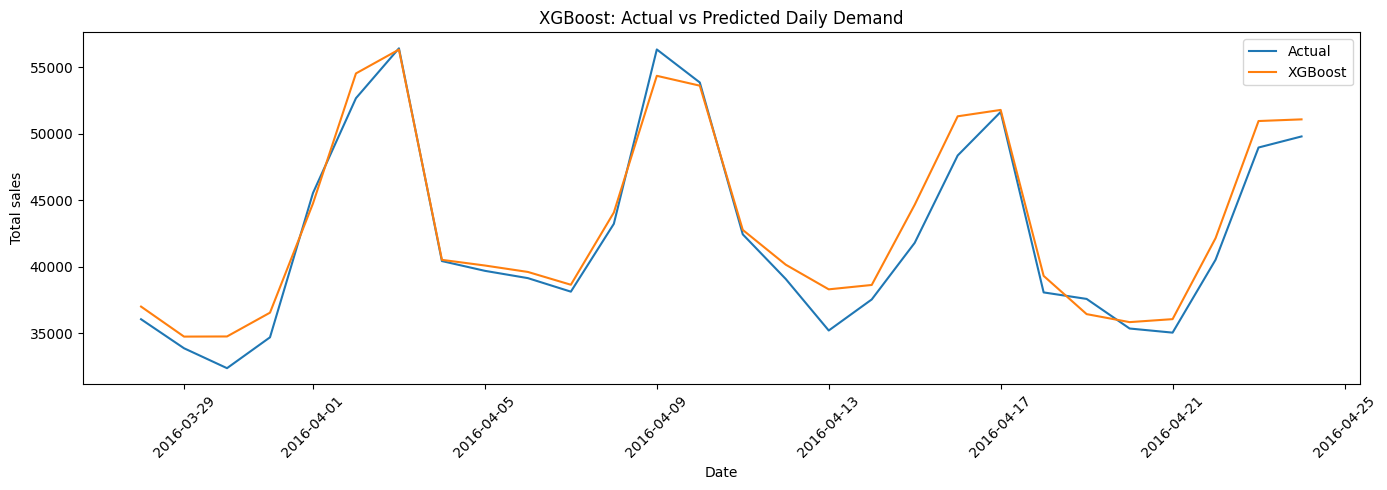

In [93]:
# compare daily xgboost forecasts with actual demand

daily_xgb_results = (
    xgb_predictions
    .groupby(
        "date",
        observed=True
    )[
        [
            "sales",
            "prediction"
        ]
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_xgb_results["date"],
    daily_xgb_results["sales"],
    label="Actual"
)

plt.plot(
    daily_xgb_results["date"],
    daily_xgb_results["prediction"],
    label="XGBoost"
)

plt.title(
    "XGBoost: Actual vs Predicted Daily Demand"
)

plt.xlabel("Date")
plt.ylabel("Total sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
# calculate xgboost performance by series

xgb_by_series = evaluate_forecast_by_series(
    xgb_predictions
)

xgb_series_analysis = xgb_by_series.merge(
    xgb_series[
        [
            "store_id",
            "cat_id",
            "rmsse"
        ]
    ],
    on=[
        "store_id",
        "cat_id"
    ],
    how="left"
)

xgb_series_analysis = xgb_series_analysis.merge(
    revenue_weights[
        [
            "store_id",
            "cat_id",
            "weight"
        ]
    ],
    on=[
        "store_id",
        "cat_id"
    ],
    how="left"
)

best_xgb_series = (
    xgb_series_analysis
    .nsmallest(5, "rmsse")
    .reset_index(drop=True)
)

worst_xgb_series = (
    xgb_series_analysis
    .nlargest(5, "rmsse")
    .reset_index(drop=True)
)

In [95]:
# display strongest and weakest xgboost series

print("Five best-performing series")

display(
    best_xgb_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}",
        "weight": "{:.2%}"
    })
)

print("Five worst-performing series")

display(
    worst_xgb_series.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "rmsse": "{:.4f}",
        "weight": "{:.2%}"
    })
)

Five best-performing series


,store_id,cat_id,mae,rmse,wape,rmsse,weight
0,CA_1,FOODS,159.72,200.44,5.28%,0.3230,5.87%
1,WI_3,FOODS,159.08,200.06,5.52%,0.3554,5.70%
2,CA_1,HOUSEHOLD,50.09,68.77,4.97%,0.3572,3.18%
3,CA_3,HOUSEHOLD,84.56,105.42,4.75%,0.3857,5.67%
4,TX_1,FOODS,145.86,175.34,6.95%,0.4135,4.02%


Five worst-performing series


,store_id,cat_id,mae,rmse,wape,rmsse,weight
0,WI_2,HOUSEHOLD,128.20,179.95,11.35%,0.9645,3.74%
1,CA_4,HOUSEHOLD,45.99,62.45,8.28%,0.9237,1.67%
2,CA_4,HOBBIES,57.44,67.01,15.59%,0.8498,1.19%
3,WI_2,FOODS,353.00,440.74,8.88%,0.7331,7.60%
4,TX_2,FOODS,356.56,394.26,13.90%,0.7145,5.36%


In [96]:
# add xgboost to the model results table

model_results = (
    model_results[
        model_results["model"] != "XGBoost"
    ]
    .copy()
)

model_results = pd.concat(
    [
        model_results,
        xgb_results
    ],
    ignore_index=True
)

display(
    model_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Seasonal Naive,186.50,321.00,13.24%,0.9203
1,Random Forest,117.00,200.87,8.30%,0.6006
2,XGBoost,111.36,173.17,7.90%,0.5434


### XGBoost analysis

The XGBoost model achieved a WAPE of **7.90%** and a WRMSSE of **0.5434** on the independent 28-day test period, making it the best-performing model evaluated so far. Compared with the Seasonal Naïve benchmark, XGBoost substantially improved forecasting accuracy across all evaluation metrics.

Relative to the Seasonal Naïve model, MAE decreased from **186.50** to **111.36**, representing an improvement of approximately **40.3%**. RMSE decreased from **321.00** to **173.17**, a reduction of approximately **46.1%**, indicating that the model was particularly effective at reducing large forecasting errors.

The improvement in WRMSSE from **0.9203** to **0.5434** corresponds to an improvement of approximately **41.0%**. Since WRMSSE assigns greater importance to high-revenue store-category series, this result suggests that XGBoost generated more accurate forecasts for the series with the greatest business impact.

Compared with Random Forest, XGBoost also achieved consistent improvements. MAE decreased from **117.00** to **111.36** (4.8%), RMSE decreased from **200.87** to **173.17** (13.8%), WAPE improved from **8.30%** to **7.90%**, and WRMSSE improved from **0.6006** to **0.5434**. These results indicate that the boosting approach captured complex nonlinear relationships more effectively than the bagging approach used by Random Forest.

The model was trained using lagged demand, rolling statistics, pricing variables, calendar features, event indicators, and store-category identifiers. Forecasts were generated recursively, ensuring that predicted values from earlier forecast dates were used to construct lag and rolling features for subsequent dates. This prevented any information leakage from the test period.

Overall, XGBoost produced the strongest forecasting performance among the machine learning models evaluated so far. The results demonstrate that gradient boosting is well suited for retail demand forecasting problems where demand depends on complex interactions among historical sales, pricing, seasonality, and special events.

## 14. Deep Neural Network

A feedforward Deep Neural Network was evaluated to determine whether a nonlinear neural architecture could improve demand forecasting performance beyond the tree-based models.

The DNN receives the same historical demand, rolling, price, calendar, event, store, and category features used by Random Forest and XGBoost. Numeric variables are standardized because neural networks train more effectively when input features have comparable scales. Categorical variables are represented using one-hot encoding.

A compact architecture was selected to control runtime and reduce overfitting. Early stopping was used to stop training when validation performance no longer improved, while a learning-rate scheduler reduced the learning rate when progress slowed.

The final 28-day test forecast is generated recursively. Predictions for each day are added to the demand history and used to calculate lag and rolling features for subsequent forecast dates. This prevents actual test-period demand from entering the model inputs.

In [97]:
# import tensorflow and set reproducible random seeds

import os
import random
import time
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# set seeds for Python, NumPy, and TensorFlow
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# reduce unnecessary TensorFlow logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [98]:
# create a chronological split for early stopping

dnn_validation_horizon = 28

dnn_available_dates = np.sort(
    train_df["date"].unique()
)

dnn_validation_dates = dnn_available_dates[
    -dnn_validation_horizon:
]

dnn_training_df = (
    train_df[
        ~train_df["date"].isin(dnn_validation_dates)
    ]
    .copy()
)

dnn_validation_df = (
    train_df[
        train_df["date"].isin(dnn_validation_dates)
    ]
    .copy()
)

# sort the data to preserve chronological order within each series
dnn_training_df = dnn_training_df.sort_values(
    ["date", "store_id", "cat_id"]
).reset_index(drop=True)

dnn_validation_df = dnn_validation_df.sort_values(
    ["date", "store_id", "cat_id"]
).reset_index(drop=True)

print(
    "DNN training period:",
    dnn_training_df["date"].min().date(),
    "to",
    dnn_training_df["date"].max().date()
)

print(
    "Early-stopping validation period:",
    dnn_validation_df["date"].min().date(),
    "to",
    dnn_validation_df["date"].max().date()
)

print("Training rows:", len(dnn_training_df))
print("Validation rows:", len(dnn_validation_df))

DNN training period: 2011-03-26 to 2016-02-28
Early-stopping validation period: 2016-02-29 to 2016-03-27
Training rows: 54030
Validation rows: 840


Create the DNN preprocessing pipeline

Neural networks are sensitive to differences in feature scale. We therefore:

impute missing numeric values;
standardize numeric variables;
impute and one-hot encode categorical variables;
return a dense matrix suitable for TensorFlow

In [99]:
# create preprocessing for the neural network

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

dnn_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

dnn_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

dnn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            dnn_numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            dnn_categorical_transformer,
            categorical_columns
        )
    ],
    sparse_threshold=0
)

print("Numeric features:", len(numeric_columns))
print("Categorical features:", categorical_columns)

Numeric features: 51
Categorical features: ['store_id', 'state_id', 'cat_id', 'd', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']


The preprocessor is fitted only on the DNN training portion. This prevents information from the early-stopping validation period from influencing scaling and imputation values.

In [100]:
# transform the dnn training and validation datasets

X_dnn_train = dnn_preprocessor.fit_transform(
    dnn_training_df[feature_columns]
)

X_dnn_valid = dnn_preprocessor.transform(
    dnn_validation_df[feature_columns]
)

y_dnn_train = (
    dnn_training_df["sales"]
    .astype("float32")
    .to_numpy()
)

y_dnn_valid = (
    dnn_validation_df["sales"]
    .astype("float32")
    .to_numpy()
)

# TensorFlow trains more efficiently with float32 arrays
X_dnn_train = X_dnn_train.astype("float32")
X_dnn_valid = X_dnn_valid.astype("float32")

print("Training feature shape:", X_dnn_train.shape)
print("Validation feature shape:", X_dnn_valid.shape)
print("Training target shape:", y_dnn_train.shape)

Training feature shape: (54030, 1919)
Validation feature shape: (840, 1919)
Training target shape: (54030,)


Define the compact DNN architecture

The architecture uses:

128 neurons in the first layer to learn broad nonlinear relationships;
64 neurons in the second layer to create a more compact representation;
batch normalization to stabilize training;
dropout to reduce overfitting;
a single linear output for sales prediction.

A larger architecture would increase runtime and overfitting risk without necessarily improving forecasts on this aggregated dataset.

In [101]:
# define a compact feedforward neural network

def build_dnn_model(number_of_features):
    model = Sequential([
        # input layer and first nonlinear representation
        Dense(
            128,
            activation="relu",
            input_shape=(number_of_features,)
        ),

        # stabilize the distribution of intermediate activations
        BatchNormalization(),

        # reduce dependence on individual neurons
        Dropout(0.20),

        # second hidden layer for more compact nonlinear patterns
        Dense(
            64,
            activation="relu"
        ),

        BatchNormalization(),
        Dropout(0.15),

        # regression output; no activation keeps predictions continuous
        Dense(
            1,
            activation="linear"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


dnn_model = build_dnn_model(
    number_of_features=X_dnn_train.shape[1]
)

dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       245,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 254,849 (995.50 KB)

 Trainable params: 254,465 (994.00 KB)

 Non-trainable params: 384 (1.50 KB)

Define runtime-control callbacks

EarlyStopping prevents unnecessary epochs when validation loss stops improving.

ReduceLROnPlateau lowers the learning rate when progress slows, allowing the network to make smaller parameter updates near a useful solution.

In [102]:
# define callbacks to control runtime and overfitting

dnn_early_stopping = EarlyStopping(
    monitor="val_loss",

    # stop when validation loss has not improved for eight epochs
    patience=8,

    # return to the weights from the best validation epoch
    restore_best_weights=True,

    # small changes below this value are not treated as improvements
    min_delta=0.001,

    verbose=1
)

dnn_learning_rate_scheduler = ReduceLROnPlateau(
    monitor="val_loss",

    # reduce the learning rate by half when progress slows
    factor=0.5,

    # adjust the learning rate before early stopping is reached
    patience=4,

    # avoid reducing the learning rate indefinitely
    min_lr=0.00001,

    verbose=1
)

In [103]:
# train the dnn with early stopping

dnn_training_start = time.time()

dnn_history = dnn_model.fit(
    X_dnn_train,
    y_dnn_train,

    # validation is used only to control training duration
    validation_data=(
        X_dnn_valid,
        y_dnn_valid
    ),

    epochs=60,
    batch_size=256,

    callbacks=[
        dnn_early_stopping,
        dnn_learning_rate_scheduler
    ],

    # preserve chronological row order
    shuffle=False,

    verbose=1
)

dnn_training_minutes = (
    time.time() - dnn_training_start
) / 60

print(
    f"DNN training time: "
    f"{dnn_training_minutes:.2f} minutes"
)

Epoch 1/60
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 2372448.7500 - mae: 1143.0771 - val_loss: 3281403.7500 - val_mae: 1393.6067 - learning_rate: 0.0010
Epoch 2/60
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2287483.0000 - mae: 1131.1301 - val_loss: 3219512.0000 - val_mae: 1407.4824 - learning_rate: 0.0010
Epoch 3/60
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2154982.5000 - mae: 1107.7053 - val_loss: 2944023.5000 - val_mae: 1351.9355 - learning_rate: 0.0010
Epoch 4/60
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1983442.5000 - mae: 1072.8845 - val_loss: 2712662.7500 - val_mae: 1302.1986 - learning_rate: 0.0010
Epoch 5/60
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1782202.2500 - mae: 1027.5760 - val_loss: 2281809.0000 - val_mae: 1191.4010 - learning_rate: 0.0010
Epoch 6/60
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1564011.5000 - mae: 973.2783 - val_loss: 1992694.1250 - val_mae: 1121.3479 - learning_rate: 0.0010
Epoch 7/60
212/212 ━━━━━━━━━━━━━━━━━━━━

In [104]:
# summarize the neural network training history

dnn_history_df = pd.DataFrame(
    dnn_history.history
)

dnn_history_df["epoch"] = (
    np.arange(len(dnn_history_df)) + 1
)

best_dnn_epoch = int(
    dnn_history_df.loc[
        dnn_history_df["val_loss"].idxmin(),
        "epoch"
    ]
)

best_dnn_validation_loss = (
    dnn_history_df["val_loss"].min()
)

best_dnn_validation_mae = (
    dnn_history_df.loc[
        dnn_history_df["val_loss"].idxmin(),
        "val_mae"
    ]
)

print("Epochs completed:", len(dnn_history_df))
print("Best epoch:", best_dnn_epoch)
print(
    "Best validation MSE:",
    round(best_dnn_validation_loss, 2)
)
print(
    "Best validation MAE:",
    round(best_dnn_validation_mae, 2)
)

Epochs completed: 40
Best epoch: 32
Best validation MSE: 48754.14
Best validation MAE: 137.9


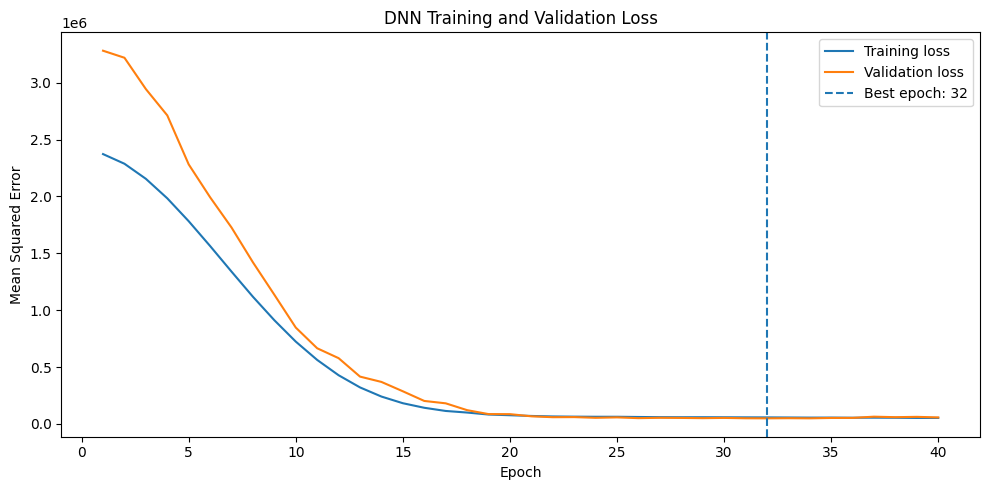

In [105]:
# plot dnn training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(
    dnn_history_df["epoch"],
    dnn_history_df["loss"],
    label="Training loss"
)

plt.plot(
    dnn_history_df["epoch"],
    dnn_history_df["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_dnn_epoch,
    linestyle="--",
    label=f"Best epoch: {best_dnn_epoch}"
)

plt.title("DNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
# fit the final dnn preprocessing pipeline

final_dnn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median")
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            numeric_columns
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            categorical_columns
        )
    ],
    sparse_threshold=0
)

X_dnn_full_train = (
    final_dnn_preprocessor.fit_transform(
        train_df[feature_columns]
    )
    .astype("float32")
)

y_dnn_full_train = (
    train_df["sales"]
    .astype("float32")
    .to_numpy()
)

print(
    "Final DNN training shape:",
    X_dnn_full_train.shape
)

Final DNN training shape: (54870, 1947)


In [107]:
# retrain the final dnn on the complete training period

tf.keras.backend.clear_session()
tf.random.set_seed(42)

final_dnn_model = build_dnn_model(
    number_of_features=X_dnn_full_train.shape[1]
)

final_dnn_start = time.time()

final_dnn_model.fit(
    X_dnn_full_train,
    y_dnn_full_train,

    # use the best training duration found earlier
    epochs=best_dnn_epoch,

    batch_size=256,
    shuffle=False,
    verbose=1
)

final_dnn_minutes = (
    time.time() - final_dnn_start
) / 60

print(
    f"Final DNN training time: "
    f"{final_dnn_minutes:.2f} minutes"
)

print(
    f"Combined DNN training time: "
    f"{dnn_training_minutes + final_dnn_minutes:.2f} minutes"
)

Epoch 1/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 2418998.5000 - mae: 1147.9575
Epoch 2/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2392825.5000 - mae: 1140.3914
Epoch 3/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2348039.5000 - mae: 1125.4861
Epoch 4/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2287178.0000 - mae: 1103.6553
Epoch 5/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2213424.0000 - mae: 1075.4830
Epoch 6/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2130852.7500 - mae: 1041.8888
Epoch 7/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2041573.1250 - mae: 1003.9941
Epoch 8/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1949162.7500 - mae: 964.0734
Epoch 9/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1856011.7500 - mae: 924.6279
Epoch 10/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1763298.5000 - mae: 887.7991
Epoch 11/32
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1674978.7500 - mae: 855.3597
Epoch 12/32

Create the recursive DNN forecasting function

This uses the same leakage-free logic as Random Forest and XGBoost:

Forecast one date.
Add predictions to each series history.
Recalculate lag and rolling features.
Forecast the next date.

In [108]:
# generate recursive forecasts with the dnn

def generate_recursive_dnn_forecast(
    fitted_model,
    fitted_preprocessor,
    history_data,
    future_data,
    model_features
):
    # organize historical observations by store-category series
    history_data = (
        history_data
        .sort_values(
            ["store_id", "cat_id", "date"]
        )
        .copy()
    )

    # dates must be forecast in chronological order
    future_data = (
        future_data
        .sort_values(
            ["date", "store_id", "cat_id"]
        )
        .copy()
    )

    series_histories = {}

    for series_key, series_data in history_data.groupby(
        ["store_id", "cat_id"],
        observed=True
    ):
        # store each series as a list that can be updated after prediction
        series_histories[series_key] = (
            series_data
            .sort_values("date")["sales"]
            .astype(float)
            .tolist()
        )

    forecast_batches = []

    forecast_dates = sorted(
        future_data["date"].unique()
    )

    for forecast_date in forecast_dates:
        # prepare all 30 series for the current forecast date
        current_date_data = (
            future_data[
                future_data["date"] == forecast_date
            ]
            .copy()
        )

        updated_rows = []

        for _, row in current_date_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            # calculate demand-based features using only available history
            dynamic_values = calculate_dynamic_features(
                sales_history=series_histories[series_key],
                model_features=model_features
            )

            updated_row = row.copy()

            # overwrite any precomputed future lag or rolling values
            for column, value in dynamic_values.items():
                updated_row[column] = value

            updated_rows.append(updated_row)

        current_model_data = pd.DataFrame(
            updated_rows
        )

        # apply the scaler and categorical encoding fitted on training data
        transformed_current_data = (
            fitted_preprocessor.transform(
                current_model_data[model_features]
            )
            .astype("float32")
        )

        # predict all store-category series for the current date
        current_predictions = (
            fitted_model.predict(
                transformed_current_data,
                verbose=0
            )
            .reshape(-1)
        )

        # retail demand cannot be negative
        current_predictions = np.clip(
            current_predictions,
            0,
            None
        )

        current_model_data["prediction"] = (
            current_predictions
        )

        # append predictions so they become available for future lags
        for _, row in current_model_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            series_histories[series_key].append(
                float(row["prediction"])
            )

        forecast_batches.append(
            current_model_data
        )

    return pd.concat(
        forecast_batches,
        ignore_index=True
    )

In [109]:
# generate the recursive dnn test forecast

dnn_forecast_start = time.time()

dnn_predictions = (
    generate_recursive_dnn_forecast(
        fitted_model=final_dnn_model,
        fitted_preprocessor=final_dnn_preprocessor,
        history_data=train_df,
        future_data=test_df,
        model_features=feature_columns
    )
)

dnn_forecast_seconds = (
    time.time() - dnn_forecast_start
)

print("Forecast rows:", len(dnn_predictions))
print(
    "Forecast dates:",
    dnn_predictions["date"].nunique()
)

print(
    f"Recursive forecast time: "
    f"{dnn_forecast_seconds:.2f} seconds"
)

display(
    dnn_predictions[
        [
            "date",
            "store_id",
            "cat_id",
            "sales",
            "prediction"
        ]
    ].head()
)

Forecast rows: 840
Forecast dates: 28
Recursive forecast time: 9.02 seconds


,date,store_id,cat_id,sales,prediction
0,2016-03-28,CA_1,HOBBIES,535,159.728561
1,2016-03-28,CA_1,HOUSEHOLD,890,782.861267
2,2016-03-28,CA_1,FOODS,2480,2413.168213
3,2016-03-28,CA_2,HOBBIES,366,229.428268
4,2016-03-28,CA_2,HOUSEHOLD,903,955.724792


In [110]:
# validate the dnn prediction output

prediction_quality_check = pd.Series({
    "missing_predictions": (
        dnn_predictions["prediction"].isna().sum()
    ),
    "infinite_predictions": (
        np.isinf(
            dnn_predictions["prediction"]
        ).sum()
    ),
    "negative_predictions": (
        dnn_predictions["prediction"] < 0
    ).sum(),
    "minimum_prediction": (
        dnn_predictions["prediction"].min()
    ),
    "maximum_prediction": (
        dnn_predictions["prediction"].max()
    ),
    "average_prediction": (
        dnn_predictions["prediction"].mean()
    )
})

display(
    prediction_quality_check.to_frame(
        name="value"
    )
)

,value
missing_predictions,0.000000
infinite_predictions,0.000000
negative_predictions,0.000000
minimum_prediction,0.000000
maximum_prediction,3419.775635
average_prediction,1167.568848


In [111]:
# evaluate the dnn forecast

dnn_metrics, dnn_series = evaluate_forecast(
    model_name="DNN",
    evaluation_data=dnn_predictions
)

dnn_results = pd.DataFrame(
    [dnn_metrics]
)

display(
    dnn_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,DNN,341.37,554.69,24.23%,1.5681


In [112]:
# compare the dnn with the existing models

dnn_comparison = pd.concat(
    [
        baseline_results,
        rf_results,
        xgb_results,
        dnn_results
    ],
    ignore_index=True
)

display(
    dnn_comparison.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Seasonal Naive,186.50,321.00,13.24%,0.9203
1,Random Forest,117.00,200.87,8.30%,0.6006
2,XGBoost,111.36,173.17,7.90%,0.5434
3,DNN,341.37,554.69,24.23%,1.5681


### DNN analysis

The Deep Neural Network achieved a WAPE of **24.23%** and a WRMSSE of **1.5681** on the independent 28-day test period. This was substantially worse than the Seasonal Naïve, Random Forest, and XGBoost models.

The DNN produced an MAE of **341.37** and an RMSE of **554.69**. The relatively high RMSE indicates that the model generated several large forecast errors in addition to having a high average error.

Compared with the best-performing XGBoost model, the DNN increased MAE from **111.36** to **341.37**, RMSE from **173.17** to **554.69**, WAPE from **7.90%** to **24.23%**, and WRMSSE from **0.5434** to **1.5681**. The DNN also underperformed the Seasonal Naïve benchmark, which achieved a WAPE of **13.24%** and a WRMSSE of **0.9203**.

Several factors may explain this weaker performance. The available dataset contains only 30 aggregated store-category series, which may not provide enough diverse training examples for a neural network to learn stable forecasting relationships. In contrast, tree-based models are often more effective on structured tabular datasets containing engineered lag, rolling, price, calendar, and categorical features.

The recursive forecasting procedure may also have amplified the DNN's errors. Predictions from earlier forecast dates were used to construct lag and rolling features for later dates. Therefore, inaccurate early predictions could propagate through the remainder of the 28-day forecast horizon.

In addition, the DNN optimized mean squared error during training rather than WRMSSE, the primary business-oriented evaluation metric. As a result, the model was not directly trained to account for differences in scale and revenue importance across store-category series.

Overall, the DNN did not provide an improvement over either the baseline or the tree-based models. The result demonstrates that increased model complexity does not necessarily lead to better forecasting performance, particularly when the data are structured, the number of aggregated series is limited, and strong demand features have already been engineered.

### 14.1 Improved DNN using residual learning

The initial DNN produced reasonable one-step validation performance but performed poorly during the recursive 28-day test forecast. This suggests that its prediction errors accumulated as forecast values were reused to construct future lag and rolling features.

To reduce recursive instability, a residual-learning approach was introduced. Instead of predicting total demand directly, the revised DNN predicts the difference between actual demand and the seven-day seasonal lag:

\[
Residual_t = Sales_t - Lag7_t
\]

The final demand forecast is obtained by adding the predicted residual to the seven-day lag:

\[
\widehat{Sales}_t = Lag7_t + \widehat{Residual}_t
\]

This design anchors each prediction to a strong weekly seasonal reference while allowing the neural network to learn adjustments related to recent demand, prices, calendar variables, events, stores, and categories.

The residual target is standardized to improve numerical stability. Huber loss is used because it behaves similarly to squared error for small mistakes but is less sensitive to extreme observations than mean squared error. A compact network is retained to limit runtime and reduce overfitting.

In [113]:
# inspect the weekly residual target

required_residual_columns = [
    "sales",
    "lag_7"
]

missing_residual_columns = [
    column
    for column in required_residual_columns
    if column not in train_df.columns
]

if missing_residual_columns:
    raise ValueError(
        f"Missing required columns: {missing_residual_columns}"
    )

residual_check_df = train_df[
    ["sales", "lag_7"]
].dropna().copy()

residual_check_df["weekly_residual"] = (
    residual_check_df["sales"]
    - residual_check_df["lag_7"]
)

residual_summary = pd.DataFrame({
    "target": [
        "sales",
        "weekly_residual"
    ],
    "mean": [
        residual_check_df["sales"].mean(),
        residual_check_df["weekly_residual"].mean()
    ],
    "standard_deviation": [
        residual_check_df["sales"].std(),
        residual_check_df["weekly_residual"].std()
    ],
    "median_absolute_value": [
        residual_check_df["sales"].abs().median(),
        residual_check_df["weekly_residual"].abs().median()
    ]
})

display(
    residual_summary.style.format({
        "mean": "{:.2f}",
        "standard_deviation": "{:.2f}",
        "median_absolute_value": "{:.2f}"
    })
)

,target,mean,standard_deviation,median_absolute_value
0,sales,1149.53,1051.90,706.00
1,weekly_residual,2.23,306.18,82.00


In [114]:
# prepare residual dnn training and validation data

residual_dnn_training_df = (
    dnn_training_df[
        dnn_training_df["lag_7"].notna()
    ]
    .copy()
)

residual_dnn_validation_df = (
    dnn_validation_df[
        dnn_validation_df["lag_7"].notna()
    ]
    .copy()
)

# calculate the residual relative to the weekly seasonal baseline
residual_dnn_training_df["residual_target"] = (
    residual_dnn_training_df["sales"]
    - residual_dnn_training_df["lag_7"]
)

residual_dnn_validation_df["residual_target"] = (
    residual_dnn_validation_df["sales"]
    - residual_dnn_validation_df["lag_7"]
)

# retain chronological order throughout model training
residual_dnn_training_df = (
    residual_dnn_training_df
    .sort_values(
        ["date", "store_id", "cat_id"]
    )
    .reset_index(drop=True)
)

residual_dnn_validation_df = (
    residual_dnn_validation_df
    .sort_values(
        ["date", "store_id", "cat_id"]
    )
    .reset_index(drop=True)
)

print(
    "Residual training period:",
    residual_dnn_training_df["date"].min().date(),
    "to",
    residual_dnn_training_df["date"].max().date()
)

print(
    "Residual validation period:",
    residual_dnn_validation_df["date"].min().date(),
    "to",
    residual_dnn_validation_df["date"].max().date()
)

print(
    "Residual training rows:",
    len(residual_dnn_training_df)
)

print(
    "Residual validation rows:",
    len(residual_dnn_validation_df)
)

Residual training period: 2011-03-26 to 2016-02-28
Residual validation period: 2016-02-29 to 2016-03-27
Residual training rows: 54030
Residual validation rows: 840


In [115]:
# create preprocessing for the residual dnn

residual_dnn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            numeric_columns
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            categorical_columns
        )
    ],
    sparse_threshold=0
)

X_residual_dnn_train = (
    residual_dnn_preprocessor.fit_transform(
        residual_dnn_training_df[
            feature_columns
        ]
    )
    .astype("float32")
)

X_residual_dnn_valid = (
    residual_dnn_preprocessor.transform(
        residual_dnn_validation_df[
            feature_columns
        ]
    )
    .astype("float32")
)

print(
    "Training feature shape:",
    X_residual_dnn_train.shape
)

print(
    "Validation feature shape:",
    X_residual_dnn_valid.shape
)

Training feature shape: (54030, 1919)
Validation feature shape: (840, 1919)


In [116]:
# standardize the residual prediction target

from sklearn.preprocessing import StandardScaler

residual_target_scaler = StandardScaler()

y_residual_dnn_train = (
    residual_target_scaler
    .fit_transform(
        residual_dnn_training_df[
            ["residual_target"]
        ]
    )
    .astype("float32")
    .reshape(-1)
)

y_residual_dnn_valid = (
    residual_target_scaler
    .transform(
        residual_dnn_validation_df[
            ["residual_target"]
        ]
    )
    .astype("float32")
    .reshape(-1)
)

print(
    "Scaled training residual mean:",
    round(
        float(y_residual_dnn_train.mean()),
        4
    )
)

print(
    "Scaled training residual standard deviation:",
    round(
        float(y_residual_dnn_train.std()),
        4
    )
)

Scaled training residual mean: 0.0
Scaled training residual standard deviation: 1.0


Define the improved architecture

This version is deliberately smaller than the original DNN:

64 neurons in the first hidden layer;
32 neurons in the second hidden layer;
low dropout;
no batch normalization;
Huber loss.

Batch normalization is removed because it can behave less consistently when demand series have very different distributions. Standardized inputs and targets already provide controlled feature scales.

In [117]:
# define a compact residual neural network

from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import Input

def build_residual_dnn(number_of_features):
    model = Sequential([
        # define the model input explicitly
        Input(
            shape=(number_of_features,)
        ),

        # learn broad nonlinear relationships across demand features
        Dense(
            64,
            activation="relu"
        ),

        # use light regularization without removing too much information
        Dropout(0.10),

        # create a smaller representation of the learned relationships
        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.05),

        # predict the standardized correction to lag_7
        Dense(
            1,
            activation="linear"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),

        # Huber loss reduces the influence of extreme residuals
        loss=Huber(
            delta=1.0
        ),

        metrics=["mae"]
    )

    return model


tf.keras.backend.clear_session()
tf.random.set_seed(42)

residual_dnn_model = build_residual_dnn(
    number_of_features=(
        X_residual_dnn_train.shape[1]
    )
)

residual_dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       122,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,993 (488.25 KB)

 Trainable params: 124,993 (488.25 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
# control residual dnn training and overfitting

residual_dnn_early_stopping = EarlyStopping(
    monitor="val_loss",

    # allow enough time for residual learning to stabilize
    patience=10,

    # restore the model from the strongest validation epoch
    restore_best_weights=True,

    min_delta=0.0001,
    verbose=1
)

residual_dnn_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",

    # make smaller parameter updates when validation progress slows
    factor=0.5,

    patience=5,
    min_lr=0.00001,
    verbose=1
)

In [119]:
# train the residual dnn

residual_dnn_training_start = time.time()

residual_dnn_history = residual_dnn_model.fit(
    X_residual_dnn_train,
    y_residual_dnn_train,

    validation_data=(
        X_residual_dnn_valid,
        y_residual_dnn_valid
    ),

    # early stopping will normally end training before this limit
    epochs=80,

    # a moderate batch size provides stable and efficient training
    batch_size=256,

    # preserve chronological order rather than randomly mixing dates
    shuffle=False,

    callbacks=[
        residual_dnn_early_stopping,
        residual_dnn_lr_scheduler
    ],

    verbose=1
)

residual_dnn_training_minutes = (
    time.time()
    - residual_dnn_training_start
) / 60

print(
    f"Residual DNN training time: "
    f"{residual_dnn_training_minutes:.2f} minutes"
)

Epoch 1/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1742 - mae: 0.4118 - val_loss: 0.2323 - val_mae: 0.5176 - learning_rate: 0.0010
Epoch 2/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1411 - mae: 0.3676 - val_loss: 0.1927 - val_mae: 0.4537 - learning_rate: 0.0010
Epoch 3/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1222 - mae: 0.3382 - val_loss: 0.2052 - val_mae: 0.4642 - learning_rate: 0.0010
Epoch 4/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1089 - mae: 0.3167 - val_loss: 0.2058 - val_mae: 0.4637 - learning_rate: 0.0010
Epoch 5/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1010 - mae: 0.3054 - val_loss: 0.1918 - val_mae: 0.4278 - learning_rate: 0.0010
Epoch 6/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1019 - mae: 0.3119 - val_loss: 0.1813 - val_mae: 0.4151 - learning_rate: 0.0010
Epoch 7/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0928 - mae: 0.2936 - val_loss: 0.2004 - val_mae: 0.4596 - learning_rate: 0.0010
Epoch

In [120]:
# summarize residual dnn training performance

residual_dnn_history_df = pd.DataFrame(
    residual_dnn_history.history
)

residual_dnn_history_df["epoch"] = (
    np.arange(
        len(residual_dnn_history_df)
    )
    + 1
)

best_residual_dnn_epoch = int(
    residual_dnn_history_df.loc[
        residual_dnn_history_df[
            "val_loss"
        ].idxmin(),
        "epoch"
    ]
)

best_residual_validation_loss = (
    residual_dnn_history_df[
        "val_loss"
    ].min()
)

best_residual_validation_mae = (
    residual_dnn_history_df.loc[
        residual_dnn_history_df[
            "val_loss"
        ].idxmin(),
        "val_mae"
    ]
)

print(
    "Epochs completed:",
    len(residual_dnn_history_df)
)

print(
    "Best epoch:",
    best_residual_dnn_epoch
)

print(
    "Best scaled validation loss:",
    round(
        best_residual_validation_loss,
        4
    )
)

print(
    "Best scaled validation MAE:",
    round(
        best_residual_validation_mae,
        4
    )
)

Epochs completed: 22
Best epoch: 12
Best scaled validation loss: 0.147
Best scaled validation MAE: 0.3664


Create the recursive residual forecasting function

For each forecast date, the function:

recalculates lag and rolling features;
obtains lag_7;
predicts the standardized residual;
converts the residual to its original scale;
adds it to lag_7;
stores the resulting demand prediction in history.

In [121]:
# generate recursive forecasts using residual learning

def generate_recursive_residual_dnn_forecast(
    fitted_model,
    fitted_preprocessor,
    fitted_target_scaler,
    history_data,
    future_data,
    model_features
):
    # arrange historical records by series and date
    history_data = (
        history_data
        .sort_values(
            ["store_id", "cat_id", "date"]
        )
        .copy()
    )

    # future dates must be processed chronologically
    future_data = (
        future_data
        .sort_values(
            ["date", "store_id", "cat_id"]
        )
        .copy()
    )

    series_histories = {}

    for series_key, series_data in history_data.groupby(
        ["store_id", "cat_id"],
        observed=True
    ):
        series_histories[series_key] = (
            series_data
            .sort_values("date")["sales"]
            .astype(float)
            .tolist()
        )

    forecast_batches = []

    for forecast_date in sorted(
        future_data["date"].unique()
    ):
        current_date_data = (
            future_data[
                future_data["date"]
                == forecast_date
            ]
            .copy()
        )

        updated_rows = []
        weekly_baselines = []

        for _, row in current_date_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            available_history = (
                series_histories[series_key]
            )

            # calculate all dynamic features from available information
            dynamic_values = calculate_dynamic_features(
                sales_history=available_history,
                model_features=model_features
            )

            updated_row = row.copy()

            # replace any future-derived demand features
            for column, value in dynamic_values.items():
                updated_row[column] = value

            # lag_7 is the weekly baseline for residual reconstruction
            weekly_baseline = dynamic_values.get(
                "lag_7",
                (
                    available_history[-7]
                    if len(available_history) >= 7
                    else available_history[-1]
                )
            )

            weekly_baselines.append(
                float(weekly_baseline)
            )

            updated_rows.append(
                updated_row
            )

        current_model_data = pd.DataFrame(
            updated_rows
        )

        transformed_current_data = (
            fitted_preprocessor
            .transform(
                current_model_data[
                    model_features
                ]
            )
            .astype("float32")
        )

        # predict standardized weekly corrections
        scaled_residual_predictions = (
            fitted_model.predict(
                transformed_current_data,
                verbose=0
            )
            .reshape(-1, 1)
        )

        # return residual predictions to the original sales scale
        residual_predictions = (
            fitted_target_scaler
            .inverse_transform(
                scaled_residual_predictions
            )
            .reshape(-1)
        )

        weekly_baselines = np.asarray(
            weekly_baselines,
            dtype=float
        )

        # reconstruct total demand from baseline plus correction
        current_predictions = (
            weekly_baselines
            + residual_predictions
        )

        # sales forecasts cannot be negative
        current_predictions = np.clip(
            current_predictions,
            0,
            None
        )

        current_model_data[
            "weekly_baseline"
        ] = weekly_baselines

        current_model_data[
            "predicted_residual"
        ] = residual_predictions

        current_model_data[
            "prediction"
        ] = current_predictions

        # append predictions to support future recursive features
        for _, prediction_row in (
            current_model_data.iterrows()
        ):
            series_key = (
                prediction_row["store_id"],
                prediction_row["cat_id"]
            )

            series_histories[series_key].append(
                float(
                    prediction_row["prediction"]
                )
            )

        forecast_batches.append(
            current_model_data
        )

    return pd.concat(
        forecast_batches,
        ignore_index=True
    )

In [122]:
# generate the recursive residual dnn validation forecast

residual_validation_start = time.time()

residual_dnn_validation_predictions = (
    generate_recursive_residual_dnn_forecast(
        fitted_model=residual_dnn_model,
        fitted_preprocessor=(
            residual_dnn_preprocessor
        ),
        fitted_target_scaler=(
            residual_target_scaler
        ),
        history_data=(
            residual_dnn_training_df
        ),
        future_data=(
            residual_dnn_validation_df
        ),
        model_features=feature_columns
    )
)

residual_validation_seconds = (
    time.time()
    - residual_validation_start
)

print(
    "Validation forecast rows:",
    len(
        residual_dnn_validation_predictions
    )
)

print(
    "Validation forecast dates:",
    residual_dnn_validation_predictions[
        "date"
    ].nunique()
)

print(
    f"Recursive validation time: "
    f"{residual_validation_seconds:.2f} seconds"
)

Validation forecast rows: 840
Validation forecast dates: 28
Recursive validation time: 7.23 seconds


In [123]:
# evaluate recursive residual dnn validation performance

residual_validation_mae = calculate_mae(
    residual_dnn_validation_predictions[
        "sales"
    ],
    residual_dnn_validation_predictions[
        "prediction"
    ]
)

residual_validation_rmse = calculate_rmse(
    residual_dnn_validation_predictions[
        "sales"
    ],
    residual_dnn_validation_predictions[
        "prediction"
    ]
)

residual_validation_wape = calculate_wape(
    residual_dnn_validation_predictions[
        "sales"
    ],
    residual_dnn_validation_predictions[
        "prediction"
    ]
)

residual_validation_results = pd.DataFrame({
    "model": [
        "Residual DNN"
    ],
    "mae": [
        residual_validation_mae
    ],
    "rmse": [
        residual_validation_rmse
    ],
    "wape": [
        residual_validation_wape
    ]
})

display(
    residual_validation_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%"
    })
)

,model,mae,rmse,wape
0,Residual DNN,136.32,216.22,9.74%


In [124]:
# compare residual dnn with its weekly validation baseline

weekly_validation_mae = calculate_mae(
    residual_dnn_validation_predictions[
        "sales"
    ],
    residual_dnn_validation_predictions[
        "weekly_baseline"
    ]
)

weekly_validation_rmse = calculate_rmse(
    residual_dnn_validation_predictions[
        "sales"
    ],
    residual_dnn_validation_predictions[
        "weekly_baseline"
    ]
)

weekly_validation_wape = calculate_wape(
    residual_dnn_validation_predictions[
        "sales"
    ],
    residual_dnn_validation_predictions[
        "weekly_baseline"
    ]
)

residual_validation_comparison = pd.DataFrame({
    "model": [
        "Weekly Baseline",
        "Residual DNN"
    ],
    "mae": [
        weekly_validation_mae,
        residual_validation_mae
    ],
    "rmse": [
        weekly_validation_rmse,
        residual_validation_rmse
    ],
    "wape": [
        weekly_validation_wape,
        residual_validation_wape
    ]
})

display(
    residual_validation_comparison.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%"
    })
)

,model,mae,rmse,wape
0,Weekly Baseline,163.59,294.17,11.68%
1,Residual DNN,136.32,216.22,9.74%


### 14.2 Final residual DNN

The residual DNN improved upon the weekly seasonal baseline during recursive validation. Validation WAPE decreased from 11.68% to 9.74%, while RMSE decreased from 294.17 to 216.22.

The model reached its best validation performance at epoch 12 and stopped after 22 epochs. This suggests that the compact architecture was sufficient and that additional training would likely increase overfitting rather than improve generalization.

The final residual DNN is therefore retrained on the complete training period for 12 epochs. It is then evaluated recursively on the independent 28-day test period using the same test data and evaluation metrics as the Seasonal Naïve, Random Forest, and XGBoost models.

In [125]:
# prepare all available training data for the final residual dnn

final_residual_training_df = (
    train_df[
        train_df["lag_7"].notna()
    ]
    .copy()
)

# calculate the correction relative to the weekly seasonal baseline
final_residual_training_df["residual_target"] = (
    final_residual_training_df["sales"]
    - final_residual_training_df["lag_7"]
)

# maintain chronological ordering across dates and series
final_residual_training_df = (
    final_residual_training_df
    .sort_values(
        ["date", "store_id", "cat_id"]
    )
    .reset_index(drop=True)
)

print(
    "Final residual training period:",
    final_residual_training_df["date"].min().date(),
    "to",
    final_residual_training_df["date"].max().date()
)

print(
    "Final residual training rows:",
    len(final_residual_training_df)
)

print(
    "Final residual target mean:",
    round(
        final_residual_training_df[
            "residual_target"
        ].mean(),
        2
    )
)

print(
    "Final residual target standard deviation:",
    round(
        final_residual_training_df[
            "residual_target"
        ].std(),
        2
    )
)

Final residual training period: 2011-03-26 to 2016-03-27
Final residual training rows: 54870
Final residual target mean: 2.23
Final residual target standard deviation: 306.18


In [126]:
# create the final input preprocessing pipeline

final_residual_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    # replace missing numeric values using training medians
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    ),

                    # place numeric features on comparable scales
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            numeric_columns
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    # replace missing categories with the most common value
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),

                    # convert store and category variables into binary columns
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            categorical_columns
        )
    ],

    # return a dense matrix that can be passed directly to TensorFlow
    sparse_threshold=0
)

X_final_residual_train = (
    final_residual_preprocessor
    .fit_transform(
        final_residual_training_df[
            feature_columns
        ]
    )
    .astype("float32")
)

print(
    "Final residual feature shape:",
    X_final_residual_train.shape
)

Final residual feature shape: (54870, 1947)


In [127]:
# standardize the final residual target

final_residual_target_scaler = StandardScaler()

y_final_residual_train = (
    final_residual_target_scaler
    .fit_transform(
        final_residual_training_df[
            ["residual_target"]
        ]
    )
    .astype("float32")
    .reshape(-1)
)

print(
    "Scaled target mean:",
    round(
        float(
            y_final_residual_train.mean()
        ),
        4
    )
)

print(
    "Scaled target standard deviation:",
    round(
        float(
            y_final_residual_train.std()
        ),
        4
    )
)

Scaled target mean: 0.0
Scaled target standard deviation: 1.0


In [128]:
# retrain the residual dnn using the complete training history

tf.keras.backend.clear_session()

# reset the seed before building the final model
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

final_residual_dnn_model = build_residual_dnn(
    number_of_features=(
        X_final_residual_train.shape[1]
    )
)

final_residual_training_start = time.time()

final_residual_history = (
    final_residual_dnn_model.fit(
        X_final_residual_train,
        y_final_residual_train,

        # use the best number of epochs found during validation
        epochs=best_residual_dnn_epoch,

        # retain the same batch size used during model selection
        batch_size=256,

        # preserve the chronological row order
        shuffle=False,

        # the final model uses all training data, so no validation set is used
        verbose=1
    )
)

final_residual_training_minutes = (
    time.time()
    - final_residual_training_start
) / 60

print(
    "Final residual DNN epochs:",
    best_residual_dnn_epoch
)

print(
    f"Final residual DNN training time: "
    f"{final_residual_training_minutes:.2f} minutes"
)

Epoch 1/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.1749 - mae: 0.4113
Epoch 2/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1412 - mae: 0.3662
Epoch 3/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1255 - mae: 0.3429
Epoch 4/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1133 - mae: 0.3239
Epoch 5/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1028 - mae: 0.3103
Epoch 6/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1081 - mae: 0.3198
Epoch 7/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1061 - mae: 0.3181
Epoch 8/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1008 - mae: 0.3079
Epoch 9/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0944 - mae: 0.2994
Epoch 10/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0959 - mae: 0.2990
Epoch 11/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1002 - mae: 0.3051
Epoch 12/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0889 - mae: 0.2915
Final residual DNN epoch

Generate the final recursive test forecast

The forecast is generated one day at a time.

For each date:

dynamic lag and rolling features are recalculated;
the DNN predicts the correction to lag_7;
the correction is added to the weekly baseline;
the prediction becomes part of the history for the next date.

In [129]:
# generate the final 28-day residual dnn test forecast

final_residual_forecast_start = time.time()

final_residual_dnn_predictions = (
    generate_recursive_residual_dnn_forecast(
        fitted_model=(
            final_residual_dnn_model
        ),
        fitted_preprocessor=(
            final_residual_preprocessor
        ),
        fitted_target_scaler=(
            final_residual_target_scaler
        ),
        history_data=(
            final_residual_training_df
        ),
        future_data=test_df,
        model_features=feature_columns
    )
)

final_residual_forecast_seconds = (
    time.time()
    - final_residual_forecast_start
)

print(
    "Forecast rows:",
    len(
        final_residual_dnn_predictions
    )
)

print(
    "Forecast dates:",
    final_residual_dnn_predictions[
        "date"
    ].nunique()
)

print(
    f"Recursive test forecast time: "
    f"{final_residual_forecast_seconds:.2f} seconds"
)

Forecast rows: 840
Forecast dates: 28
Recursive test forecast time: 5.07 seconds


In [130]:
# inspect the components of the residual forecast

residual_forecast_sample = (
    final_residual_dnn_predictions[
        [
            "date",
            "store_id",
            "cat_id",
            "sales",
            "weekly_baseline",
            "predicted_residual",
            "prediction"
        ]
    ]
    .head(15)
)

display(
    residual_forecast_sample.style.format({
        "sales": "{:.2f}",
        "weekly_baseline": "{:.2f}",
        "predicted_residual": "{:.2f}",
        "prediction": "{:.2f}"
    })
)

,date,store_id,cat_id,sales,weekly_baseline,predicted_residual,prediction
0,2016-03-28 00:00:00,CA_1,HOBBIES,535.00,532.00,-77.77,454.23
1,2016-03-28 00:00:00,CA_1,HOUSEHOLD,890.00,944.00,-94.42,849.58
2,2016-03-28 00:00:00,CA_1,FOODS,2480.00,2766.00,-141.08,2624.92
3,2016-03-28 00:00:00,CA_2,HOBBIES,366.00,342.00,0.23,342.23
4,2016-03-28 00:00:00,CA_2,HOUSEHOLD,903.00,909.00,61.62,970.62
5,2016-03-28 00:00:00,CA_2,FOODS,2376.00,2245.00,425.22,2670.22
6,2016-03-28 00:00:00,CA_3,HOBBIES,528.00,508.00,6.48,514.48
7,2016-03-28 00:00:00,CA_3,HOUSEHOLD,1624.00,1728.00,-22.67,1705.33
8,2016-03-28 00:00:00,CA_3,FOODS,3335.00,4003.00,-3.33,3999.67
9,2016-03-28 00:00:00,CA_4,HOBBIES,325.00,331.00,-18.78,312.22


In [131]:
# check the final residual dnn predictions for invalid values

final_residual_quality_check = pd.Series({
    "missing_predictions": (
        final_residual_dnn_predictions[
            "prediction"
        ].isna().sum()
    ),

    "infinite_predictions": (
        np.isinf(
            final_residual_dnn_predictions[
                "prediction"
            ]
        ).sum()
    ),

    "negative_predictions": (
        final_residual_dnn_predictions[
            "prediction"
        ].lt(0).sum()
    ),

    "minimum_prediction": (
        final_residual_dnn_predictions[
            "prediction"
        ].min()
    ),

    "maximum_prediction": (
        final_residual_dnn_predictions[
            "prediction"
        ].max()
    ),

    "average_prediction": (
        final_residual_dnn_predictions[
            "prediction"
        ].mean()
    ),

    "average_actual": (
        final_residual_dnn_predictions[
            "sales"
        ].mean()
    )
})

display(
    final_residual_quality_check.to_frame(
        name="value"
    )
)

,value
missing_predictions,0.000000
infinite_predictions,0.000000
negative_predictions,0.000000
minimum_prediction,56.874139
maximum_prediction,6107.831848
average_prediction,1474.192412
average_actual,1409.078571


In [132]:
# evaluate the residual dnn on the independent test period

residual_dnn_metrics, residual_dnn_series = (
    evaluate_forecast(
        model_name="Residual DNN",
        evaluation_data=(
            final_residual_dnn_predictions
        )
    )
)

residual_dnn_results = pd.DataFrame(
    [residual_dnn_metrics]
)

display(
    residual_dnn_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Residual DNN,168.25,254.81,11.94%,0.8015


In [133]:
# compare the improved residual dnn with previous models

model_comparison_with_residual_dnn = pd.concat(
    [
        baseline_results,
        rf_results,
        xgb_results,
        residual_dnn_results
    ],
    ignore_index=True
)

# rank the models using the primary evaluation metric
model_comparison_with_residual_dnn[
    "wrmsse_rank"
] = (
    model_comparison_with_residual_dnn[
        "wrmsse"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)

model_comparison_with_residual_dnn = (
    model_comparison_with_residual_dnn
    .sort_values("wrmsse")
    .reset_index(drop=True)
)

display(
    model_comparison_with_residual_dnn.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}",
        "wrmsse_rank": "{:d}"
    })
)

,model,mae,rmse,wape,wrmsse,wrmsse_rank
0,XGBoost,111.36,173.17,7.90%,0.5434,1
1,Random Forest,117.00,200.87,8.30%,0.6006,2
2,Residual DNN,168.25,254.81,11.94%,0.8015,3
3,Seasonal Naive,186.50,321.00,13.24%,0.9203,4


### 14.3 Residual DNN with per-series target scaling

The globally scaled residual DNN improved upon the Seasonal Naïve benchmark but remained less accurate than the tree-based models. One possible limitation is that the 30 store-category series have substantially different demand scales and residual variability.

Using a single global target scaler may cause high-volume series to contribute more heavily to the neural-network loss. To address this issue, residuals are standardized separately within each store-category series.

The DNN predicts the standardized residual. The prediction is then converted back to the original scale using the corresponding store-category statistics and added to the seven-day seasonal baseline.

This approach gives each series a more equal influence during training and may improve forecasting performance for smaller-volume series.

In [134]:
# calculate residual statistics separately for each store-category series

series_key_columns = [
    "store_id",
    "cat_id"
]

series_residual_statistics = (
    residual_dnn_training_df
    .groupby(
        series_key_columns,
        observed=True
    )["residual_target"]
    .agg(
        residual_mean="mean",
        residual_std="std"
    )
    .reset_index()
)

# replace missing or extremely small standard deviations
# this prevents division by zero for very stable series
series_residual_statistics["residual_std"] = (
    series_residual_statistics["residual_std"]
    .fillna(1.0)
    .clip(lower=1.0)
)

display(
    series_residual_statistics.head()
)

print(
    "Number of series:",
    len(series_residual_statistics)
)

print(
    "Minimum residual standard deviation:",
    round(
        series_residual_statistics[
            "residual_std"
        ].min(),
        2
    )
)

,store_id,cat_id,residual_mean,residual_std
0,CA_1,HOBBIES,0.245974,117.987877
1,CA_1,HOUSEHOLD,2.145475,125.015358
2,CA_1,FOODS,2.971127,467.380646
3,CA_2,HOBBIES,0.004442,88.074303
4,CA_2,HOUSEHOLD,1.642421,133.112289


Number of series: 30
Minimum residual standard deviation: 59.59


In [135]:
# attach per-series statistics to training and validation data

series_scaled_training_df = (
    residual_dnn_training_df
    .merge(
        series_residual_statistics,
        on=series_key_columns,
        how="left",
        validate="many_to_one"
    )
)

series_scaled_validation_df = (
    residual_dnn_validation_df
    .merge(
        series_residual_statistics,
        on=series_key_columns,
        how="left",
        validate="many_to_one"
    )
)

# calculate the normalized residual target for each series
series_scaled_training_df[
    "scaled_residual_target"
] = (
    (
        series_scaled_training_df[
            "residual_target"
        ]
        - series_scaled_training_df[
            "residual_mean"
        ]
    )
    / series_scaled_training_df[
        "residual_std"
    ]
)

series_scaled_validation_df[
    "scaled_residual_target"
] = (
    (
        series_scaled_validation_df[
            "residual_target"
        ]
        - series_scaled_validation_df[
            "residual_mean"
        ]
    )
    / series_scaled_validation_df[
        "residual_std"
    ]
)

print(
    "Scaled training target mean:",
    round(
        series_scaled_training_df[
            "scaled_residual_target"
        ].mean(),
        4
    )
)

print(
    "Scaled training target standard deviation:",
    round(
        series_scaled_training_df[
            "scaled_residual_target"
        ].std(),
        4
    )
)

Scaled training target mean: 0.0
Scaled training target standard deviation: 0.9997


In [136]:
# transform input features using the existing residual dnn preprocessor

X_series_scaled_train = (
    residual_dnn_preprocessor
    .transform(
        series_scaled_training_df[
            feature_columns
        ]
    )
    .astype("float32")
)

X_series_scaled_valid = (
    residual_dnn_preprocessor
    .transform(
        series_scaled_validation_df[
            feature_columns
        ]
    )
    .astype("float32")
)

y_series_scaled_train = (
    series_scaled_training_df[
        "scaled_residual_target"
    ]
    .astype("float32")
    .to_numpy()
)

y_series_scaled_valid = (
    series_scaled_validation_df[
        "scaled_residual_target"
    ]
    .astype("float32")
    .to_numpy()
)

print(
    "Training feature shape:",
    X_series_scaled_train.shape
)

print(
    "Validation feature shape:",
    X_series_scaled_valid.shape
)

Training feature shape: (54030, 1919)
Validation feature shape: (840, 1919)


In [137]:
# train the dnn using per-series scaled residuals

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

series_scaled_dnn_model = build_residual_dnn(
    number_of_features=(
        X_series_scaled_train.shape[1]
    )
)

series_scaled_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    min_delta=0.0001,
    verbose=1
)

series_scaled_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

series_scaled_training_start = time.time()

series_scaled_history = (
    series_scaled_dnn_model.fit(
        X_series_scaled_train,
        y_series_scaled_train,

        validation_data=(
            X_series_scaled_valid,
            y_series_scaled_valid
        ),

        epochs=80,
        batch_size=256,
        shuffle=False,

        callbacks=[
            series_scaled_early_stopping,
            series_scaled_lr_scheduler
        ],

        verbose=1
    )
)

series_scaled_training_minutes = (
    time.time()
    - series_scaled_training_start
) / 60

print(
    f"Per-series scaled DNN training time: "
    f"{series_scaled_training_minutes:.2f} minutes"
)

Epoch 1/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.2712 - mae: 0.5918 - val_loss: 0.3734 - val_mae: 0.7264 - learning_rate: 0.0010
Epoch 2/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2648 - mae: 0.5851 - val_loss: 0.2977 - val_mae: 0.6100 - learning_rate: 0.0010
Epoch 3/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2163 - mae: 0.5178 - val_loss: 0.3646 - val_mae: 0.7200 - learning_rate: 0.0010
Epoch 4/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2165 - mae: 0.5186 - val_loss: 0.3737 - val_mae: 0.7306 - learning_rate: 0.0010
Epoch 5/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2058 - mae: 0.5038 - val_loss: 0.3043 - val_mae: 0.6288 - learning_rate: 0.0010
Epoch 6/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2262 - mae: 0.5331 - val_loss: 0.2973 - val_mae: 0.6131 - learning_rate: 0.0010
Epoch 7/80
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2128 - mae: 0.5133 - val_loss: 0.3215 - val_mae: 0.6377 - learning_rate: 0.0010
Epoch

In [138]:
# identify the strongest validation epoch

series_scaled_history_df = pd.DataFrame(
    series_scaled_history.history
)

series_scaled_history_df["epoch"] = (
    np.arange(
        len(series_scaled_history_df)
    )
    + 1
)

best_series_scaled_epoch = int(
    series_scaled_history_df.loc[
        series_scaled_history_df[
            "val_loss"
        ].idxmin(),
        "epoch"
    ]
)

best_series_scaled_loss = (
    series_scaled_history_df[
        "val_loss"
    ].min()
)

best_series_scaled_mae = (
    series_scaled_history_df.loc[
        series_scaled_history_df[
            "val_loss"
        ].idxmin(),
        "val_mae"
    ]
)

print(
    "Epochs completed:",
    len(series_scaled_history_df)
)

print(
    "Best epoch:",
    best_series_scaled_epoch
)

print(
    "Best scaled validation loss:",
    round(
        best_series_scaled_loss,
        4
    )
)

print(
    "Best scaled validation MAE:",
    round(
        best_series_scaled_mae,
        4
    )
)

Epochs completed: 41
Best epoch: 31
Best scaled validation loss: 0.2654
Best scaled validation MAE: 0.5652


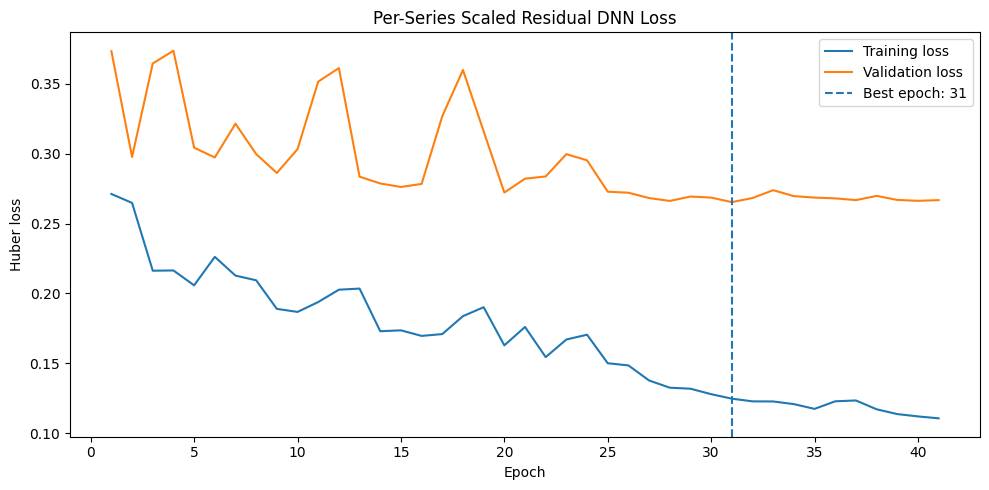

In [139]:
# inspect whether the revised model is overfitting

plt.figure(figsize=(10, 5))

plt.plot(
    series_scaled_history_df["epoch"],
    series_scaled_history_df["loss"],
    label="Training loss"
)

plt.plot(
    series_scaled_history_df["epoch"],
    series_scaled_history_df["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_series_scaled_epoch,
    linestyle="--",
    label=(
        f"Best epoch: "
        f"{best_series_scaled_epoch}"
    )
)

plt.title(
    "Per-Series Scaled Residual DNN Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.legend()
plt.tight_layout()
plt.show()

In [140]:
# generate recursive forecasts with per-series residual scaling

def generate_recursive_series_scaled_dnn_forecast(
    fitted_model,
    fitted_preprocessor,
    series_statistics,
    history_data,
    future_data,
    model_features
):
    history_data = (
        history_data
        .sort_values(
            ["store_id", "cat_id", "date"]
        )
        .copy()
    )

    future_data = (
        future_data
        .sort_values(
            ["date", "store_id", "cat_id"]
        )
        .copy()
    )

    # convert the statistics table into a dictionary
    # this makes lookup faster during recursive forecasting
    statistics_lookup = {}

    for _, row in series_statistics.iterrows():
        series_key = (
            row["store_id"],
            row["cat_id"]
        )

        statistics_lookup[series_key] = {
            "mean": float(
                row["residual_mean"]
            ),
            "std": float(
                row["residual_std"]
            )
        }

    series_histories = {}

    for series_key, series_data in history_data.groupby(
        ["store_id", "cat_id"],
        observed=True
    ):
        series_histories[series_key] = (
            series_data
            .sort_values("date")["sales"]
            .astype(float)
            .tolist()
        )

    forecast_batches = []

    for forecast_date in sorted(
        future_data["date"].unique()
    ):
        current_date_data = (
            future_data[
                future_data["date"]
                == forecast_date
            ]
            .copy()
        )

        updated_rows = []
        weekly_baselines = []
        residual_means = []
        residual_stds = []

        for _, row in current_date_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            available_history = (
                series_histories[series_key]
            )

            dynamic_values = calculate_dynamic_features(
                sales_history=available_history,
                model_features=model_features
            )

            updated_row = row.copy()

            for column, value in dynamic_values.items():
                updated_row[column] = value

            weekly_baseline = dynamic_values.get(
                "lag_7",
                (
                    available_history[-7]
                    if len(available_history) >= 7
                    else available_history[-1]
                )
            )

            statistics = statistics_lookup[
                series_key
            ]

            weekly_baselines.append(
                float(weekly_baseline)
            )

            residual_means.append(
                statistics["mean"]
            )

            residual_stds.append(
                statistics["std"]
            )

            updated_rows.append(
                updated_row
            )

        current_model_data = pd.DataFrame(
            updated_rows
        )

        transformed_current_data = (
            fitted_preprocessor
            .transform(
                current_model_data[
                    model_features
                ]
            )
            .astype("float32")
        )

        # predict the normalized residual for each series
        scaled_residual_predictions = (
            fitted_model.predict(
                transformed_current_data,
                verbose=0
            )
            .reshape(-1)
        )

        residual_means = np.asarray(
            residual_means,
            dtype=float
        )

        residual_stds = np.asarray(
            residual_stds,
            dtype=float
        )

        weekly_baselines = np.asarray(
            weekly_baselines,
            dtype=float
        )

        # convert each prediction back using its own series statistics
        residual_predictions = (
            scaled_residual_predictions
            * residual_stds
            + residual_means
        )

        current_predictions = (
            weekly_baselines
            + residual_predictions
        )

        current_predictions = np.clip(
            current_predictions,
            0,
            None
        )

        current_model_data[
            "weekly_baseline"
        ] = weekly_baselines

        current_model_data[
            "predicted_residual"
        ] = residual_predictions

        current_model_data[
            "prediction"
        ] = current_predictions

        for _, prediction_row in (
            current_model_data.iterrows()
        ):
            series_key = (
                prediction_row["store_id"],
                prediction_row["cat_id"]
            )

            series_histories[series_key].append(
                float(
                    prediction_row["prediction"]
                )
            )

        forecast_batches.append(
            current_model_data
        )

    return pd.concat(
        forecast_batches,
        ignore_index=True
    )

In [141]:
# test the per-series scaled model on the validation period

series_scaled_validation_start = time.time()

series_scaled_validation_predictions = (
    generate_recursive_series_scaled_dnn_forecast(
        fitted_model=(
            series_scaled_dnn_model
        ),
        fitted_preprocessor=(
            residual_dnn_preprocessor
        ),
        series_statistics=(
            series_residual_statistics
        ),
        history_data=(
            residual_dnn_training_df
        ),
        future_data=(
            residual_dnn_validation_df
        ),
        model_features=feature_columns
    )
)

series_scaled_validation_seconds = (
    time.time()
    - series_scaled_validation_start
)

print(
    "Validation rows:",
    len(
        series_scaled_validation_predictions
    )
)

print(
    "Validation dates:",
    series_scaled_validation_predictions[
        "date"
    ].nunique()
)

print(
    f"Recursive validation time: "
    f"{series_scaled_validation_seconds:.2f} seconds"
)

Validation rows: 840
Validation dates: 28
Recursive validation time: 10.42 seconds


In [142]:
# calculate validation metrics in the original sales scale

series_scaled_validation_mae = calculate_mae(
    series_scaled_validation_predictions[
        "sales"
    ],
    series_scaled_validation_predictions[
        "prediction"
    ]
)

series_scaled_validation_rmse = calculate_rmse(
    series_scaled_validation_predictions[
        "sales"
    ],
    series_scaled_validation_predictions[
        "prediction"
    ]
)

series_scaled_validation_wape = calculate_wape(
    series_scaled_validation_predictions[
        "sales"
    ],
    series_scaled_validation_predictions[
        "prediction"
    ]
)

series_scaled_validation_results = pd.DataFrame({
    "model": [
        "Weekly Baseline",
        "Global Residual DNN",
        "Per-Series Residual DNN"
    ],
    "mae": [
        weekly_validation_mae,
        residual_validation_mae,
        series_scaled_validation_mae
    ],
    "rmse": [
        weekly_validation_rmse,
        residual_validation_rmse,
        series_scaled_validation_rmse
    ],
    "wape": [
        weekly_validation_wape,
        residual_validation_wape,
        series_scaled_validation_wape
    ]
})

display(
    series_scaled_validation_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%"
    })
)

,model,mae,rmse,wape
0,Weekly Baseline,163.59,294.17,11.68%
1,Global Residual DNN,136.32,216.22,9.74%
2,Per-Series Residual DNN,137.04,212.47,9.79%


### Per-series scaling analysis

The per-series scaled residual DNN achieved a validation WAPE of **9.79%**, compared with **9.74%** for the globally scaled residual DNN. Its MAE also increased slightly from **136.32** to **137.04**.

The per-series approach did reduce RMSE from **216.22** to **212.47**, indicating a modest reduction in some of the largest forecast errors. However, this improvement was not accompanied by better average accuracy or overall volume accuracy.

The training history also showed evidence of overfitting. Training loss continued to decline throughout the later epochs, while validation loss flattened near 0.27. As a result, the gap between training and validation performance became progressively larger.

These results suggest that separate residual scaling by store-category series did not provide a meaningful improvement. Although it balanced the contribution of different series during training, it may also have reduced the influence of high-volume series that contribute more heavily to the overall demand forecast.

Therefore, the globally scaled residual DNN was retained as the final DNN specification because it achieved the lowest validation MAE and WAPE.

## 15. LSTM Recurrent Neural Network

A Long Short-Term Memory network was evaluated to determine whether explicitly modelling the ordered sequence of recent demand could improve forecasting accuracy.

Unlike Random Forest, XGBoost, and the feedforward DNN, the LSTM receives the previous 28 daily demand observations as an ordered sequence. A 28-day window was selected because it represents four complete weekly cycles while remaining short enough to control model complexity and runtime.

The model uses residual learning rather than predicting total demand directly:

Each 28-day input sequence is normalized using its own mean and standard deviation. The residual target is divided by the same sequence standard deviation. This local normalization allows the same LSTM to learn patterns across store-category series with substantially different demand scales.

The forecast is generated recursively. After each date is forecast, its predicted demand is added to the sequence history and used when forecasting subsequent dates.

In [143]:
# import the TensorFlow layers required for the sequence model

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

In [144]:
# use the previous four weeks to predict the next day

SEQUENCE_LENGTH = 28

print(
    "LSTM sequence length:",
    SEQUENCE_LENGTH,
    "days"
)

LSTM sequence length: 28 days


Create a function for building LSTM sequences

For each store-category series, the function:

sorts observations chronologically;
takes the previous 28 sales values;
calculates the sequence mean and standard deviation;
normalizes the 28-day demand sequence;
calculates the residual relative to lag_7;
scales the residual using the sequence standard deviation.

The target date itself is never included in the input sequence.

In [145]:
# create normalized 28-day sequences for lstm training

def create_lstm_sequences(
    data,
    sequence_length=28
):
    sequence_list = []
    target_list = []
    metadata_list = []

    # build sequences separately for every store-category series
    grouped_data = data.groupby(
        ["store_id", "cat_id"],
        observed=True
    )

    for (store_id, cat_id), series_data in grouped_data:
        series_data = (
            series_data
            .sort_values("date")
            .reset_index(drop=True)
        )

        sales_values = (
            series_data["sales"]
            .astype(float)
            .to_numpy()
        )

        date_values = (
            series_data["date"]
            .to_numpy()
        )

        # the target begins after at least 28 historical observations
        for target_position in range(
            sequence_length,
            len(series_data)
        ):
            sequence_start = (
                target_position
                - sequence_length
            )

            historical_sales = sales_values[
                sequence_start:target_position
            ]

            target_sales = sales_values[
                target_position
            ]

            # skip sequences containing invalid values
            if (
                np.isnan(historical_sales).any()
                or np.isnan(target_sales)
            ):
                continue

            sequence_mean = (
                historical_sales.mean()
            )

            sequence_std = (
                historical_sales.std()
            )

            # protect against division by zero for stable sequences
            if sequence_std < 1.0:
                sequence_std = 1.0

            normalized_sequence = (
                historical_sales
                - sequence_mean
            ) / sequence_std

            # the observation seven days before the target
            # is located at position -7 in the history
            weekly_baseline = (
                historical_sales[-7]
            )

            residual_target = (
                target_sales
                - weekly_baseline
            )

            scaled_residual_target = (
                residual_target
                / sequence_std
            )

            # lstm input shape:
            # number of sequences × time steps × features
            sequence_list.append(
                normalized_sequence.reshape(
                    sequence_length,
                    1
                )
            )

            target_list.append(
                scaled_residual_target
            )

            metadata_list.append({
                "date": date_values[
                    target_position
                ],
                "store_id": store_id,
                "cat_id": cat_id,
                "actual_sales": target_sales,
                "weekly_baseline": weekly_baseline,
                "sequence_mean": sequence_mean,
                "sequence_std": sequence_std
            })

    X = np.asarray(
        sequence_list,
        dtype="float32"
    )

    y = np.asarray(
        target_list,
        dtype="float32"
    )

    metadata = pd.DataFrame(
        metadata_list
    )

    return X, y, metadata

In [146]:
# build all available lstm sequences from the training period

X_lstm_all, y_lstm_all, lstm_metadata = (
    create_lstm_sequences(
        data=train_df,
        sequence_length=SEQUENCE_LENGTH
    )
)

print(
    "All sequence shape:",
    X_lstm_all.shape
)

print(
    "All target shape:",
    y_lstm_all.shape
)

print(
    "Sequence date range:",
    pd.to_datetime(
        lstm_metadata["date"]
    ).min().date(),
    "to",
    pd.to_datetime(
        lstm_metadata["date"]
    ).max().date()
)

All sequence shape: (54030, 28, 1)
All target shape: (54030,)
Sequence date range: 2011-04-23 to 2016-03-27


In [147]:
# divide sequences using the same chronological validation period

lstm_metadata["date"] = pd.to_datetime(
    lstm_metadata["date"]
)

lstm_validation_start = pd.to_datetime(
    dnn_validation_df["date"].min()
)

lstm_validation_end = pd.to_datetime(
    dnn_validation_df["date"].max()
)

lstm_training_mask = (
    lstm_metadata["date"]
    < lstm_validation_start
)

lstm_validation_mask = (
    (
        lstm_metadata["date"]
        >= lstm_validation_start
    )
    & (
        lstm_metadata["date"]
        <= lstm_validation_end
    )
)

X_lstm_train = X_lstm_all[
    lstm_training_mask.to_numpy()
]

y_lstm_train = y_lstm_all[
    lstm_training_mask.to_numpy()
]

X_lstm_valid = X_lstm_all[
    lstm_validation_mask.to_numpy()
]

y_lstm_valid = y_lstm_all[
    lstm_validation_mask.to_numpy()
]

lstm_validation_metadata = (
    lstm_metadata[
        lstm_validation_mask
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "LSTM training shape:",
    X_lstm_train.shape
)

print(
    "LSTM validation shape:",
    X_lstm_valid.shape
)

print(
    "Validation period:",
    lstm_validation_start.date(),
    "to",
    lstm_validation_end.date()
)

LSTM training shape: (53190, 28, 1)
LSTM validation shape: (840, 28, 1)
Validation period: 2016-02-29 to 2016-03-27


In [148]:
# inspect the distribution of the lstm target

lstm_target_summary = pd.Series({
    "training_mean": (
        y_lstm_train.mean()
    ),
    "training_std": (
        y_lstm_train.std()
    ),
    "training_min": (
        y_lstm_train.min()
    ),
    "training_max": (
        y_lstm_train.max()
    ),
    "validation_mean": (
        y_lstm_valid.mean()
    ),
    "validation_std": (
        y_lstm_valid.std()
    )
})

display(
    lstm_target_summary
    .to_frame(name="value")
    .style.format("{:.4f}")
)

,value
training_mean,0.0150
training_std,1.0734
training_min,-10.6431
training_max,9.9946
validation_mean,-0.0046
validation_std,0.9977


The model uses:

one LSTM layer with 32 units;
dropout to reduce overfitting;
one small dense layer;
Huber loss to reduce sensitivity to extreme demand changes.

A single LSTM layer is sufficient for the first experiment and should keep runtime well below the Random Forest runtime.

In [149]:
# define a compact lstm model for residual forecasting

def build_lstm_model(
    sequence_length,
    number_of_features
):
    model = Sequential([
        Input(
            shape=(
                sequence_length,
                number_of_features
            )
        ),

        # learn temporal patterns across the 28-day sequence
        LSTM(
            units=32,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=False
        ),

        # reduce overfitting to individual training sequences
        Dropout(0.15),

        # learn a compact nonlinear transformation
        Dense(
            units=16,
            activation="relu"
        ),

        Dropout(0.05),

        # predict the scaled correction to the weekly baseline
        Dense(
            units=1,
            activation="linear"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),

        # Huber loss is less sensitive to large residual outliers
        loss=Huber(
            delta=1.0
        ),

        metrics=["mae"]
    )

    return model


tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

lstm_model = build_lstm_model(
    sequence_length=SEQUENCE_LENGTH,
    number_of_features=1
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [150]:
# define a compact lstm model for residual forecasting

def build_lstm_model(
    sequence_length,
    number_of_features
):
    model = Sequential([
        Input(
            shape=(
                sequence_length,
                number_of_features
            )
        ),

        # learn temporal patterns across the 28-day sequence
        LSTM(
            units=32,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=False
        ),

        # reduce overfitting to individual training sequences
        Dropout(0.15),

        # learn a compact nonlinear transformation
        Dense(
            units=16,
            activation="relu"
        ),

        Dropout(0.05),

        # predict the scaled correction to the weekly baseline
        Dense(
            units=1,
            activation="linear"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),

        # Huber loss is less sensitive to large residual outliers
        loss=Huber(
            delta=1.0
        ),

        metrics=["mae"]
    )

    return model


tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

lstm_model = build_lstm_model(
    sequence_length=SEQUENCE_LENGTH,
    number_of_features=1
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
# control runtime and reduce overfitting

lstm_early_stopping = EarlyStopping(
    monitor="val_loss",

    # allow enough epochs for recurrent training to stabilize
    patience=10,

    # return to the model from the strongest validation epoch
    restore_best_weights=True,

    min_delta=0.0001,
    verbose=1
)

lstm_learning_rate_scheduler = ReduceLROnPlateau(
    monitor="val_loss",

    # use smaller updates when validation progress slows
    factor=0.5,

    patience=5,
    min_lr=0.00001,
    verbose=1
)

In [152]:
# train the compact lstm model

lstm_training_start_time = time.time()

lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,

    validation_data=(
        X_lstm_valid,
        y_lstm_valid
    ),

    # early stopping will normally finish before this limit
    epochs=80,

    batch_size=256,

    # sequence examples may be shuffled because each complete
    # 28-day sequence preserves its own internal time order
    shuffle=True,

    callbacks=[
        lstm_early_stopping,
        lstm_learning_rate_scheduler
    ],

    verbose=1
)

lstm_training_minutes = (
    time.time()
    - lstm_training_start_time
) / 60

print(
    f"LSTM training time: "
    f"{lstm_training_minutes:.2f} minutes"
)

Epoch 1/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.3966 - mae: 0.7468 - val_loss: 0.3626 - val_mae: 0.7027 - learning_rate: 0.0010
Epoch 2/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3763 - mae: 0.7218 - val_loss: 0.3494 - val_mae: 0.6869 - learning_rate: 0.0010
Epoch 3/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3712 - mae: 0.7149 - val_loss: 0.3473 - val_mae: 0.6841 - learning_rate: 0.0010
Epoch 4/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3696 - mae: 0.7131 - val_loss: 0.3456 - val_mae: 0.6820 - learning_rate: 0.0010
Epoch 5/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3683 - mae: 0.7113 - val_loss: 0.3433 - val_mae: 0.6795 - learning_rate: 0.0010
Epoch 6/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3667 - mae: 0.7092 - val_loss: 0.3423 - val_mae: 0.6769 - learning_rate: 0.0010
Epoch 7/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.3649 - mae: 0.7069 - val_loss: 0.3409 - val_mae: 0.6758 - learning_rate: 0.0010
Epoc

In [153]:
# identify the strongest lstm validation epoch

lstm_history_df = pd.DataFrame(
    lstm_history.history
)

lstm_history_df["epoch"] = (
    np.arange(
        len(lstm_history_df)
    )
    + 1
)

best_lstm_epoch = int(
    lstm_history_df.loc[
        lstm_history_df[
            "val_loss"
        ].idxmin(),
        "epoch"
    ]
)

best_lstm_validation_loss = (
    lstm_history_df[
        "val_loss"
    ].min()
)

best_lstm_validation_mae = (
    lstm_history_df.loc[
        lstm_history_df[
            "val_loss"
        ].idxmin(),
        "val_mae"
    ]
)

print(
    "Epochs completed:",
    len(lstm_history_df)
)

print(
    "Best epoch:",
    best_lstm_epoch
)

print(
    "Best scaled validation loss:",
    round(
        best_lstm_validation_loss,
        4
    )
)

print(
    "Best scaled validation MAE:",
    round(
        best_lstm_validation_mae,
        4
    )
)

Epochs completed: 62
Best epoch: 52
Best scaled validation loss: 0.2532
Best scaled validation MAE: 0.5579


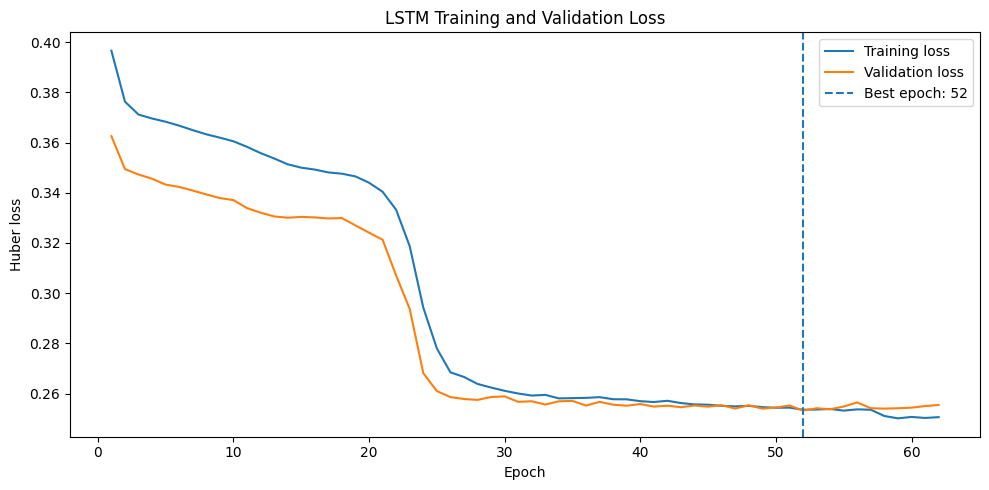

In [154]:
# compare lstm training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history_df["epoch"],
    lstm_history_df["loss"],
    label="Training loss"
)

plt.plot(
    lstm_history_df["epoch"],
    lstm_history_df["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_lstm_epoch,
    linestyle="--",
    label=(
        f"Best epoch: "
        f"{best_lstm_epoch}"
    )
)

plt.title(
    "LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.legend()
plt.tight_layout()
plt.show()

In [155]:
# generate recursive forecasts using 28-day sales sequences

def generate_recursive_lstm_forecast(
    fitted_model,
    history_data,
    future_data,
    sequence_length=28
):
    history_data = (
        history_data
        .sort_values(
            ["store_id", "cat_id", "date"]
        )
        .copy()
    )

    future_data = (
        future_data
        .sort_values(
            ["date", "store_id", "cat_id"]
        )
        .copy()
    )

    # store each series history in a list that can be updated
    series_histories = {}

    for series_key, series_data in history_data.groupby(
        ["store_id", "cat_id"],
        observed=True
    ):
        series_histories[series_key] = (
            series_data
            .sort_values("date")["sales"]
            .astype(float)
            .tolist()
        )

    forecast_batches = []

    # predict one date at a time
    for forecast_date in sorted(
        future_data["date"].unique()
    ):
        current_date_data = (
            future_data[
                future_data["date"]
                == forecast_date
            ]
            .copy()
            .reset_index(drop=True)
        )

        current_sequences = []
        weekly_baselines = []
        sequence_means = []
        sequence_stds = []
        series_keys = []

        for _, row in current_date_data.iterrows():
            series_key = (
                row["store_id"],
                row["cat_id"]
            )

            available_history = (
                series_histories[series_key]
            )

            if (
                len(available_history)
                < sequence_length
            ):
                raise ValueError(
                    f"Series {series_key} has fewer "
                    f"than {sequence_length} observations."
                )

            historical_sequence = np.asarray(
                available_history[
                    -sequence_length:
                ],
                dtype=float
            )

            sequence_mean = (
                historical_sequence.mean()
            )

            sequence_std = (
                historical_sequence.std()
            )

            if sequence_std < 1.0:
                sequence_std = 1.0

            normalized_sequence = (
                historical_sequence
                - sequence_mean
            ) / sequence_std

            # lag_7 is measured relative to the forecast date
            weekly_baseline = (
                available_history[-7]
            )

            current_sequences.append(
                normalized_sequence.reshape(
                    sequence_length,
                    1
                )
            )

            weekly_baselines.append(
                float(weekly_baseline)
            )

            sequence_means.append(
                float(sequence_mean)
            )

            sequence_stds.append(
                float(sequence_std)
            )

            series_keys.append(
                series_key
            )

        current_sequences = np.asarray(
            current_sequences,
            dtype="float32"
        )

        # predict the residual divided by sequence standard deviation
        scaled_residual_predictions = (
            fitted_model.predict(
                current_sequences,
                verbose=0
            )
            .reshape(-1)
        )

        weekly_baselines = np.asarray(
            weekly_baselines,
            dtype=float
        )

        sequence_stds = np.asarray(
            sequence_stds,
            dtype=float
        )

        # convert the scaled correction to the original sales scale
        residual_predictions = (
            scaled_residual_predictions
            * sequence_stds
        )

        current_predictions = (
            weekly_baselines
            + residual_predictions
        )

        # retail demand cannot be negative
        current_predictions = np.clip(
            current_predictions,
            0,
            None
        )

        current_date_data[
            "weekly_baseline"
        ] = weekly_baselines

        current_date_data[
            "scaled_residual_prediction"
        ] = scaled_residual_predictions

        current_date_data[
            "predicted_residual"
        ] = residual_predictions

        current_date_data[
            "prediction"
        ] = current_predictions

        # add predictions to history for later forecast dates
        for row_position, series_key in enumerate(
            series_keys
        ):
            series_histories[
                series_key
            ].append(
                float(
                    current_predictions[
                        row_position
                    ]
                )
            )

        forecast_batches.append(
            current_date_data
        )

    return pd.concat(
        forecast_batches,
        ignore_index=True
    )

In [156]:
# generate a leakage-free recursive validation forecast

lstm_history_before_validation = (
    train_df[
        train_df["date"]
        < lstm_validation_start
    ]
    .copy()
)

lstm_validation_future = (
    train_df[
        (
            train_df["date"]
            >= lstm_validation_start
        )
        & (
            train_df["date"]
            <= lstm_validation_end
        )
    ]
    .copy()
)

lstm_recursive_start_time = time.time()

lstm_validation_predictions = (
    generate_recursive_lstm_forecast(
        fitted_model=lstm_model,
        history_data=(
            lstm_history_before_validation
        ),
        future_data=(
            lstm_validation_future
        ),
        sequence_length=SEQUENCE_LENGTH
    )
)

lstm_recursive_seconds = (
    time.time()
    - lstm_recursive_start_time
)

print(
    "Validation forecast rows:",
    len(lstm_validation_predictions)
)

print(
    "Validation forecast dates:",
    lstm_validation_predictions[
        "date"
    ].nunique()
)

print(
    f"Recursive validation time: "
    f"{lstm_recursive_seconds:.2f} seconds"
)

Validation forecast rows: 840
Validation forecast dates: 28
Recursive validation time: 2.27 seconds


In [157]:
# verify that the lstm produced valid demand forecasts

lstm_validation_quality = pd.Series({
    "missing_predictions": (
        lstm_validation_predictions[
            "prediction"
        ].isna().sum()
    ),
    "infinite_predictions": (
        np.isinf(
            lstm_validation_predictions[
                "prediction"
            ]
        ).sum()
    ),
    "negative_predictions": (
        lstm_validation_predictions[
            "prediction"
        ].lt(0).sum()
    ),
    "minimum_prediction": (
        lstm_validation_predictions[
            "prediction"
        ].min()
    ),
    "maximum_prediction": (
        lstm_validation_predictions[
            "prediction"
        ].max()
    ),
    "average_prediction": (
        lstm_validation_predictions[
            "prediction"
        ].mean()
    ),
    "average_actual": (
        lstm_validation_predictions[
            "sales"
        ].mean()
    )
})

display(
    lstm_validation_quality.to_frame(
        name="value"
    )
)

,value
missing_predictions,0.000000
infinite_predictions,0.000000
negative_predictions,0.000000
minimum_prediction,214.410439
maximum_prediction,5163.067593
average_prediction,1402.284173
average_actual,1400.079762


In [158]:
# calculate lstm validation metrics in the original sales scale

lstm_validation_mae = calculate_mae(
    lstm_validation_predictions[
        "sales"
    ],
    lstm_validation_predictions[
        "prediction"
    ]
)

lstm_validation_rmse = calculate_rmse(
    lstm_validation_predictions[
        "sales"
    ],
    lstm_validation_predictions[
        "prediction"
    ]
)

lstm_validation_wape = calculate_wape(
    lstm_validation_predictions[
        "sales"
    ],
    lstm_validation_predictions[
        "prediction"
    ]
)

lstm_validation_results = pd.DataFrame({
    "model": [
        "Weekly Baseline",
        "Global Residual DNN",
        "LSTM"
    ],
    "mae": [
        weekly_validation_mae,
        residual_validation_mae,
        lstm_validation_mae
    ],
    "rmse": [
        weekly_validation_rmse,
        residual_validation_rmse,
        lstm_validation_rmse
    ],
    "wape": [
        weekly_validation_wape,
        residual_validation_wape,
        lstm_validation_wape
    ]
})

display(
    lstm_validation_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%"
    })
)

,model,mae,rmse,wape
0,Weekly Baseline,163.59,294.17,11.68%
1,Global Residual DNN,136.32,216.22,9.74%
2,LSTM,131.95,237.12,9.42%


In [159]:
# define a slightly deeper stacked lstm model

def build_stacked_lstm_model(
    sequence_length,
    number_of_features
):
    model = Sequential([
        Input(
            shape=(
                sequence_length,
                number_of_features
            )
        ),

        # first lstm returns the full sequence
        # so the second lstm can process higher-level temporal patterns
        LSTM(
            units=48,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=True
        ),

        Dropout(0.15),

        # second lstm summarizes the sequence into one representation
        LSTM(
            units=24,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=False
        ),

        Dropout(0.10),

        # small dense layer for the final nonlinear transformation
        Dense(
            units=12,
            activation="relu"
        ),

        # predict the scaled residual
        Dense(
            units=1,
            activation="linear"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss=Huber(
            delta=1.0
        ),
        metrics=["mae"]
    )

    return model

In [160]:
# train the stacked lstm using the same validation framework

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

stacked_lstm_model = build_stacked_lstm_model(
    sequence_length=SEQUENCE_LENGTH,
    number_of_features=1
)

stacked_lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    min_delta=0.0001,
    verbose=1
)

stacked_lstm_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

stacked_lstm_start_time = time.time()

stacked_lstm_history = stacked_lstm_model.fit(
    X_lstm_train,
    y_lstm_train,

    validation_data=(
        X_lstm_valid,
        y_lstm_valid
    ),

    epochs=80,
    batch_size=256,
    shuffle=True,

    callbacks=[
        stacked_lstm_early_stopping,
        stacked_lstm_lr_scheduler
    ],

    verbose=1
)

stacked_lstm_training_minutes = (
    time.time()
    - stacked_lstm_start_time
) / 60

print(
    f"Stacked LSTM training time: "
    f"{stacked_lstm_training_minutes:.2f} minutes"
)

Epoch 1/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3873 - mae: 0.7352 - val_loss: 0.3474 - val_mae: 0.6837 - learning_rate: 0.0010
Epoch 2/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3699 - mae: 0.7138 - val_loss: 0.3440 - val_mae: 0.6800 - learning_rate: 0.0010
Epoch 3/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3648 - mae: 0.7069 - val_loss: 0.3375 - val_mae: 0.6727 - learning_rate: 0.0010
Epoch 4/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.3603 - mae: 0.7007 - val_loss: 0.3351 - val_mae: 0.6715 - learning_rate: 0.0010
Epoch 5/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3561 - mae: 0.6957 - val_loss: 0.3337 - val_mae: 0.6705 - learning_rate: 0.0010
Epoch 6/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3532 - mae: 0.6919 - val_loss: 0.3333 - val_mae: 0.6696 - learning_rate: 0.0010
Epoch 7/80
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.3525 - mae: 0.6909 - val_loss: 0.3328 - val_mae: 0.6685 - learning_rate: 0.0010

In [161]:
# summarize the stacked lstm training results

stacked_lstm_history_df = pd.DataFrame(
    stacked_lstm_history.history
)

stacked_lstm_history_df["epoch"] = (
    np.arange(
        len(stacked_lstm_history_df)
    )
    + 1
)

best_stacked_lstm_epoch = int(
    stacked_lstm_history_df.loc[
        stacked_lstm_history_df[
            "val_loss"
        ].idxmin(),
        "epoch"
    ]
)

best_stacked_lstm_validation_loss = (
    stacked_lstm_history_df[
        "val_loss"
    ].min()
)

best_stacked_lstm_validation_mae = (
    stacked_lstm_history_df.loc[
        stacked_lstm_history_df[
            "val_loss"
        ].idxmin(),
        "val_mae"
    ]
)

print(
    "Epochs completed:",
    len(stacked_lstm_history_df)
)

print(
    "Best epoch:",
    best_stacked_lstm_epoch
)

print(
    "Best scaled validation loss:",
    round(
        best_stacked_lstm_validation_loss,
        4
    )
)

print(
    "Best scaled validation MAE:",
    round(
        best_stacked_lstm_validation_mae,
        4
    )
)

Epochs completed: 67
Best epoch: 57
Best scaled validation loss: 0.247
Best scaled validation MAE: 0.5463


In [162]:
# evaluate the stacked lstm using recursive validation

stacked_lstm_validation_predictions = (
    generate_recursive_lstm_forecast(
        fitted_model=stacked_lstm_model,
        history_data=(
            lstm_history_before_validation
        ),
        future_data=(
            lstm_validation_future
        ),
        sequence_length=SEQUENCE_LENGTH
    )
)

stacked_lstm_validation_mae = calculate_mae(
    stacked_lstm_validation_predictions[
        "sales"
    ],
    stacked_lstm_validation_predictions[
        "prediction"
    ]
)

stacked_lstm_validation_rmse = calculate_rmse(
    stacked_lstm_validation_predictions[
        "sales"
    ],
    stacked_lstm_validation_predictions[
        "prediction"
    ]
)

stacked_lstm_validation_wape = calculate_wape(
    stacked_lstm_validation_predictions[
        "sales"
    ],
    stacked_lstm_validation_predictions[
        "prediction"
    ]
)

stacked_lstm_comparison = pd.DataFrame({
    "model": [
        "Weekly Baseline",
        "Global Residual DNN",
        "Single-Layer LSTM",
        "Stacked LSTM"
    ],
    "mae": [
        weekly_validation_mae,
        residual_validation_mae,
        lstm_validation_mae,
        stacked_lstm_validation_mae
    ],
    "rmse": [
        weekly_validation_rmse,
        residual_validation_rmse,
        lstm_validation_rmse,
        stacked_lstm_validation_rmse
    ],
    "wape": [
        weekly_validation_wape,
        residual_validation_wape,
        lstm_validation_wape,
        stacked_lstm_validation_wape
    ]
})

display(
    stacked_lstm_comparison.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%"
    })
)

,model,mae,rmse,wape
0,Weekly Baseline,163.59,294.17,11.68%
1,Global Residual DNN,136.32,216.22,9.74%
2,Single-Layer LSTM,131.95,237.12,9.42%
3,Stacked LSTM,130.31,238.02,9.31%


In [163]:
# build the final stacked lstm model

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

final_lstm_model = build_stacked_lstm_model(
    sequence_length=SEQUENCE_LENGTH,
    number_of_features=1
)

final_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 48)         │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,921 (66.10 KB)

 Trainable params: 16,921 (66.10 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
# build all sequences from the complete training data

X_lstm_full_train, y_lstm_full_train, _ = create_lstm_sequences(
    data=train_df,
    sequence_length=SEQUENCE_LENGTH
)

print("Training sequences:", X_lstm_full_train.shape)
print("Training targets:", y_lstm_full_train.shape)

Training sequences: (54030, 28, 1)
Training targets: (54030,)


In [165]:
# train the final stacked lstm

final_training_start = time.time()

final_lstm_history = final_lstm_model.fit(
    X_lstm_full_train,
    y_lstm_full_train,

    epochs=55,
    batch_size=256,
    shuffle=True,

    verbose=1
)

final_training_minutes = (
    time.time() - final_training_start
) / 60

print(
    f"Final training time: "
    f"{final_training_minutes:.2f} minutes"
)

Epoch 1/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.3853 - mae: 0.7327
Epoch 2/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3693 - mae: 0.7129
Epoch 3/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3663 - mae: 0.7088
Epoch 4/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.3622 - mae: 0.7035
Epoch 5/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.3577 - mae: 0.6980
Epoch 6/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3546 - mae: 0.6939
Epoch 7/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3532 - mae: 0.6920
Epoch 8/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3522 - mae: 0.6904
Epoch 9/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3513 - mae: 0.6893
Epoch 10/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.3503 - mae: 0.6878
Epoch 11/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3499 - mae: 0.6873
Epoch 12/55
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.3494 - mae: 0.6869
Epoch 13/55
21

In [166]:
# create recursive forecasts for the test period

test_history = (
    train_df
    .sort_values(["store_id", "cat_id", "date"])
    .copy()
)

test_future = (
    test_df
    .sort_values(["date", "store_id", "cat_id"])
    .copy()
)

lstm_test_predictions = generate_recursive_lstm_forecast(
    fitted_model=final_lstm_model,
    history_data=test_history,
    future_data=test_future,
    sequence_length=SEQUENCE_LENGTH
)

print(
    "Forecast rows:",
    len(lstm_test_predictions)
)

print(
    "Forecast dates:",
    lstm_test_predictions["date"].nunique()
)

Forecast rows: 840
Forecast dates: 28


In [177]:
# calculate the final stacked lstm test metrics

lstm_test_mae = calculate_mae(
    lstm_test_predictions["sales"],
    lstm_test_predictions["prediction"]
)

lstm_test_rmse = calculate_rmse(
    lstm_test_predictions["sales"],
    lstm_test_predictions["prediction"]
)

lstm_test_wape = calculate_wape(
    lstm_test_predictions["sales"],
    lstm_test_predictions["prediction"]
)

lstm_test_wrmsse, _ = calculate_wrmsse(
    evaluation_data=lstm_test_predictions,
    scale_table=rmsse_scale,
    weight_table=revenue_weights,
    actual_column="sales",
    prediction_column="prediction"
)

lstm_test_results = pd.DataFrame({
    "model": ["Stacked LSTM"],
    "mae": [lstm_test_mae],
    "rmse": [lstm_test_rmse],
    "wape": [lstm_test_wape],
    "wrmsse": [lstm_test_wrmsse]
})

display(
    lstm_test_results.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,Stacked LSTM,134.84,208.65,9.57%,0.6466


In [178]:
# create the final test comparison table
# using the confirmed results from each completed model

final_model_comparison = pd.DataFrame({
    "model": [
        "Seasonal Naive",
        "Random Forest",
        "XGBoost",
        "Global Residual DNN",
        "Stacked LSTM"
    ],
    "mae": [
        186.50,
        117.00,
        111.36,
        168.25,
        lstm_test_mae
    ],
    "rmse": [
        321.00,
        200.87,
        173.17,
        254.81,
        lstm_test_rmse
    ],
    "wape": [
        13.24,
        8.30,
        7.90,
        11.94,
        lstm_test_wape
    ],
    "wrmsse": [
        0.9203,
        0.6006,
        0.5434,
        0.8015,
        lstm_test_wrmsse
    ]
})

final_model_comparison = (
    final_model_comparison
    .sort_values("wrmsse")
    .reset_index(drop=True)
)

display(
    final_model_comparison.style.format({
        "mae": "{:.2f}",
        "rmse": "{:.2f}",
        "wape": "{:.2f}%",
        "wrmsse": "{:.4f}"
    })
)

,model,mae,rmse,wape,wrmsse
0,XGBoost,111.36,173.17,7.90%,0.5434
1,Random Forest,117.00,200.87,8.30%,0.6006
2,Stacked LSTM,134.84,208.65,9.57%,0.6466
3,Global Residual DNN,168.25,254.81,11.94%,0.8015
4,Seasonal Naive,186.50,321.00,13.24%,0.9203


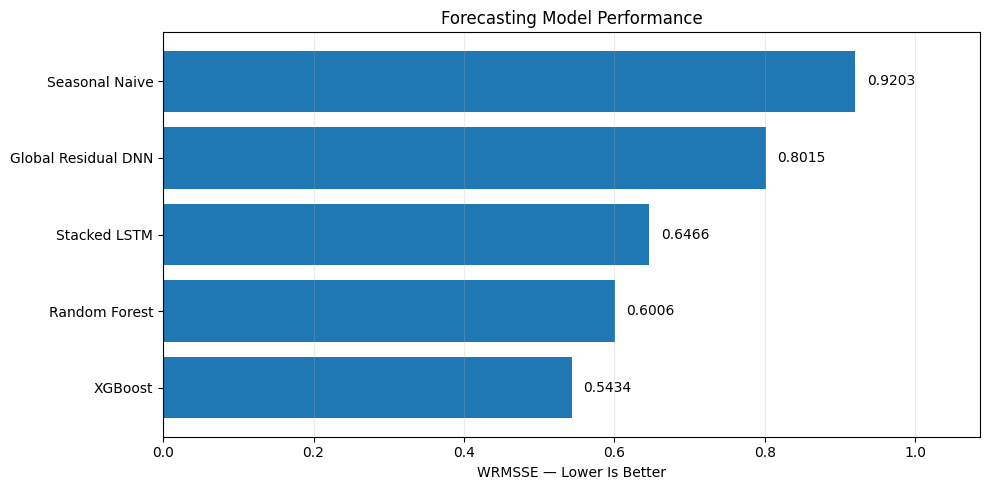

In [179]:
# Compare the models using WRMSSE, where lower values indicate better performance.

wrmsse_plot = (
    final_model_comparison[["model", "wrmsse"]]
    .sort_values("wrmsse", ascending=True)
    .copy()
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    wrmsse_plot["model"],
    wrmsse_plot["wrmsse"]
)

plt.xlabel("WRMSSE — Lower Is Better")
plt.ylabel("")
plt.title("Forecasting Model Performance")
plt.xlim(0, wrmsse_plot["wrmsse"].max() * 1.18)

for bar, value in zip(bars, wrmsse_plot["wrmsse"]):
    plt.text(
        value + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

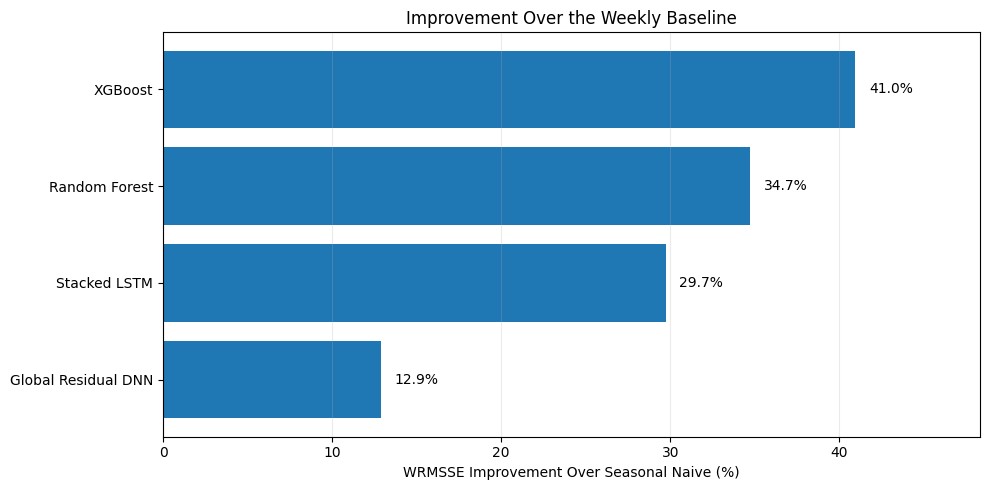

In [180]:
# Calculate the percentage improvement in WRMSSE relative to Seasonal Naive.

baseline_wrmsse = final_model_comparison.loc[
    final_model_comparison["model"] == "Seasonal Naive",
    "wrmsse"
].iloc[0]

improvement_plot = final_model_comparison.copy()

improvement_plot["wrmsse_improvement"] = (
    (baseline_wrmsse - improvement_plot["wrmsse"])
    / baseline_wrmsse
    * 100
)

improvement_plot = improvement_plot[
    improvement_plot["model"] != "Seasonal Naive"
].sort_values("wrmsse_improvement", ascending=True)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    improvement_plot["model"],
    improvement_plot["wrmsse_improvement"]
)

plt.xlabel("WRMSSE Improvement Over Seasonal Naive (%)")
plt.ylabel("")
plt.title("Improvement Over the Weekly Baseline")
plt.xlim(0, improvement_plot["wrmsse_improvement"].max() * 1.18)

for bar, value in zip(
    bars,
    improvement_plot["wrmsse_improvement"]
):
    plt.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

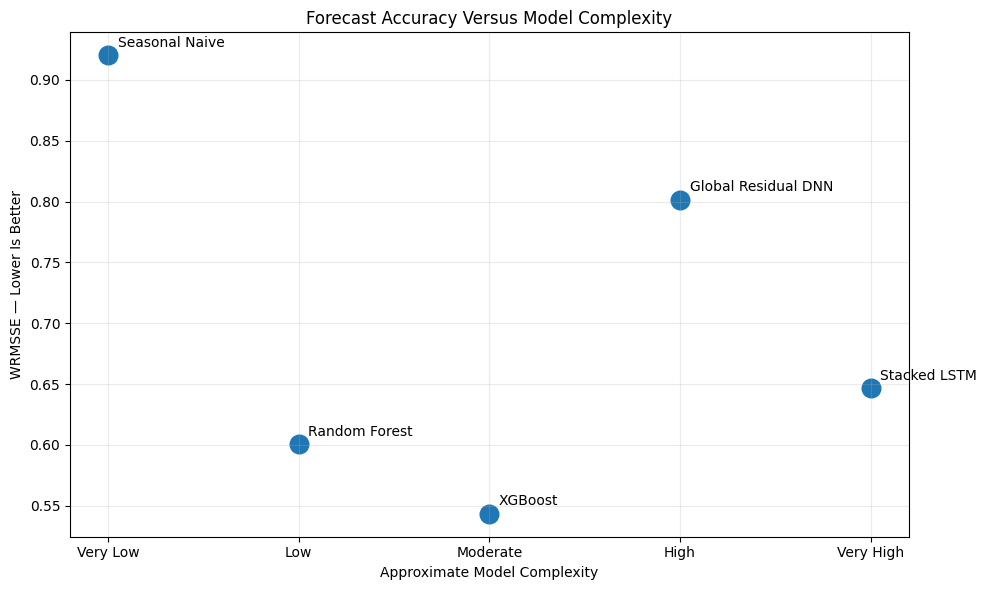

In [181]:
# Compare model accuracy with approximate implementation complexity.
# Complexity is shown as a qualitative score from 1 to 5.

complexity_scores = {
    "Seasonal Naive": 1,
    "Random Forest": 2,
    "XGBoost": 3,
    "Global Residual DNN": 4,
    "Stacked LSTM": 5
}

complexity_plot = final_model_comparison.copy()

complexity_plot["complexity"] = complexity_plot["model"].map(
    complexity_scores
)

plt.figure(figsize=(10, 6))

plt.scatter(
    complexity_plot["complexity"],
    complexity_plot["wrmsse"],
    s=180
)

for _, row in complexity_plot.iterrows():
    plt.annotate(
        row["model"],
        (row["complexity"], row["wrmsse"]),
        xytext=(7, 6),
        textcoords="offset points"
    )

plt.xticks(
    [1, 2, 3, 4, 5],
    ["Very Low", "Low", "Moderate", "High", "Very High"]
)

plt.xlabel("Approximate Model Complexity")
plt.ylabel("WRMSSE — Lower Is Better")
plt.title("Forecast Accuracy Versus Model Complexity")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

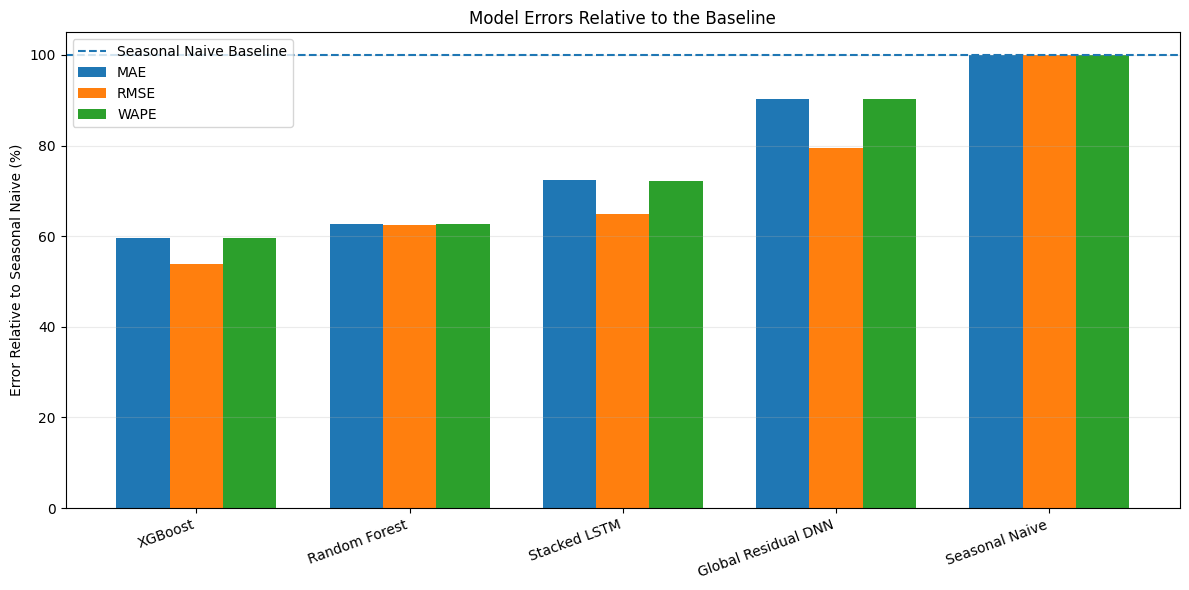

In [182]:
# Normalize MAE, RMSE, and WAPE relative to the Seasonal Naive baseline.
# Seasonal Naive is represented as 100 for every metric.

baseline_row = final_model_comparison[
    final_model_comparison["model"] == "Seasonal Naive"
].iloc[0]

normalized_comparison = final_model_comparison.copy()

normalized_comparison["MAE Index"] = (
    normalized_comparison["mae"] / baseline_row["mae"] * 100
)

normalized_comparison["RMSE Index"] = (
    normalized_comparison["rmse"] / baseline_row["rmse"] * 100
)

normalized_comparison["WAPE Index"] = (
    normalized_comparison["wape"] / baseline_row["wape"] * 100
)

normalized_comparison = normalized_comparison.sort_values(
    "wrmsse",
    ascending=True
)

x = range(len(normalized_comparison))
bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    [position - bar_width for position in x],
    normalized_comparison["MAE Index"],
    width=bar_width,
    label="MAE"
)

plt.bar(
    x,
    normalized_comparison["RMSE Index"],
    width=bar_width,
    label="RMSE"
)

plt.bar(
    [position + bar_width for position in x],
    normalized_comparison["WAPE Index"],
    width=bar_width,
    label="WAPE"
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1.5,
    label="Seasonal Naive Baseline"
)

plt.xticks(
    x,
    normalized_comparison["model"],
    rotation=20,
    ha="right"
)

plt.ylabel("Error Relative to Seasonal Naive (%)")
plt.title("Model Errors Relative to the Baseline")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 16. Discussion and Model Comparison
XGBoost achieved the best overall forecasting performance on the final 28-day test period, producing the lowest MAE, RMSE, WAPE, and WRMSSE. Random Forest was the second-best model, while the Stacked LSTM ranked third. Although the LSTM improved substantially over the residual DNN and Seasonal Naive baseline, it did not outperform the tree-based models. This suggests that, for the selected M5 aggregation level and engineered feature set, structured lag, rolling, calendar, event, and price features were more effectively captured by gradient-boosted trees than by the recurrent neural network.